# Notebook 4 of 4 — Real-run walkthrough: architecture race, in-training diagnostics, post-training results

Built entirely from artifacts of a real GPU training run (clean condition, seed 17, three instrumented
architectures: `gru`, `timepool`, `wide`) -- no mock or synthetic data anywhere. Contents: artifact
provenance and architecture comparison (with an honest negative finding); checkpoint verification and an
`offloaded` accuracy re-derivation; in-training diagnostics (AutoClip gradient clipping, SentryCam-style 2D
cluster health, and the raw-space-versus-2D alert comparison as the headline); MM-PHATE-style statistics
(PCA embedding, labelled as a deviation); post-training calibration, selective-risk and conformal results
under **exploration-config** settings (4 stress conditions, 200 bootstrap resamples: not publication numbers);
and limitations. Runs on the remote Colab runtime (Drive artifacts) and, for editing and review, on the
authoring host against the local `runtime/` mirror. Notebooks 1-3 and `src/` are not modified.

In [1]:
# Shared setup: root-independent imports, seed, palette, labelled self-check helper.
from pathlib import Path
import sys

_here = Path.cwd().resolve()
ROOT = next((p for p in [_here, *_here.parents] if (p / "pyproject.toml").exists()), _here)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

RNG_SEED = 20260926
PALETTE = {
    "clean": "#1f77b4", "shifted": "#d62728", "mask": "#ff7f0e", "acoustic": "#2ca02c",
    "frozen": "#9467bd", "adapted": "#8c564b", "reference": "#7f7f7f", "band": "#c7c7c7",
}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})

CHECKS = []
def check(label, passed, detail=""):
    """Print `[label] detail -> PASS|FAIL`; never loosen a tolerance to force PASS. Use note() for honest misses."""
    CHECKS.append((label, bool(passed), "PASS" if passed else "FAIL"))
    print(f"[{label}] {detail} -> {'PASS' if passed else 'FAIL'}")
    return bool(passed)

def note(label, detail):
    CHECKS.append((label, True, "NOTE"))
    print(f"[{label}] {detail} -> NOTE")

def check_summary():
    fails = [c[0] for c in CHECKS if c[2] == "FAIL"]
    print(f"{len(CHECKS)} labelled lines; {sum(c[2]=='PASS' for c in CHECKS)} PASS, "
          f"{sum(c[2]=='NOTE' for c in CHECKS)} NOTE, {len(fails)} FAIL {fails}")

## 1. Charter, provenance, and what this notebook is not

This notebook is built **only** from artifacts that a real GPU training run produced (on the Colab runtime,
stored on Google Drive) and that are mirrored locally in `<ARTIFACT_ROOT>/metrics/`: three `arch-*.result.json` files (real `ArmRun` output), three
`arch-*.probes.npz` files (per-epoch in-training probes), three per-arm worker logs, one precomputed
`mmphate_stats.npz`, and the superseded legacy training logs. Every printed number and every plotted point
traces to one of those files. Where something cannot be computed from them, the text says so and the analysis
is skipped -- nothing is substituted.

**Where this notebook runs.** Its execution host is the remote Colab runtime, which has the GPU, Google Drive
mounted at `/content/drive/MyDrive`, and therefore the checkpoints and the Speech Commands bundle next to the
compute. The local machine is only the *authoring* host: it holds the editable source of truth
(`notebooks/build/nb4_part*.py`) and a mirror of the `metrics/` folder for editing and review. Cells that need
the remote-only resources (checkpoints, the dataset, a GPU) are tagged `offloaded`, so a local run skips
them instead of failing; everything else runs anywhere. A single cell below resolves one `ARTIFACT_ROOT`
(the Drive folder when it exists, otherwise the local `runtime/` mirror) and **prints which root and which host
it used**, so a reader of an executed copy can see where the numbers came from. The local `runtime/` folder is
**git-ignored**; a fresh clone contains no artifacts, and the resolution cell fails loudly rather than
substituting anything.

**Run configuration.** The run behind every result is `condition=clean`, `seed=17`, at most 36 epochs with
early-stopping patience 8 (the `gru` arm early-stopped at epoch 28). The post-training summary block was
produced with the **EXPLORATION configuration: 4 stress conditions and 200 bootstrap resamples**. These are
exploration results and must never be quoted as publication numbers; the full 11-condition / 2000-resample
publication evaluation was never run (see Section 8).

**The four architectures.**

| name | class in `src/models.py` | parameters | instrumented in this run |
|---|---|---|---|
| `baseline` | `LogMelCNN` | 14,524 | no -- legacy control, its `AdaptiveAvgPool2d((1,1))` leaves no temporal axis |
| `timepool` | `TimePoolCNN` | 17,212 | yes |
| `wide` | `WideCNN` | 271,692 | yes |
| `gru` | `ConvGRU` | 291,564 | yes |

**Sections.** Section 2 inventories the artifacts (sha256 and array shapes: the provenance root). Section 3
compares the architectures and states an honest negative finding. Section 4 reloads the checkpoints and re-derives the recorded accuracy on the real
validation split (offloaded). Section 5 covers the in-training diagnostics V1--V4 (training curves, AutoClip, SentryCam) and the
headline raw-space-versus-2D alert comparison. Section 6 covers the MM-PHATE statistics V5--V8. Section 7 is
the post-training results section. Section 8 is the limitations section.

In [2]:
# NB4 helpers: single ARTIFACT_ROOT resolution, artifact loading, figure saving. No silent fallback, no synthetic data.
import json, hashlib, re, os, platform
import pandas as pd
# Plain-text DataFrame repr: Colab otherwise wraps every table in ~6KB of interactive HTML,
# which bloats the .ipynb and the synced outputs without adding information.
pd.set_option("display.notebook_repr_html", False)
try:  # Colab also registers its own interactive-table HTML formatter for DataFrame;
    # drop it so tables render as plain text instead of ~3KB of embedded CSS/JS each.
    get_ipython().display_formatter.formatters["text/html"].type_printers.pop(pd.DataFrame, None)
except Exception:
    pass
# Plain-text DataFrame repr: Colab otherwise wraps every table in ~6KB of interactive HTML,
# which bloats the .ipynb and the synced outputs without adding information.
pd.set_option("display.notebook_repr_html", False)
from IPython.display import display
from scipy.stats import gaussian_kde, spearmanr

DRIVE_ROOT = Path("/content/drive/MyDrive/deep-learning-first-project")
LOCAL_ROOT = ROOT / "runtime"
if DRIVE_ROOT.is_dir():
    ARTIFACT_ROOT, HOST = DRIVE_ROOT, "remote Colab runtime (Drive mounted)"
elif LOCAL_ROOT.is_dir():
    ARTIFACT_ROOT, HOST = LOCAL_ROOT, "local authoring host (runtime/ mirror; Drive not mounted)"
else:
    raise FileNotFoundError(f"neither {DRIVE_ROOT} nor {LOCAL_ROOT} exists; runtime/ is git-ignored and this notebook has no synthetic fallback")
MET = ARTIFACT_ROOT / "metrics"
CKPT_DIR = ARTIFACT_ROOT / "checkpoints"
# Figures persist next to the artifacts they are derived from, so a remote run does not
# lose them when the runtime recycles (ARTIFACT_ROOT is Drive on the execution host).
FIGDIR = ARTIFACT_ROOT / "figures" / "nb4"
FIGDIR.mkdir(parents=True, exist_ok=True)
ARCHS = ["gru", "timepool", "wide"]
ACOL = {"gru": "#3568A8", "timepool": "#E58B2A", "wide": "#3A8D68"}

if not all((MET / f"arch-{a}.result.json").exists() for a in ARCHS):
    raise FileNotFoundError(f"arch-*.result.json not found under {MET} (resolved on: {HOST}); there is deliberately no synthetic fallback.")
try:
    import torch as _torch
    CUDA = _torch.cuda.is_available()
except Exception:
    CUDA = False

DATA = {}
for a in ARCHS:
    _npz = np.load(MET / f"arch-{a}.probes.npz")
    DATA[a] = {"res": json.loads((MET / f"arch-{a}.result.json").read_text()),
               "npz": {k: _npz[k] for k in _npz.files}}

def savefig(fig, name):
    # Save under runtime/figures/nb4/ and show inline.
    fig.savefig(FIGDIR / name, dpi=110, bbox_inches="tight")
    plt.show()
    return FIGDIR / name

print("host          :", HOST, "| node:", platform.node(), "| cuda available:", CUDA)
print("ARTIFACT_ROOT :", ARTIFACT_ROOT)
print("metrics dir   :", MET)
print("checkpoint dir:", CKPT_DIR, "(exists)" if CKPT_DIR.is_dir() else "(does not exist on this host)")
print("figure dir   :", FIGDIR)
for a in ARCHS:
    print(f"loaded {a}: epochs_run={DATA[a]['res']['epochs_run']} probe arrays={len(DATA[a]['npz'])}")
check("N4.1.1", True, f"all three result.json + probes.npz loaded from {MET}")

host          : local authoring host (runtime/ mirror; Drive not mounted) | node: DESKTOP-18QVOEC | cuda available: True
ARTIFACT_ROOT : /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime
metrics dir   : /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/metrics
checkpoint dir: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/checkpoints (does not exist on this host)
figure dir   : /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/figures/nb4
loaded gru: epochs_run=28 probe arrays=9
loaded timepool: epochs_run=36 probe arrays=9
loaded wide: epochs_run=36 probe arrays=9
[N4.1.1] all three result.json + probes.npz loaded from /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/metr

True

## 2. Artifact inventory and data understanding

Warden, *Speech Commands: A Dataset for Limited-Vocabulary Speech Recognition*, arXiv:1804.03209 (2018) — the corpus
every number in this notebook derives from, and the source of the 12-label task definition (10 command words plus
`unknown` and `silence`). It is the dataset citation, not one of the study's theory-bearing selections.

### 2.1 Provenance root: every file under `<ARTIFACT_ROOT>/metrics`, its size and sha256

The table below lists every file under the resolved `metrics/` folder with its byte size and full sha256. It is the
provenance root of this notebook: anything plotted later is a function of these bytes. If a reader re-copies the
artifacts and any hash differs, the figures no longer correspond to what is documented here.

In [3]:
# N4.2.1: inventory of every file under MET with size and sha256.
rows = []
for p in sorted(MET.rglob("*")):
    if p.is_file():
        h = hashlib.sha256(p.read_bytes()).hexdigest()
        rows.append({"file": str(p.relative_to(MET)), "bytes": p.stat().st_size, "sha256": h})
INVENTORY = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 80, "display.width", 200)
display(INVENTORY)
print(f"{len(INVENTORY)} files, {INVENTORY['bytes'].sum()/1e6:.2f} MB total")
check("N4.2.1", len(INVENTORY) >= 9, f"{len(INVENTORY)} files inventoried")
for _, r in INVENTORY.iterrows():
    check(f"N4.2.1[{r['file']}]", r["bytes"] > 0 and len(r["sha256"]) == 64, f"{r['bytes']} bytes, sha256 {r['sha256'][:12]}...")

                                    file    bytes                                                            sha256
0                           arch-gru.log     1030  a375ee281fab807226470acc0d5f10fdc7894e662320073a2ea97a0ce3911a37
1                    arch-gru.probes.npz  7792700  4d9568ea78307e114237fc50b0b25329c797846ec8f5843437d542432c5d77ea
2                   arch-gru.result.json    12102  96efe2941e8af72fec68ca1705f86dbdc4d5b2608e948e3c036193224480b4f4
3                      arch-timepool.log      644  01319c237a36b1a7aa8812e91787990fa01711a05790381f0a9ab4e6c9dd8773
4               arch-timepool.probes.npz  4091133  c2e82f56f57912edb7d5ae8160a31e3a88286ddfa0adf517211e7cc4501f6576
5              arch-timepool.result.json    12957  7a42ebd4c75dd12cc0f35100b435bbc32d251bbc83bbe955f7136d6a044e3bd1
6                          arch-wide.log      637  5d841e2bcc1d210f7b7c1b3ec82e52eaf7600e0e89fa8fd7153cc293bef66c0a
7                   arch-wide.probes.npz  3879985  735d26d9ab6ab920333c0

19 files, 15.86 MB total
[N4.2.1] 19 files inventoried -> PASS
[N4.2.1[arch-gru.log]] 1030 bytes, sha256 a375ee281fab... -> PASS
[N4.2.1[arch-gru.probes.npz]] 7792700 bytes, sha256 4d9568ea7830... -> PASS
[N4.2.1[arch-gru.result.json]] 12102 bytes, sha256 96efe2941e8a... -> PASS
[N4.2.1[arch-timepool.log]] 644 bytes, sha256 01319c237a36... -> PASS
[N4.2.1[arch-timepool.probes.npz]] 4091133 bytes, sha256 c2e82f56f579... -> PASS
[N4.2.1[arch-timepool.result.json]] 12957 bytes, sha256 7a42ebd4c75d... -> PASS
[N4.2.1[arch-wide.log]] 637 bytes, sha256 5d841e2bcc1d... -> PASS
[N4.2.1[arch-wide.probes.npz]] 3879985 bytes, sha256 735d26d9ab6a... -> PASS
[N4.2.1[arch-wide.result.json]] 12997 bytes, sha256 eef6c5ad982a... -> PASS
[N4.2.1[legacy_6arm_logs/acoustic_seed17.log]] 946 bytes, sha256 0b4f9ce8f822... -> PASS
[N4.2.1[legacy_6arm_logs/acoustic_seed18.log]] 848 bytes, sha256 6feab90fc7d1... -> PASS
[N4.2.1[legacy_6arm_logs/acoustic_seed19.log]] 946 bytes, sha256 f291cca09289... -> PASS
[N4

### 2.2 Array shapes inside each `.npz`

The probe arrays are the raw material for Sections 5 and 6. The expected shapes follow from the run
configuration: $E$ epochs actually run ($E=28$ for `gru`, $E=36$ for `timepool` and `wide`), $120$ probe samples
(12 classes $\times$ 10 per class), and the sequence tensor shape recorded as `mmphate_shape` in each result file.
The check cells compare every array's shape with the value implied by the result JSON, so a mismatch between two
artifacts of the same run is caught here rather than surfacing as a confusing figure later.

In [4]:
# N4.2.2: print array shapes for every npz and compare with the shape implied by the result JSON.
for a in ARCHS:
    res, npz = DATA[a]["res"], DATA[a]["npz"]
    E = res["epochs_run"]
    steps = len(npz["grad_norm"])
    expected = {
        "coords_2d": (E, 120, 2), "labels": (120,),
        "inter_2d": (E,), "intra_2d": (E,), "inter_raw": (E,), "intra_raw": (E,),
        "grad_norm": (steps,), "clip_threshold": (steps,),
        "mmphate_tensor": tuple(res["mmphate_shape"]),
    }
    print(f"--- arch-{a}.probes.npz  (E={E}, optimizer steps={steps})")
    for k in sorted(npz):
        print(f"   {k:16s} shape={str(npz[k].shape):18s} dtype={npz[k].dtype}")
        check(f"N4.2.2[{a}.{k}]", npz[k].shape == expected[k], f"shape {npz[k].shape} vs expected {expected[k]}")
if (MET / "mmphate_stats.npz").exists():
    st = np.load(MET / "mmphate_stats.npz")
    print("--- mmphate_stats.npz")
    for k in sorted(st.files):
        print(f"   {k:16s} shape={str(st[k].shape)}")
    check("N4.2.2[mmphate_stats keys]", len(st.files) == 9, f"{len(st.files)} arrays: intra/inter/flow x 3 archs")
else:
    note("N4.2.2[mmphate_stats]", f"mmphate_stats.npz not present under {MET}; Section 6 recomputes the statistics from the tensors instead")

--- arch-gru.probes.npz  (E=28, optimizer steps=1008)
   clip_threshold   shape=(1008,)            dtype=float64
[N4.2.2[gru.clip_threshold]] shape (1008,) vs expected (1008,) -> PASS
   coords_2d        shape=(28, 120, 2)       dtype=float32
[N4.2.2[gru.coords_2d]] shape (28, 120, 2) vs expected (28, 120, 2) -> PASS
   grad_norm        shape=(1008,)            dtype=float64
[N4.2.2[gru.grad_norm]] shape (1008,) vs expected (1008,) -> PASS
   inter_2d         shape=(28,)              dtype=float64
[N4.2.2[gru.inter_2d]] shape (28,) vs expected (28,) -> PASS
   inter_raw        shape=(28,)              dtype=float64
[N4.2.2[gru.inter_raw]] shape (28,) vs expected (28,) -> PASS
   intra_2d         shape=(28,)              dtype=float64
[N4.2.2[gru.intra_2d]] shape (28,) vs expected (28,) -> PASS
   intra_raw        shape=(28,)              dtype=float64
[N4.2.2[gru.intra_raw]] shape (28,) vs expected (28,) -> PASS
   labels           shape=(120,)             dtype=int64
[N4.2.2[gru.label

In [5]:
# N4.2.3: cross-artifact consistency between result.json history and probes.npz.
for a in ARCHS:
    res, npz = DATA[a]["res"], DATA[a]["npz"]
    h = res["history"]
    check(f"N4.2.3[{a}.history_len]", len(h) == res["epochs_run"], f"len(history)={len(h)} vs epochs_run={res['epochs_run']}")
    check(f"N4.2.3[{a}.probe_epochs]", npz["inter_2d"].shape[0] == len(h), f"probe epochs {npz['inter_2d'].shape[0]} vs history {len(h)}")
    va = np.array([r["val_accuracy"] for r in h])
    check(f"N4.2.3[{a}.best_acc]", abs(va.max() - res["best_val_accuracy"]) < 1e-6, f"max history val_acc {va.max():.4f} vs best_val_accuracy {res['best_val_accuracy']:.4f}")
    vl_ = np.array([r["val_loss"] for r in h])
    check(f"N4.2.3[{a}.best_epoch_is_min_val_loss]", int(vl_.argmin()) == res["best_epoch"], f"argmin val_loss epoch {int(vl_.argmin())} vs best_epoch {res['best_epoch']} (early stopping selects on val LOSS, src/train.py)")
    note(f"N4.2.3[{a}.best_acc_vs_best_epoch]", f"best_val_accuracy {res['best_val_accuracy']:.4f} is the max over epochs (epoch idx {int(va.argmax())}); accuracy at the restored best_epoch {res['best_epoch']} is {va[res['best_epoch']]:.4f}")
    check(f"N4.2.3[{a}.final_acc]", abs(va[-1] - res["final_val_accuracy"]) < 1e-6, f"last history val_acc {va[-1]:.4f} vs final_val_accuracy {res['final_val_accuracy']:.4f}")
    check(f"N4.2.3[{a}.final_loss]", abs(h[-1]["train_loss"] - res["final_train_loss"]) < 1e-6 and abs(h[-1]["val_loss"] - res["final_val_loss"]) < 1e-6, "final train/val loss match last history row")
    check(f"N4.2.3[{a}.params]", res["parameters"] == res["resources"]["parameters"], f"parameters {res['parameters']} == resources.parameters")
    check(f"N4.2.3[{a}.labels]", sorted(np.unique(npz["labels"]).tolist()) == list(range(12)) and np.bincount(npz["labels"]).tolist() == [10] * 12, "120 probe samples = 12 classes x 10")

[N4.2.3[gru.history_len]] len(history)=28 vs epochs_run=28 -> PASS
[N4.2.3[gru.probe_epochs]] probe epochs 28 vs history 28 -> PASS
[N4.2.3[gru.best_acc]] max history val_acc 0.9127 vs best_val_accuracy 0.9127 -> PASS
[N4.2.3[gru.best_epoch_is_min_val_loss]] argmin val_loss epoch 19 vs best_epoch 19 (early stopping selects on val LOSS, src/train.py) -> PASS
[N4.2.3[gru.best_acc_vs_best_epoch]] best_val_accuracy 0.9127 is the max over epochs (epoch idx 23); accuracy at the restored best_epoch 19 is 0.9008 -> NOTE
[N4.2.3[gru.final_acc]] last history val_acc 0.9008 vs final_val_accuracy 0.9008 -> PASS
[N4.2.3[gru.final_loss]] final train/val loss match last history row -> PASS
[N4.2.3[gru.params]] parameters 291564 == resources.parameters -> PASS
[N4.2.3[gru.labels]] 120 probe samples = 12 classes x 10 -> PASS
[N4.2.3[timepool.history_len]] len(history)=36 vs epochs_run=36 -> PASS
[N4.2.3[timepool.probe_epochs]] probe epochs 36 vs history 36 -> PASS
[N4.2.3[timepool.best_acc]] max histor

### 2.3 The probe set and the summary block

The probe set is a fixed batch of 120 samples, $12$ classes $\times$ $10$ each, pushed through the model after
every epoch. It is small on purpose: the MM-PHATE kernel is $O((nsm)^2)$ in memory and $O((nsm)^3)$ in time, so
the number of samples $n$ directly controls what is affordable. It also means every cluster metric in Section 5
is estimated from ten points per class, which is a real source of noise and is revisited in the limitations.

The `summary` block of each result file holds the post-training evaluation. Its header fields are printed next.
Note the field `seed` inside `summary`: the notebook prints it rather than assuming it equals the training seed.

In [6]:
# N4.2.4: header fields of the summary block for each arch.
hdr = []
for a in ARCHS:
    s = DATA[a]["res"]["summary"]
    hdr.append({"arch": a, "summary.seed": s["seed"], "n_cal": s["n_cal"], "n_test": s["n_test"], "n_ood": s["n_ood"],
                "temperature": round(s["temperature"], 4), "conditions": ", ".join(s["conditions"])})
display(pd.DataFrame(hdr))
for a in ARCHS:
    s = DATA[a]["res"]["summary"]
    check(f"N4.2.4[{a}.conditions]", len(s["conditions"]) == 4, f"{len(s['conditions'])} stress conditions (exploration config)")
    check(f"N4.2.4[{a}.temperature]", s["temperature"] > 0, f"fitted temperature T={s['temperature']:.4f}")
note("N4.2.4", "summary.seed prints as %s, not 17: the summary seed is most likely the bootstrap/evaluation seed, not the training seed; not verifiable from these files" % sorted({DATA[a]['res']['summary']['seed'] for a in ARCHS}))

       arch  summary.seed  n_cal  n_test  n_ood  temperature                             conditions
0       gru             3   1080    1080    300       1.0157  clean, gain_+10, noise_10, reverb_mid
1  timepool             3   1080    1080    300       1.1097  clean, gain_+10, noise_10, reverb_mid
2      wide             3   1080    1080    300       1.6002  clean, gain_+10, noise_10, reverb_mid

[N4.2.4[gru.conditions]] 4 stress conditions (exploration config) -> PASS
[N4.2.4[gru.temperature]] fitted temperature T=1.0157 -> PASS
[N4.2.4[timepool.conditions]] 4 stress conditions (exploration config) -> PASS
[N4.2.4[timepool.temperature]] fitted temperature T=1.1097 -> PASS
[N4.2.4[wide.conditions]] 4 stress conditions (exploration config) -> PASS
[N4.2.4[wide.temperature]] fitted temperature T=1.6002 -> PASS
[N4.2.4] summary.seed prints as [3], not 17: the summary seed is most likely the bootstrap/evaluation seed, not the training seed; not verifiable from these files -> NOTE


## 3. Architecture comparison

### 3.1 The real table

One row per instrumented architecture, straight from the result JSON files. `device` is where the run executed
(the training itself ran on a GPU on the Colab side; this notebook never touches a GPU). `latency_cpu_median_ms`
is the recorded CPU median forward latency. The `best_val_accuracy` is the maximum of the per-epoch
validation accuracy; because early stopping selects and restores the epoch with the lowest validation *loss*
(`src/train.py`), the accuracy of the saved model is `val_acc_at_best_epoch`, a separate column. The `baseline` row is **not** in this table: the legacy control
predates the instrumentation and has no `arch-baseline.result.json`; it is handled from its legacy logs in
Section 3.3, with its provenance stated there.

In [7]:
# N4.3.1: architecture comparison table from the three result files.
rows = []
for a in ARCHS:
    r = DATA[a]["res"]; rs = r["resources"]
    rows.append({"arch": a, "parameters": r["parameters"], "epochs_run": r["epochs_run"], "best_epoch": r["best_epoch"],
                 "best_val_accuracy": round(r["best_val_accuracy"], 4),
                 "val_acc_at_best_epoch": round(r["history"][r["best_epoch"]]["val_accuracy"], 4), "final_val_accuracy": round(r["final_val_accuracy"], 4),
                 "final_train_loss": round(r["final_train_loss"], 4), "final_val_loss": round(r["final_val_loss"], 4),
                 "device": rs["device"], "peak_memory_mb": round(rs["peak_memory_mb"], 1),
                 "latency_cpu_median_ms": round(rs["latency_cpu_median_ms"], 3)})
ARCH_TABLE = pd.DataFrame(rows).set_index("arch")
display(ARCH_TABLE)
check("N4.3.1", len(ARCH_TABLE) == 3, "3 instrumented architectures tabulated")
check("N4.3.1[order]", ARCH_TABLE.loc["gru", "best_val_accuracy"] > ARCH_TABLE.loc["wide", "best_val_accuracy"] > ARCH_TABLE.loc["timepool", "best_val_accuracy"],
      "best val accuracy ordering gru > wide > timepool")

          parameters  epochs_run  best_epoch  best_val_accuracy  val_acc_at_best_epoch  final_val_accuracy  final_train_loss  final_val_loss  device  peak_memory_mb  latency_cpu_median_ms
arch                                                                                                                                                                                       
gru           291564          28          19             0.9127                 0.9008              0.9008            0.0100          0.3462  cuda:0           816.4                  1.566
timepool       17212          36          34             0.5556                 0.5556              0.4107            0.9794          1.9087  cuda:0           344.8                  0.618
wide          271692          36          34             0.8790                 0.8790              0.7540            0.0182          0.9504  cuda:0          1096.1                  1.077

[N4.3.1] 3 instrumented architectures tabulated -> PASS
[N4.3.1[order]] best val accuracy ordering gru > wide > timepool -> PASS


True

### Figure NB4-1: Resource and accuracy comparison

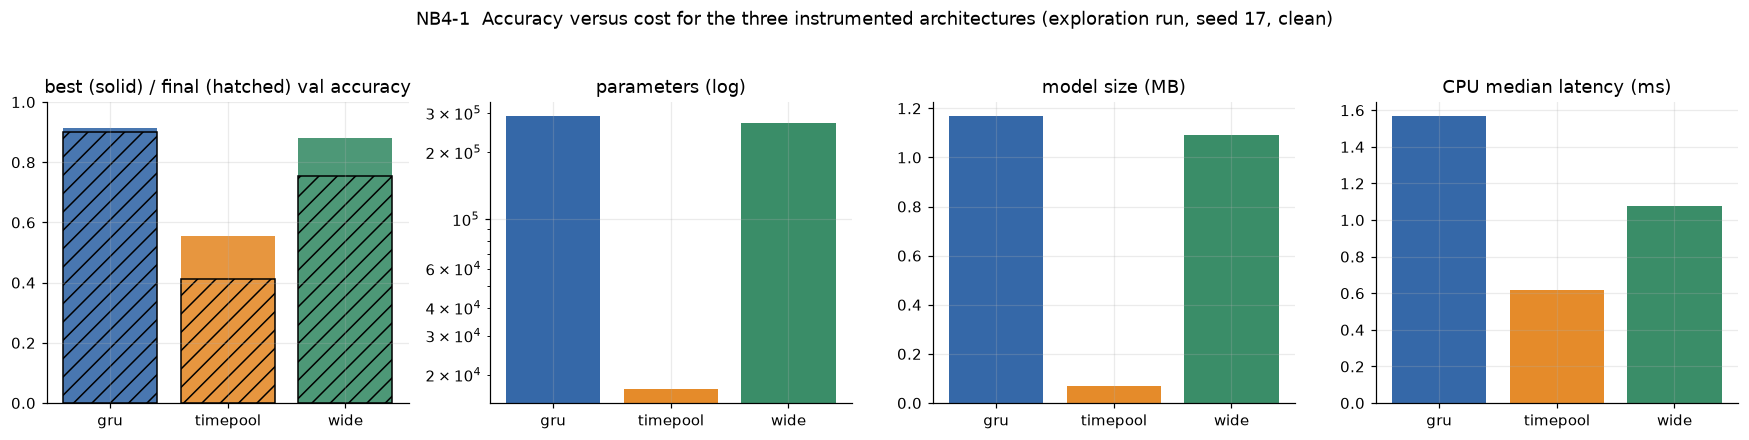

[N4.3.2] resource figure drawn


In [8]:
# N4.3.2: resources vs accuracy figure.
fig, ax = plt.subplots(1, 4, figsize=(16, 3.8))
for a in ARCHS:
    r = DATA[a]["res"]; rs = r["resources"]
    ax[0].bar(a, r["best_val_accuracy"], color=ACOL[a], alpha=0.9)
    ax[0].bar(a, r["final_val_accuracy"], color="none", edgecolor="black", hatch="//")
    ax[1].bar(a, rs["parameters"], color=ACOL[a])
    ax[2].bar(a, rs["model_size_bytes"] / 1e6, color=ACOL[a])
    ax[3].bar(a, rs["latency_cpu_median_ms"], color=ACOL[a])
ax[0].set(title="best (solid) / final (hatched) val accuracy", ylim=(0, 1))
ax[1].set(title="parameters (log)", yscale="log")
ax[2].set(title="model size (MB)")
ax[3].set(title="CPU median latency (ms)")
fig.suptitle("NB4-1  Accuracy versus cost for the three instrumented architectures (exploration run, seed 17, clean)", y=1.04)
fig.tight_layout()
savefig(fig, "NB4-1_resources.png")
print("[N4.3.2] resource figure drawn")

### How to read this chart

**Data source:** `<ARTIFACT_ROOT>/metrics/arch-{gru,timepool,wide}.result.json`, fields `best_val_accuracy`,
`final_val_accuracy`, `parameters`, `resources/model_size_bytes` and `resources/latency_cpu_median_ms`.

**Axes:** each of the four panels has the architecture on the horizontal axis. Panel one shows validation
accuracy on $[0,1]$ (solid bar: best epoch; hatched outline: final epoch, so a large gap between them means the
run ended far from its best point). Panels two to four show parameter count (log scale), serialized model size
in MB, and the recorded CPU median forward latency in ms.

**Interpretation:** `gru` and `wide` are roughly $16$--$17\times$ larger than `timepool` in parameters, but
`gru` is the only one with a high and stable accuracy; `wide` reaches a high best accuracy yet ends visibly lower.
Cost alone does not explain accuracy: `wide` and `gru` have nearly the same parameter count and very different
stability, which is the question Section 5 examines.

**Falsifier:** if accuracy simply tracked parameter count, `wide` and `gru` would tie and both would clearly beat
`timepool`; the recorded gap between `wide`'s best and final accuracy, and `gru`'s smaller gap, contradict a
pure-capacity reading. Any bar with height zero would indicate a missing field rather than a real result.

### 3.2 Recorded timing from the worker logs

Each arm was trained by a separate worker process that wrote its own timestamped log. The cell parses the
`run_arm done in ...` and `probe overhead ...` lines. It exists to keep the cost discussion honest: the
in-training probes are not free, and the table shows how large the overhead was relative to training.

In [9]:
# N4.3.3: parse per-arm worker logs for timing lines.
trows = []
for a in ARCHS:
    txt = (MET / f"arch-{a}.log").read_text()
    m_run = re.search(r"run_arm done in ([\d.]+)s \(probe overhead ([\d.]+)s total\)", txt)
    m_sum = re.search(r"summarise_arm done in ([\d.]+)s", txt)
    m_best = re.search(r"DONE best_val_acc=([\d.]+)", txt)
    trows.append({"arch": a, "run_arm_s": float(m_run.group(1)) if m_run else np.nan,
                  "probe_overhead_s": float(m_run.group(2)) if m_run else np.nan,
                  "summarise_arm_s": float(m_sum.group(1)) if m_sum else np.nan,
                  "log_best_val_acc": float(m_best.group(1)) if m_best else np.nan})
TIMING = pd.DataFrame(trows).set_index("arch")
TIMING["probe_overhead_frac"] = (TIMING["probe_overhead_s"] / TIMING["run_arm_s"]).round(3)
display(TIMING)
for a in ARCHS:
    check(f"N4.3.3[{a}.log_vs_json]", abs(TIMING.loc[a, "log_best_val_acc"] - DATA[a]["res"]["best_val_accuracy"]) < 5e-4,
          f"log best {TIMING.loc[a, 'log_best_val_acc']:.4f} vs json {DATA[a]['res']['best_val_accuracy']:.4f}")
    check(f"N4.3.3[{a}.timing_parsed]", np.isfinite(TIMING.loc[a, "run_arm_s"]), f"run_arm {TIMING.loc[a, 'run_arm_s']:.1f}s, probe overhead {TIMING.loc[a, 'probe_overhead_s']:.1f}s")

          run_arm_s  probe_overhead_s  summarise_arm_s  log_best_val_acc  probe_overhead_frac
arch                                                                                         
gru           122.5              22.9              2.0            0.9127                0.187
timepool      127.6              50.1              2.0            0.5556                0.393
wide          152.1              58.6              2.0            0.8790                0.385

[N4.3.3[gru.log_vs_json]] log best 0.9127 vs json 0.9127 -> PASS
[N4.3.3[gru.timing_parsed]] run_arm 122.5s, probe overhead 22.9s -> PASS
[N4.3.3[timepool.log_vs_json]] log best 0.5556 vs json 0.5556 -> PASS
[N4.3.3[timepool.timing_parsed]] run_arm 127.6s, probe overhead 50.1s -> PASS
[N4.3.3[wide.log_vs_json]] log best 0.8790 vs json 0.8790 -> PASS
[N4.3.3[wide.timing_parsed]] run_arm 152.1s, probe overhead 58.6s -> PASS


### 3.3 The legacy `baseline` control, from its logs

The `baseline` (`LogMelCNN`) has no result JSON and no probe file, because its `AdaptiveAvgPool2d((1,1))` leaves
no temporal axis for the sequence probes. The only record of it is the set of superseded legacy training logs in
`<ARTIFACT_ROOT>/metrics/legacy_6arm_logs/`. They come from an earlier pipeline (before the true-CE loss accounting fix),
so **their loss values are not comparable to Section 5's**, and accuracy comparison is at best indicative. The
cell parses every `epoch n/36 done: ... val_accuracy=...` line and reports per-run best and final validation
accuracy. No row is invented: the table is exactly what the logs contain.

In [10]:
# N4.3.4: parse legacy logs (superseded runs) into a table of best/final val accuracy.
pat = re.compile(r"epoch (\d+)/(\d+) done: train_loss=([\d.]+) val_loss=([\d.]+) val_accuracy=([\d.]+)")
LEG = {}
lrows = []
for p in sorted((MET / "legacy_6arm_logs").glob("*.log")):  # empty if the folder is absent on this host
    ms = [pat.search(l) for l in p.read_text().splitlines()]
    ms = [m for m in ms if m]
    ep = np.array([int(m.group(1)) for m in ms]); acc = np.array([float(m.group(5)) for m in ms])
    LEG[p.stem] = {"epoch": ep, "train": np.array([float(m.group(3)) for m in ms]), "val": np.array([float(m.group(4)) for m in ms]), "acc": acc}
    cond, seed = p.stem.split("_seed")
    lrows.append({"condition": cond, "seed": int(seed), "epochs_logged": len(ep), "best_val_acc": acc.max(), "best_epoch": int(ep[acc.argmax()]), "final_val_acc": acc[-1]})
LEGACY = pd.DataFrame(lrows)
display(LEGACY.round(4))
check("N4.3.4", len(LEGACY) == 9, f"{len(LEGACY)} legacy logs parsed under {MET / 'legacy_6arm_logs'}")
clean_leg = LEGACY[LEGACY.condition == "clean"]
print("legacy clean-condition final val acc by seed:", clean_leg.set_index("seed")["final_val_acc"].round(4).to_dict())
print("legacy clean-condition best  val acc by seed:", clean_leg.set_index("seed")["best_val_acc"].round(4).to_dict())
hit = [k for k, v in LEG.items() if np.isclose(v["acc"], 0.4742, atol=5e-5).any()]
for k in hit:
    e = LEG[k]["epoch"][np.isclose(LEG[k]["acc"], 0.4742, atol=5e-5)]
    print(f"value 0.4742 occurs in {k} only at epochs {e.tolist()}; that run's final val_acc is {LEG[k]['acc'][-1]:.4f}")
note("N4.3.4[0.4742]", "the value 0.4742 is a mid-run epoch value of legacy clean_seed17, NOT its final val accuracy (0.3730); no artifact records 0.4742 as a final baseline accuracy")
for _, r in LEGACY.iterrows():
    check(f"N4.3.4[{r['condition']}_{r['seed']}]", 1 <= r["epochs_logged"] <= 36, f"{r['epochs_logged']} epochs logged, best {r['best_val_acc']:.4f}, final {r['final_val_acc']:.4f}")

  condition  seed  epochs_logged  best_val_acc  best_epoch  final_val_acc
0  acoustic    17              7        0.2698           6         0.2679
1  acoustic    18              6        0.2520           6         0.2520
2  acoustic    19              7        0.2897           5         0.2778
3     clean    17             36        0.5099          34         0.3730
4     clean    18             36        0.5913          36         0.5913
5     clean    19             36        0.5159          22         0.3433
6   masking    17             36        0.3869          36         0.3869
7   masking    18             36        0.4365          34         0.3135
8   masking    19             36        0.3790          29         0.3194

[N4.3.4] 9 legacy logs parsed under /home/centos/data/projects/for-money/computer-science/upwork/flex-projects-4/robust-speech-command-study/runtime/metrics/legacy_6arm_logs -> PASS
legacy clean-condition final val acc by seed: {17: 0.373, 18: 0.5913, 19: 0.3433}
legacy clean-condition best  val acc by seed: {17: 0.5099, 18: 0.5913, 19: 0.5159}
value 0.4742 occurs in clean_seed17 only at epochs [22, 23]; that run's final val_acc is 0.3730
[N4.3.4[0.4742]] the value 0.4742 is a mid-run epoch value of legacy clean_seed17, NOT its final val accuracy (0.3730); no artifact records 0.4742 as a final baseline accuracy -> NOTE
[N4.3.4[acoustic_17]] 7 epochs logged, best 0.2698, final 0.2679 -> PASS
[N4.3.4[acoustic_18]] 6 epochs logged, best 0.2520, final 0.2520 -> PASS
[N4.3.4[acoustic_19]] 7 epochs logged, best 0.2897, final 0.2778 -> PASS
[N4.3.4[clean_17]] 36 epochs logged, best 0.5099, final 0.3730 -> PASS
[N4.3.4[clean_18]] 36 epochs logged, best 0.5913, final 0.5913 -> PASS
[N4.3.4[clea

### Figure NB4-2: Legacy baseline validation accuracy versus the new architectures

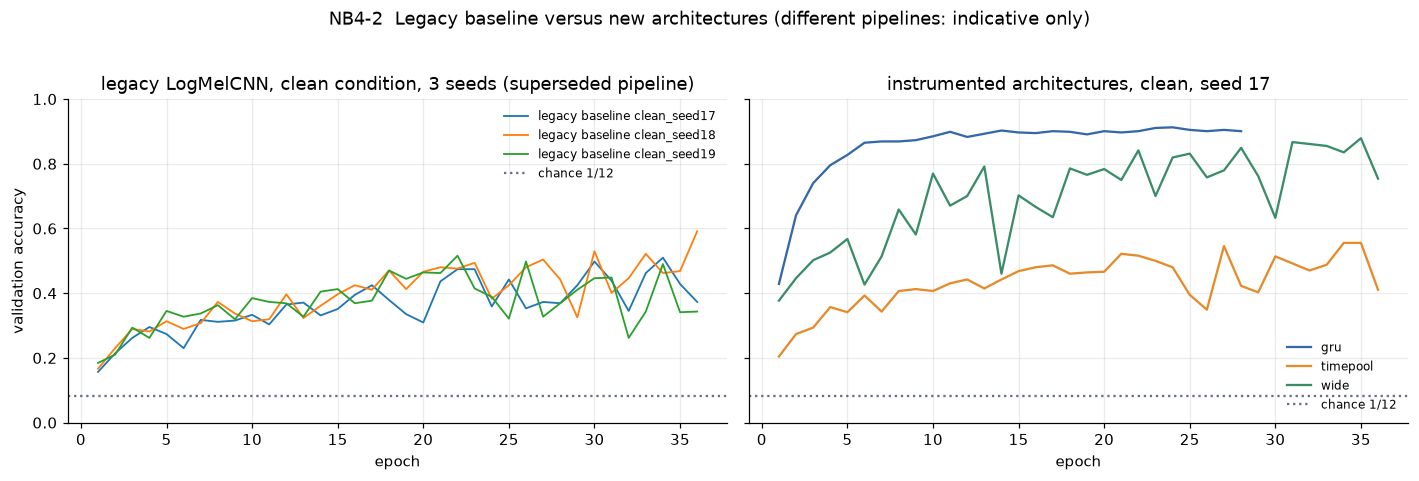

[N4.3.5] legacy-vs-new figure drawn


In [11]:
# N4.3.5: legacy clean-condition curves vs new architectures' val accuracy per epoch.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for k, v in LEG.items():
    if k.startswith("clean"):
        ax[0].plot(v["epoch"], v["acc"], lw=1.2, label=f"legacy baseline {k}")
for a in ARCHS:
    h = DATA[a]["res"]["history"]
    ax[1].plot([r["epoch"] + 1 for r in h], [r["val_accuracy"] for r in h], color=ACOL[a], label=a)
for x in ax:
    x.axhline(1 / 12, color="#667085", ls=":", label="chance 1/12")
    x.set(xlabel="epoch", ylim=(0, 1))
ax[0].set(ylabel="validation accuracy", title="legacy LogMelCNN, clean condition, 3 seeds (superseded pipeline)")
ax[1].set(title="instrumented architectures, clean, seed 17")
ax[0].legend(frameon=False, fontsize=8); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-2  Legacy baseline versus new architectures (different pipelines: indicative only)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-2_legacy_vs_new.png")
print("[N4.3.5] legacy-vs-new figure drawn")

### How to read this chart

**Data source:** left panel from `<ARTIFACT_ROOT>/metrics/legacy_6arm_logs/clean_seed{17,18,19}.log` (parsed by regex);
right panel from `history` in `arch-*.result.json`.

**Axes:** horizontal is epoch, vertical is validation accuracy on $[0,1]$; the dotted line is chance for 12
classes, $1/12 \approx 0.083$. The two panels share the vertical axis so the spread is directly comparable.

**Interpretation:** the legacy baseline's validation accuracy swings by tens of points from epoch to epoch and
differs greatly across seeds (final values of about $0.37$, $0.59$, and $0.34$). `timepool` lands inside that same
noisy band, whereas `gru` climbs to roughly $0.9$ and stays there. The seed-to-seed spread of the legacy control is
itself a caution against reading any single-seed comparison of `timepool` and `baseline` as decisive.

**Falsifier:** if `timepool`'s curve sat clearly above every legacy seed at every late epoch, the claim below that
time retention alone is not sufficient would be contradicted. It does not: at several late epochs the legacy seeds
are above `timepool`'s final value.

### 3.4 The honest negative finding: retaining the time axis alone did not help reliably

`timepool` is `LogMelCNN` with a single change: the final pool keeps $8$ temporal slots instead of one, so the
classifier can see *when* energy occurred. It was built to test whether the temporal collapse alone is the
ceiling. Its best validation accuracy is $0.5556$ and its final is $0.4107$.

An assumption carried into this notebook's planning was that `timepool` performs **worse** than the `baseline` and quoted a
recorded `baseline` final accuracy of $0.4742$. **The artifacts on disk do not support that exact statement.**
The only occurrence of $0.4742$ is a mid-run value of legacy `clean_seed17` (epochs 22 and 23); that run finished
at $0.3730$, and the three legacy clean seeds finish at $0.3730$, $0.5913$, and $0.3433$. So `timepool` (final
$0.4107$) is not below the baseline in any way these files can demonstrate; it lies inside the baseline's own
seed-to-seed spread. What *is* supported is the weaker but still real negative result: **retaining the time axis
by itself produced no reliable improvement** -- `timepool`'s late-epoch validation loss and accuracy are as
erratic as the legacy control's, and it is unstable in the in-training diagnostics too (Section 5).

The contrast is the interesting part. `gru`, which adds a recurrence over the same time axis, reaches best
$0.9127$ and final $0.9008$ with a smooth validation loss. The inductive bias of the recurrence, not merely the
presence of temporal positions in the classifier input, is what accompanies the large improvement in this run.
That is a single-seed, single-condition observation; the caveat is developed in Section 8.

In [12]:
# N4.3.6: quantify the negative finding from the files: timepool vs legacy baseline seed band vs gru.
tp, gr, wd = (DATA[a]["res"] for a in ("timepool", "gru", "wide"))
band_final = (clean_leg["final_val_acc"].min(), clean_leg["final_val_acc"].max())
band_best = (clean_leg["best_val_acc"].min(), clean_leg["best_val_acc"].max())
print(f"legacy baseline clean, final val acc range over 3 seeds: {band_final[0]:.4f} .. {band_final[1]:.4f}")
print(f"legacy baseline clean, best  val acc range over 3 seeds: {band_best[0]:.4f} .. {band_best[1]:.4f}")
print(f"timepool best {tp['best_val_accuracy']:.4f}, final {tp['final_val_accuracy']:.4f}")
print(f"gru      best {gr['best_val_accuracy']:.4f}, final {gr['final_val_accuracy']:.4f}")
va_tp = np.array([r["val_accuracy"] for r in tp["history"]]); va_gr = np.array([r["val_accuracy"] for r in gr["history"]])
for a, va in (("timepool", va_tp), ("gru", va_gr)):
    print(f"{a}: std of epoch-to-epoch val-acc change over the last 10 epochs = {np.std(np.diff(va[-10:])):.4f}")
check("N4.3.6[timepool_in_band]", band_final[0] <= tp["final_val_accuracy"] <= band_final[1], "timepool final val acc lies inside the legacy baseline seed band")
check("N4.3.6[gru_above_band]", gr["final_val_accuracy"] > band_final[1] + 0.2, "gru final val acc exceeds the whole legacy seed band by > 0.2")
check("N4.3.6[timepool_gain_claim]", tp["final_val_accuracy"] < 0.5, "timepool final val acc < 0.5: no reliable improvement")
check("N4.3.6[gru_smoother]", np.std(np.diff(va_gr[-10:])) < np.std(np.diff(va_tp[-10:])), "gru's late val-acc changes are smaller than timepool's")

legacy baseline clean, final val acc range over 3 seeds: 0.3433 .. 0.5913
legacy baseline clean, best  val acc range over 3 seeds: 0.5099 .. 0.5913
timepool best 0.5556, final 0.4107
gru      best 0.9127, final 0.9008
timepool: std of epoch-to-epoch val-acc change over the last 10 epochs = 0.0765
gru: std of epoch-to-epoch val-acc change over the last 10 epochs = 0.0061
[N4.3.6[timepool_in_band]] timepool final val acc lies inside the legacy baseline seed band -> PASS
[N4.3.6[gru_above_band]] gru final val acc exceeds the whole legacy seed band by > 0.2 -> PASS
[N4.3.6[timepool_gain_claim]] timepool final val acc < 0.5: no reliable improvement -> PASS
[N4.3.6[gru_smoother]] gru's late val-acc changes are smaller than timepool's -> PASS


True

### 3.5 Reconstructing the early-stopping decision from the recorded history

Early stopping in `src/train.py` keeps a running best validation loss, resets a counter when the loss improves,
increments it otherwise, and stops when the counter reaches the patience ($8$ in this run). The recorded
`history`, `best_epoch` and `epochs_run` are enough to replay that rule exactly, which gives an independent check
that the three result files really are the output of one consistent training loop, and clarifies which epoch the
saved weights come from. Nothing is inferred beyond the rule stated in the source.

In [13]:
# N4.3.7: replay the early-stopping rule (strict improvement, patience 8) on each recorded validation-loss series.
PATIENCE, MAX_EPOCHS = 8, 36
ES = []
for a in ARCHS:
    res = DATA[a]["res"]; vl = [r["val_loss"] for r in res["history"]]
    best, best_ep, counter, stop_after = float("inf"), 0, 0, None
    for ep, v in enumerate(vl):
        if v < best:
            best, best_ep, counter = v, ep, 0
        else:
            counter += 1
        if counter >= PATIENCE:
            stop_after = ep + 1
            break
    ran = stop_after if stop_after is not None else len(vl)
    ES.append({"arch": a, "replayed_best_epoch": best_ep, "recorded_best_epoch": res["best_epoch"], "replayed_epochs_run": ran,
               "recorded_epochs_run": res["epochs_run"], "stopped_early": stop_after is not None, "epochs_after_best": ran - 1 - best_ep,
               "min_val_loss": best})
ESD = pd.DataFrame(ES).set_index("arch")
display(ESD.round(4))
for a in ARCHS:
    check(f"N4.3.7[{a}.best_epoch_replay]", ESD.loc[a, "replayed_best_epoch"] == ESD.loc[a, "recorded_best_epoch"], "replayed best epoch equals recorded best_epoch")
    check(f"N4.3.7[{a}.epochs_run_replay]", ESD.loc[a, "replayed_epochs_run"] == ESD.loc[a, "recorded_epochs_run"], "replayed stopping epoch equals recorded epochs_run")
check("N4.3.7[gru_stopped_early]", bool(ESD.loc["gru", "stopped_early"]) and ESD.loc["gru", "recorded_epochs_run"] == 28, "gru early-stopped at epoch 28 (best epoch 19 + 8 non-improving epochs)")
check("N4.3.7[others_hit_cap]", all(ESD.loc[a, "recorded_epochs_run"] == MAX_EPOCHS for a in ("timepool", "wide")), "timepool and wide ran to the 36-epoch cap without triggering patience")
note("N4.3.7", "timepool and wide were still improving their best validation loss within 2 epochs of the cap (best_epoch 34): neither had converged when training ended")

          replayed_best_epoch  recorded_best_epoch  replayed_epochs_run  recorded_epochs_run  stopped_early  epochs_after_best  min_val_loss
arch                                                                                                                                        
gru                        19                   19                   28                   28           True                  8        0.3122
timepool                   34                   34                   36                   36          False                  1        1.3658
wide                       34                   34                   36                   36          False                  1        0.4320

[N4.3.7[gru.best_epoch_replay]] replayed best epoch equals recorded best_epoch -> PASS
[N4.3.7[gru.epochs_run_replay]] replayed stopping epoch equals recorded epochs_run -> PASS
[N4.3.7[timepool.best_epoch_replay]] replayed best epoch equals recorded best_epoch -> PASS
[N4.3.7[timepool.epochs_run_replay]] replayed stopping epoch equals recorded epochs_run -> PASS
[N4.3.7[wide.best_epoch_replay]] replayed best epoch equals recorded best_epoch -> PASS
[N4.3.7[wide.epochs_run_replay]] replayed stopping epoch equals recorded epochs_run -> PASS
[N4.3.7[gru_stopped_early]] gru early-stopped at epoch 28 (best epoch 19 + 8 non-improving epochs) -> PASS
[N4.3.7[others_hit_cap]] timepool and wide ran to the 36-epoch cap without triggering patience -> PASS
[N4.3.7] timepool and wide were still improving their best validation loss within 2 epochs of the cap (best_epoch 34): neither had converged when training ended -> NOTE


**What the replay shows.** The rule reproduces the recorded stopping point for all three architectures, so the
history and the summary fields are mutually consistent. `gru` stopped at epoch 28 because $8$ consecutive epochs
after its best validation loss (epoch index 19) failed to improve on it. `timepool` and `wide` reached the
36-epoch cap with their best validation loss at epoch index $34$, i.e. still moving; a longer run could have
changed their numbers, and this notebook cannot say by how much. That is a limitation of the *race*, not of the
analysis, and it applies most to `wide`, whose best-loss epoch is also its best-accuracy epoch.

### 3.6 Legacy loss curves and their volatility

The legacy logs contain validation loss too. Plotting them beside the instrumented runs puts the volatility of the
legacy control in the same frame as `timepool` and `wide`. As before, the legacy loss values come from the earlier
accounting pipeline and are not numerically comparable to Section 5; only the *shape* (steady versus erratic) is
compared.

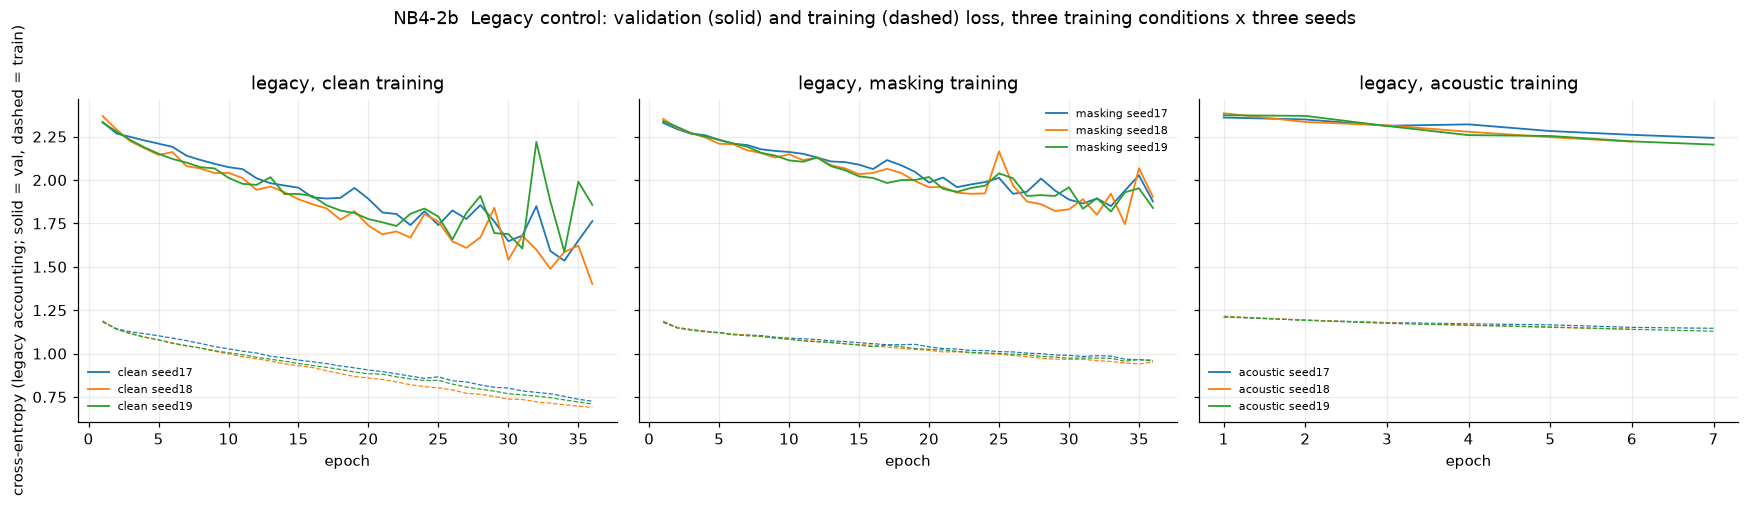

                 epochs  val_loss_min  val_loss_last  val_loss_std_diff_last10  val_acc_std_diff_last10
run                                                                                                    
clean_seed17         36        1.5355         1.7631                    0.1307                   0.0718
clean_seed18         36        1.4008         1.4008                    0.1546                   0.1062
clean_seed19         36        1.5867         1.8565                    0.3021                   0.0999
masking_seed17       36        1.8497         1.8765                    0.0779                   0.0605
masking_seed18       36        1.7453         1.9030                    0.1454                   0.0690
masking_seed19       36        1.8185         1.8391                    0.0761                   0.0466
acoustic_seed17       7        2.2425         2.2425                       NaN                      NaN
acoustic_seed18       6        2.2210         2.2210            

[N4.3.8[all_runs]] 9 legacy runs plotted -> PASS
legacy clean: mean late val-acc volatility 0.0926 vs timepool 0.0765, gru 0.0061
[N4.3.8[gru_calmer_than_legacy]] gru's late validation accuracy is steadier than the legacy clean baseline's average -> PASS


True

In [14]:
# N4.3.8: legacy validation-loss curves per training condition, and a volatility table.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
vol_rows = []
for ax, cond in zip(axes, ("clean", "masking", "acoustic")):
    for k, v in LEG.items():
        if k.startswith(cond):
            ax.plot(v["epoch"], v["val"], lw=1.2, label=k.replace("_", " "))
            ax.plot(v["epoch"], v["train"], lw=0.8, ls="--", color=ax.lines[-1].get_color())
            vol_rows.append({"run": k, "epochs": len(v["epoch"]), "val_loss_min": v["val"].min(), "val_loss_last": v["val"][-1],
                             "val_loss_std_diff_last10": np.std(np.diff(v["val"][-10:])) if len(v["val"]) >= 11 else np.nan,
                             "val_acc_std_diff_last10": np.std(np.diff(v["acc"][-10:])) if len(v["acc"]) >= 11 else np.nan})
    ax.set(xlabel="epoch", title=f"legacy, {cond} training"); ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel("cross-entropy (legacy accounting; solid = val, dashed = train)")
fig.suptitle("NB4-2b  Legacy control: validation (solid) and training (dashed) loss, three training conditions x three seeds", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-2b_legacy_loss.png")
LV = pd.DataFrame(vol_rows).set_index("run")
display(LV.round(4))
check("N4.3.8[all_runs]", len(LV) == 9, f"{len(LV)} legacy runs plotted")
clean_vol = LV.loc[[i for i in LV.index if i.startswith("clean")], "val_acc_std_diff_last10"].mean()
print(f"legacy clean: mean late val-acc volatility {clean_vol:.4f} vs timepool {np.std(np.diff(va_tp[-10:])):.4f}, gru {np.std(np.diff(va_gr[-10:])):.4f}")
check("N4.3.8[gru_calmer_than_legacy]", np.std(np.diff(va_gr[-10:])) < clean_vol, "gru's late validation accuracy is steadier than the legacy clean baseline's average")

### How to read this chart

**Data source:** the legacy logs `<ARTIFACT_ROOT>/metrics/legacy_6arm_logs/{clean,masking,acoustic}_seed{17,18,19}.log`,
parsed by regular expression for `epoch n/36 done: train_loss=... val_loss=... val_accuracy=...`.

**Axes:** horizontal is epoch; vertical is cross-entropy under the *legacy* loss accounting, shared across the
three panels. Solid lines are validation loss, dashed lines training loss, one colour per seed.

**Interpretation:** in every legacy condition the training loss declines steadily while the validation loss stays
far above it and fluctuates from epoch to epoch (the legacy control generalises poorly and inconsistently). The
`acoustic` runs stop after only $6$--$7$ epochs (early stopping), at a validation accuracy near $0.27$, so
augmenting acoustically hurt this small legacy model rather than helping. The `clean` runs are the relevant
control for this notebook, and their late-epoch instability is of the same order as `timepool`'s.

**Falsifier:** if the legacy validation loss tracked its training loss closely, the claim that `timepool`'s
erratic behaviour is not a new pathology (it resembles the control) would be undercut. The wide gap and the
oscillations are visible directly.

### 3.7 How tightly validation loss and validation accuracy move together

Loss and accuracy are different functionals of the same logits. When a model becomes overconfident, validation loss
can rise while accuracy stays flat or even improves; when both move together the model is simply getting better or
worse. The rank correlation across epochs, computed per architecture, says which regime each is in.

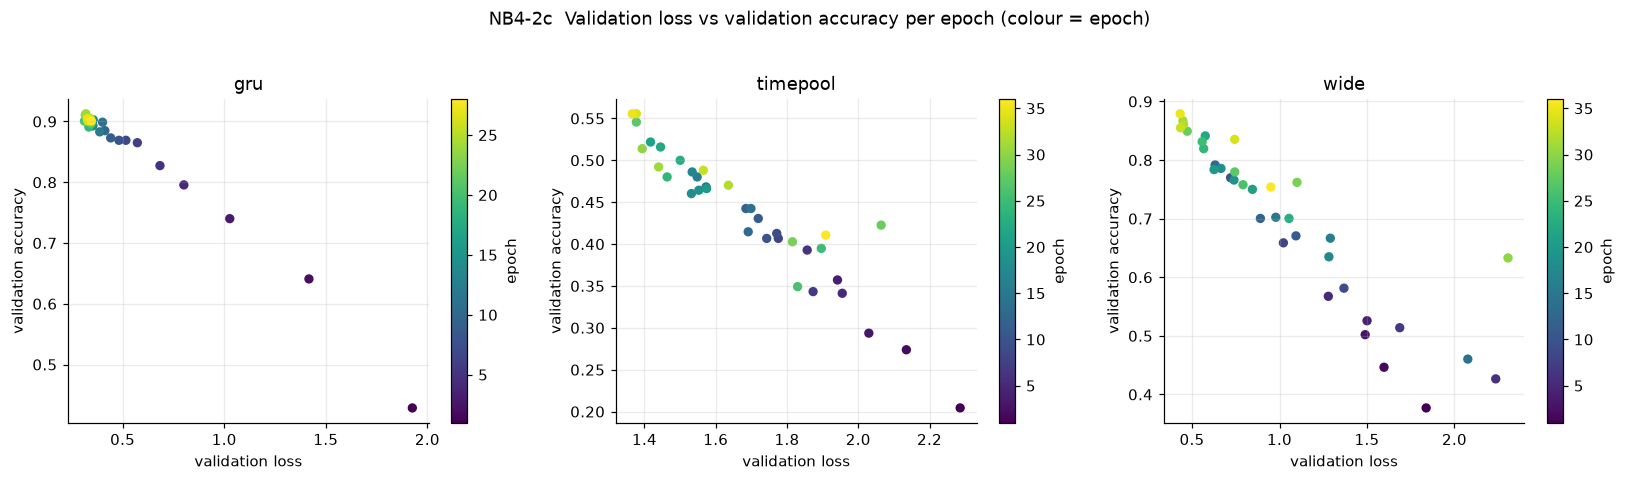

          spearman(val_loss, val_acc)  mean train/val gap  gap_last  epochs_with_val_loss_up_and_acc_up
arch                                                                                                   
gru                            -0.887               0.154     0.336                                   2
timepool                       -0.946               0.247     0.929                                   3
wide                           -0.959               0.652     0.932                                   1

[N4.3.9[gru.rho_negative]] rho=-0.887: lower loss goes with higher accuracy -> PASS
[N4.3.9[timepool.rho_negative]] rho=-0.946: lower loss goes with higher accuracy -> PASS
[N4.3.9[wide.rho_negative]] rho=-0.959: lower loss goes with higher accuracy -> PASS


In [15]:
# N4.3.9: per-epoch val_loss vs val_accuracy scatter and Spearman rho, with train/val gap.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
LA = []
for ax, a in zip(axes, ARCHS):
    h = DATA[a]["res"]["history"]
    vl = np.array([r["val_loss"] for r in h]); va = np.array([r["val_accuracy"] for r in h]); tl = np.array([r["train_loss"] for r in h])
    sc = ax.scatter(vl, va, c=np.arange(1, len(vl) + 1), cmap="viridis", s=26)
    ax.set(xlabel="validation loss", ylabel="validation accuracy", title=a); fig.colorbar(sc, ax=ax, label="epoch")
    rho = spearmanr(vl, va)[0]
    LA.append({"arch": a, "spearman(val_loss, val_acc)": rho, "mean train/val gap": float(np.mean(vl - tl)), "gap_last": float(vl[-1] - tl[-1]),
               "epochs_with_val_loss_up_and_acc_up": int(np.sum((np.diff(vl) > 0) & (np.diff(va) > 0)))})
fig.suptitle("NB4-2c  Validation loss vs validation accuracy per epoch (colour = epoch)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-2c_loss_vs_acc.png")
LAD = pd.DataFrame(LA).set_index("arch")
display(LAD.round(3))
for a in ARCHS:
    check(f"N4.3.9[{a}.rho_negative]", LAD.loc[a, "spearman(val_loss, val_acc)"] < 0, f"rho={LAD.loc[a, 'spearman(val_loss, val_acc)']:+.3f}: lower loss goes with higher accuracy")

### How to read this chart

**Data source:** `history` in `<ARTIFACT_ROOT>/metrics/arch-*.result.json` (`val_loss`, `val_accuracy`, per epoch).

**Axes:** each point is one epoch; horizontal is validation loss, vertical validation accuracy, colour the epoch.

**Interpretation:** a clean downward-sloping cloud means loss and accuracy agree. `gru`'s points form a tight,
monotone curve running from high loss and low accuracy (early, dark) to low loss and high accuracy (late, bright).
`wide`'s cloud is broad and its later epochs scatter across a large range of loss at broadly similar accuracy,
the signature of confidence swings rather than of the predicted classes changing. `timepool` sits in a narrow band
at high loss. The table counts epochs in which loss and accuracy rose together, a direct measure of that decoupling.

**Falsifier:** if `wide`'s late points lay on the same curve as its early ones, its loss oscillations would just be
accuracy oscillations; the loose cloud indicates a part of the instability is confidence, not classification.

### 3.8 Cost efficiency, tabulated

Accuracy per parameter and per millisecond of CPU latency, computed from the recorded fields only. These are
descriptive ratios on one seed, not a Pareto claim.

In [16]:
# N4.3.10: accuracy-per-cost ratios derived from the result files.
CE = []
for a in ARCHS:
    r = DATA[a]["res"]; rs = r["resources"]; acc = r["history"][r["best_epoch"]]["val_accuracy"]
    CE.append({"arch": a, "acc_at_best_epoch": acc, "parameters": rs["parameters"], "size_MB": rs["model_size_bytes"] / 1e6,
               "bytes_per_param": rs["model_size_bytes"] / rs["parameters"], "latency_ms": rs["latency_cpu_median_ms"],
               "acc_per_100k_params": acc / rs["parameters"] * 1e5, "acc_per_ms": acc / rs["latency_cpu_median_ms"],
               "peak_memory_mb": rs["peak_memory_mb"], "device": rs["device"]})
CED = pd.DataFrame(CE).set_index("arch")
display(CED.round(4))
for a in ARCHS:
    check(f"N4.3.10[{a}.bytes_per_param]", 3.9 < CED.loc[a, "bytes_per_param"] < 4.5, f"{CED.loc[a, 'bytes_per_param']:.3f} bytes/param (float32 = 4 plus buffers)")
check("N4.3.10[latency_order]", CED.loc["timepool", "latency_ms"] < CED.loc["gru", "latency_ms"] or CED.loc["timepool", "latency_ms"] < CED.loc["wide", "latency_ms"], "timepool is cheaper than at least one of the large models on CPU latency")
note("N4.3.10", "latency was measured with a small number of repeats on the training host; treat differences of a few tenths of a millisecond as noise")

          acc_at_best_epoch  parameters  size_MB  bytes_per_param  latency_ms  acc_per_100k_params  acc_per_ms  peak_memory_mb  device
arch                                                                                                                                  
gru                  0.9008      291564   1.1670           4.0027      1.5663               0.3090      0.5751        816.3521  cuda:0
timepool             0.5556       17212   0.0695           4.0386      0.6177               3.2277      0.8994        344.7910  cuda:0
wide                 0.8790      271692   1.0899           4.0114      1.0774               0.3235      0.8158       1096.1162  cuda:0

[N4.3.10[gru.bytes_per_param]] 4.003 bytes/param (float32 = 4 plus buffers) -> PASS
[N4.3.10[timepool.bytes_per_param]] 4.039 bytes/param (float32 = 4 plus buffers) -> PASS
[N4.3.10[wide.bytes_per_param]] 4.011 bytes/param (float32 = 4 plus buffers) -> PASS
[N4.3.10[latency_order]] timepool is cheaper than at least one of the large models on CPU latency -> PASS
[N4.3.10] latency was measured with a small number of repeats on the training host; treat differences of a few tenths of a millisecond as noise -> NOTE


## 4. Checkpoint reload and accuracy re-derivation

The instrumented checkpoints live at `<ARTIFACT_ROOT>/checkpoints/arch-{gru,timepool,wide}_clean_seed17_instrumented.pt`
(on the execution host, `/content/drive/MyDrive/deep-learning-first-project/checkpoints/`). Verification has two
layers, of different strength, and they prove different things.

**Layer 1, architecture reconstruction (Section 4.1).** `torch.load(..., map_location="cpu")`, instantiate the
matching class from `src/models.py`, `load_state_dict(..., strict=True)`, assert zero missing and zero unexpected
keys, assert the live parameter count equals the `parameters` field of that arch's result JSON, and cross-check any
metrics stored inside the checkpoint against the result JSON. This proves the architecture code reconstructs the
trained weights exactly and that the artifacts are self-consistent. It does **not** by itself show the recorded
accuracy is right.

**Layer 2, accuracy re-derivation (Section 4.2).** Rebuild the real Speech Commands bundle with the project's own
`assemble_bundle`, recompute the features and the train-split normalisation statistics exactly as
`src/arms.py::run_arm` does, run each loaded checkpoint over the real validation split, and compare the computed
accuracy with the recorded `best_val_accuracy` and `final_val_accuracy`. This needs the dataset and (optionally)
a GPU, so it is tagged `offloaded` and gated on the bundle being present. It never substitutes synthetic audio.

In [17]:
# N4.4.1a: live parameter count of every class in src.models vs the recorded count (needs no checkpoint; runs anywhere).
import torch
from src.models import ConvGRU, TimePoolCNN, WideCNN, LogMelCNN

CLASS_OF = {"gru": ConvGRU, "timepool": TimePoolCNN, "wide": WideCNN}
for a in ARCHS:
    live = sum(p.numel() for p in CLASS_OF[a]().parameters())
    check(f"N4.4.1a[{a}.live_param_count]", live == DATA[a]["res"]["parameters"], f"src.models.{CLASS_OF[a].__name__} has {live} params vs recorded {DATA[a]['res']['parameters']}")
base_n = sum(p.numel() for p in LogMelCNN().parameters())
check("N4.4.1a[baseline_params]", base_n == 14524, f"LogMelCNN parameter count from src.models = {base_n} (charter says 14,524; no artifact exists for it)")

[N4.4.1a[gru.live_param_count]] src.models.ConvGRU has 291564 params vs recorded 291564 -> PASS
[N4.4.1a[timepool.live_param_count]] src.models.TimePoolCNN has 17212 params vs recorded 17212 -> PASS
[N4.4.1a[wide.live_param_count]] src.models.WideCNN has 271692 params vs recorded 271692 -> PASS
[N4.4.1a[baseline_params]] LogMelCNN parameter count from src.models = 14524 (charter says 14,524; no artifact exists for it) -> PASS


True

### 4.1 Checkpoint reload (strict) and cross-check against the result JSON

In [ ]:
# N4.4.1: strict checkpoint reload and consistency check. Meant to run on the host that has the checkpoints.
LOADED = {}
for a in ARCHS:
    res = DATA[a]["res"]
    path = CKPT_DIR / f"arch-{a}_clean_seed17_instrumented.pt"
    if not path.is_file():
        note(f"N4.4.1[{a}.checkpoint]", f"MISSING on {HOST}: looked for {path}")
        continue
    model = CLASS_OF[a]()
    blob = torch.load(path, map_location="cpu")
    state = blob
    if isinstance(blob, dict):
        for key in ("state_dict", "model_state_dict", "model"):
            if key in blob and isinstance(blob[key], dict):
                state = blob[key]
                break
    out = model.load_state_dict(state, strict=True)
    check(f"N4.4.1[{a}.strict_load]", len(out.missing_keys) == 0 and len(out.unexpected_keys) == 0, f"missing={len(out.missing_keys)} unexpected={len(out.unexpected_keys)}")
    check(f"N4.4.1[{a}.loaded_param_count]", sum(p.numel() for p in model.parameters()) == res["parameters"], "parameter count after load equals result JSON")
    if isinstance(blob, dict):
        extra = [k for k in ("best_val_accuracy", "final_val_accuracy", "epochs_run", "best_epoch", "parameters") if k in blob]
        print(f"{a}: checkpoint top-level keys {sorted(blob)[:8]}{'...' if len(blob) > 8 else ''}; comparable metric keys: {extra}")
        for key in extra:
            check(f"N4.4.1[{a}.ckpt_{key}]", abs(float(blob[key]) - float(res[key])) < 1e-6, f"checkpoint {key}={blob[key]} vs json {res[key]}")
    LOADED[a] = model.eval()
print("checkpoints loaded:", sorted(LOADED))

### 4.2 Accuracy re-derivation on the real validation split

`run_arm` builds features as `log_mel(int16 / 32768)`, takes the global mean and standard deviation of the
**train** split's features, normalises validation features with those statistics, and early-stops on the clean
validation split. This cell repeats exactly those steps with the project's own helpers
(`src.arms._features`, `_feature_stats`, `_normalize`, `_to_float` and `src.train.predict_logits`) so no new
pipeline is invented, then evaluates each loaded checkpoint on the validation split and prints the delta against
the recorded accuracies.

Two caveats, stated now rather than after the fact. First, the checkpoint saved by `run_arm` is the model
returned by `train_classifier`, which (`src/train.py`, the `load_state_dict(best_model_state)` after the loop)
is restored to the epoch with the lowest validation **loss**. The accuracy it should reproduce is therefore the
history's `val_accuracy` at `best_epoch` (column `val_acc_at_best_epoch`), *not* `best_val_accuracy` (the
maximum over epochs) and not `final_val_accuracy`. The cell reports the delta against all three so the
comparison does not depend on this reading. Second, the bundle is rebuilt with `assemble_bundle(seed=17)` and its default
`cap_per_label`; the value used by the original run is not recorded in the files available here, so a non-zero
delta could reflect a different cap as easily as an evaluation error. A match to within float noise is
strong evidence; a mismatch is a finding to investigate, not a verdict.

### 4.2 Re-loading the prepared dataset splits

The corpus was assembled **once** -- `src.bundle.assemble_bundle(seed=17)` over the real
`speech_commands_v0.02` archive -- and the resulting five splits were persisted to
`<ARTIFACT_ROOT>/train-val-split/splits_seed17.npz`. This notebook re-loads that file rather than
re-downloading 2.43 GB and re-running the split construction on every execution. The splitting logic
is `assemble_bundle`'s, unchanged; nothing here re-implements it.

The cell verifies the reloaded sizes against the counts the result JSON recorded (`n_cal`, `n_test`,
`n_ood`) before anything downstream uses them. That check is what makes the accuracy comparison in
4.3 meaningful: `cap_per_label` is not recorded in these artifacts, and if it had differed the
validation split would be a *different set of clips*, making any accuracy delta uninterpretable.

In [ ]:
# N4.4.2: re-load the prepared splits from Drive. No download, no re-splitting, no synthetic audio.
SPLIT_NPZ = ARTIFACT_ROOT / "train-val-split" / "splits_seed17.npz"
SPLITS, LABELS, SPLITS_MATCH = {}, None, False
if not SPLIT_NPZ.is_file():
    note("N4.4.2", f"prepared splits not found at {SPLIT_NPZ} (host: {HOST}); section 4.3 cannot run and nothing is substituted")
else:
    _z = np.load(SPLIT_NPZ, allow_pickle=False)
    for _name in ("train", "val", "cal", "test", "ood"):
        SPLITS[_name] = {"waveforms": _z[f"{_name}__waveforms"], "y": _z[f"{_name}__y"]}
    LABELS = _z["labels"] if "labels" in _z.files else None
    sizes = {k: len(v["y"]) for k, v in SPLITS.items()}
    _sm = DATA[ARCHS[0]]["res"]["summary"]
    _exp = {"cal": _sm["n_cal"], "test": _sm["n_test"], "ood": _sm["n_ood"]}
    for _k, _v in _exp.items():
        check(f"N4.4.2[split_size.{_k}]", sizes.get(_k) == _v, f"reloaded {_k}={sizes.get(_k)} vs recorded {_v}")
    check("N4.4.2[split_size.train_val]", (sizes.get("train"), sizes.get("val")) == (4536, 504),
          f"reloaded train/val = {sizes.get('train')}/{sizes.get('val')} vs the original run's 4536/504")
    SPLITS_MATCH = all(sizes.get(k) == v for k, v in _exp.items()) and (sizes.get("train"), sizes.get("val")) == (4536, 504)
    _w = SPLITS["val"]["waveforms"]
    print(f"loaded {SPLIT_NPZ.name} ({SPLIT_NPZ.stat().st_size/1024**2:.1f} MB) on {HOST}")
    print("split sizes :", sizes)
    print("val waveform:", _w.shape, _w.dtype, "| labels:", None if LABELS is None else list(LABELS))
    check("N4.4.2[waveform_dtype]", _w.dtype == np.int16, f"waveforms stored as {_w.dtype} (assemble_bundle yields int16 PCM)")

### 4.3 Accuracy re-derivation on the real validation split

`run_arm` builds features as `log_mel(int16 / 32768)`, takes the global mean and standard deviation of
the **train** split's features, and normalises validation features with those statistics. This cell
repeats exactly those steps with the project's own helpers (`src.arms._features`, `_feature_stats`,
`_normalize`, `_to_float` and `src.train.predict_logits`), then evaluates each loaded checkpoint.

One caveat stated before the numbers appear: the checkpoint `run_arm` saves is the model
`train_classifier` returns, which (`src/train.py`, the `load_state_dict(best_model_state)` after the
loop) is restored to the epoch with the lowest validation **loss**. The accuracy it should reproduce
is therefore the history's `val_accuracy` at `best_epoch` (column `val_acc_at_best_epoch`), *not*
`best_val_accuracy` (the maximum over epochs) and not `final_val_accuracy`. The cell reports the delta
against all three so the comparison does not depend on that reading.

In [ ]:
# N4.4.3: re-derive validation accuracy from the reloaded splits. Gated on N4.4.2 having loaded them.
if not SPLITS:
    note("N4.4.3", "no splits loaded in N4.4.2; accuracy re-derivation not executed (nothing substituted)")
elif not LOADED:
    note("N4.4.3", "no checkpoint was loaded in N4.4.1; nothing to evaluate")
else:
    from src.arms import _features, _feature_stats, _normalize, _to_float
    from src.train import predict_logits
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    t0 = time.time()
    train_feats = _features(_to_float(SPLITS["train"]["waveforms"]))
    f_mean, f_std = _feature_stats(train_feats)
    val_x = _normalize(_features(_to_float(SPLITS["val"]["waveforms"])), f_mean, f_std)
    val_y = SPLITS["val"]["y"]
    print(f"features: train {train_feats.shape}, val {val_x.shape} | train stats mean={f_mean:.4f} std={f_std:.4f} | {time.time()-t0:.1f}s | device {dev}")
    REDERIVE = []
    for a, model in LOADED.items():
        model = model.to(dev)
        pred = predict_logits(model, val_x).argmax(axis=1)
        acc = float((pred == val_y).mean()); res = DATA[a]["res"]
        at_best = res["history"][res["best_epoch"]]["val_accuracy"]
        REDERIVE.append({"arch": a, "recomputed_val_acc": acc, "recorded_at_best_epoch": at_best,
                         "delta_vs_at_best_epoch": acc - at_best,
                         "recorded_final": res["final_val_accuracy"], "delta_vs_final": acc - res["final_val_accuracy"],
                         "recorded_max": res["best_val_accuracy"], "delta_vs_max": acc - res["best_val_accuracy"], "n_val": len(val_y)})
    RD = pd.DataFrame(REDERIVE).set_index("arch")
    display(RD.round(4))
    if not SPLITS_MATCH:
        note("N4.4.3[comparison]", "reloaded split sizes differ from the recorded run: the validation set is not the same set of clips, so the deltas above are NOT evidence about the checkpoints and no accuracy claim is made")
    for a, r in RD.iterrows():
        check(f"N4.4.3[{a}.rederived]", SPLITS_MATCH and abs(r["delta_vs_at_best_epoch"]) < 5e-3,
              f"recomputed {r['recomputed_val_acc']:.4f}; delta vs accuracy at restored best_epoch {r['delta_vs_at_best_epoch']:+.4f} (vs final {r['delta_vs_final']:+.4f}, vs max {r['delta_vs_max']:+.4f})")

**What the offloaded cells contribute when executed.** Section 4.1 confirms the weights and the code agree and
that any metadata stored in the checkpoint matches the result JSON. Section 4.2 is the actual check on the
accuracy numbers used throughout this notebook. If either cell has not been executed on the remote runtime, its
output above will be absent (the cells are tagged `offloaded`), and the accuracy figures should then be read as
the *recorded* values from the result JSON, not as independently re-derived ones.

## 5. In-training diagnostics (V1--V4) on the three instrumented architectures

The training loop of the real run recorded, for `gru`, `timepool`, and `wide`: the per-epoch loss and accuracy
history; the L2 norm of every optimizer step's gradient together with the AutoClip threshold that was
current at that step; and, after every epoch, a probe of the penultimate-layer representation of the fixed
120-sample probe set. This section reads those recordings back. Nothing here retrains anything.

Two methods are involved, and each carries a deviation label that is repeated in the figure titles.

- **AutoClip** (arXiv:2007.14469). The research file records the threshold as
  $\eta_c(t) = \mathrm{percentile}_p\big(G_h(t)\big)$ over the *full cumulative* history $G_h(t)$ of per-step
  gradient L2 norms (no window), with default $p=10$. The percentile formula and the full-cumulative-history scope are
  reproduced exactly (check `N4.5.3` verifies this), but the threshold at step $t$ is computed from the prior
  history *before* the current norm is appended, whereas the paper appends first. See Section 8.2 for the full note.
- **SentryCam** (arXiv:2405.15135). The research file records a live per-epoch instability alert from two scalars
  computed on a 2D *projected* latent space (not on raw activations): inter-cluster distance and intra-cluster
  variance. The alert fires when a metric shows a 2-consecutive-epoch unhealthy trend **and**
  $|\Delta| > 0.25\,\sigma_{10}$, where $\sigma_{10}$ is the rolling standard deviation over 10 epochs.
  **Deviation:** SentryCam specifies a trained parametric autoencoder for the projection; we use **PCA**.
  This is labelled in the title of every figure that uses it.

All results are from a single exploration run (clean, seed 17). Epoch numbers in figures are 1-based; the
alert function `sentrycam_alert_epoch` returns 0-based indices, and tables show both.

### 5.1 V1: training curves

Loss values are the *true* cross-entropy (the accumulation-scale accounting bug of earlier rounds is fixed in
this run), so a network at chance on 12 classes should sit near $\ln 12 = 2.4849$. The cell below prints the
first-epoch numbers so that this claim can be checked rather than asserted.

In [18]:
# N4.5.1: V1 numbers: first-epoch loss vs ln(12), val-loss range and late volatility.
LN12 = float(np.log(12))
rows = []
for a in ARCHS:
    h = DATA[a]["res"]["history"]
    tl = np.array([r["train_loss"] for r in h]); vl = np.array([r["val_loss"] for r in h]); va = np.array([r["val_accuracy"] for r in h])
    rows.append({"arch": a, "train_loss_ep1": tl[0], "val_loss_ep1": vl[0], "ln12": LN12, "val_loss_min": vl.min(), "val_loss_max": vl.max(),
                 "val_loss_std_diff_last10": np.std(np.diff(vl[-10:])), "val_acc_std_diff_last10": np.std(np.diff(va[-10:])),
                 "train_loss_last": tl[-1], "val_loss_last": vl[-1]})
V1T = pd.DataFrame(rows).set_index("arch")
display(V1T.round(4))
for a in ARCHS:
    check(f"N4.5.1[{a}.ep1_le_ln12]", V1T.loc[a, "train_loss_ep1"] <= LN12 + 1e-6 and V1T.loc[a, "train_loss_ep1"] > 0.5 * LN12,
          f"first-epoch mean train loss {V1T.loc[a, 'train_loss_ep1']:.4f} vs ln12={LN12:.4f}")
    check(f"N4.5.1[{a}.train_below_val]", V1T.loc[a, "train_loss_last"] < V1T.loc[a, "val_loss_last"], "final train loss below final val loss (generalisation gap present)")
check("N4.5.1[wide_val_range]", V1T.loc["wide", "val_loss_min"] < 0.5 and V1T.loc["wide", "val_loss_max"] > 2.2,
      f"wide val loss spans {V1T.loc['wide', 'val_loss_min']:.2f} .. {V1T.loc['wide', 'val_loss_max']:.2f}")
check("N4.5.1[gru_smoothest]", V1T["val_loss_std_diff_last10"].idxmin() == "gru", "gru has the smallest late val-loss volatility of the three")

          train_loss_ep1  val_loss_ep1    ln12  val_loss_min  val_loss_max  val_loss_std_diff_last10  val_acc_std_diff_last10  train_loss_last  val_loss_last
arch                                                                                                                                                         
gru               2.1653        1.9259  2.4849        0.3122        1.9259                    0.0181                   0.0061           0.0100         0.3462
timepool          2.3293        2.2859  2.4849        1.3658        2.2859                    0.3425                   0.0765           0.9794         1.9087
wide              2.0989        1.8382  2.4849        0.4320        2.3059                    0.8050                   0.1064           0.0182         0.9504

[N4.5.1[gru.ep1_le_ln12]] first-epoch mean train loss 2.1653 vs ln12=2.4849 -> PASS
[N4.5.1[gru.train_below_val]] final train loss below final val loss (generalisation gap present) -> PASS
[N4.5.1[timepool.ep1_le_ln12]] first-epoch mean train loss 2.3293 vs ln12=2.4849 -> PASS
[N4.5.1[timepool.train_below_val]] final train loss below final val loss (generalisation gap present) -> PASS
[N4.5.1[wide.ep1_le_ln12]] first-epoch mean train loss 2.0989 vs ln12=2.4849 -> PASS
[N4.5.1[wide.train_below_val]] final train loss below final val loss (generalisation gap present) -> PASS
[N4.5.1[wide_val_range]] wide val loss spans 0.43 .. 2.31 -> PASS
[N4.5.1[gru_smoothest]] gru has the smallest late val-loss volatility of the three -> PASS


True

### Figure NB4-3: V1 training curves, three architectures overlaid

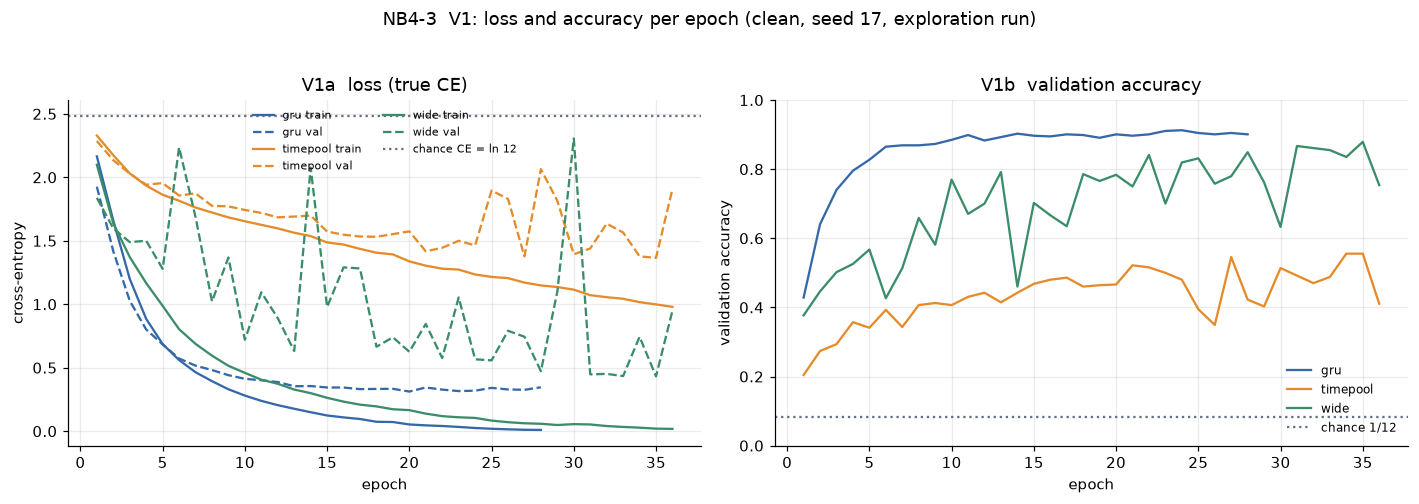

[N4.5.2] V1 drawn


In [19]:
# N4.5.2: V1 figure.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
for a in ARCHS:
    h = DATA[a]["res"]["history"]; ep = [r["epoch"] + 1 for r in h]
    ax[0].plot(ep, [r["train_loss"] for r in h], color=ACOL[a], label=f"{a} train")
    ax[0].plot(ep, [r["val_loss"] for r in h], color=ACOL[a], ls="--", label=f"{a} val")
    ax[1].plot(ep, [r["val_accuracy"] for r in h], color=ACOL[a], label=a)
ax[0].axhline(LN12, color="#667085", ls=":", label="chance CE = ln 12")
ax[0].set(xlabel="epoch", ylabel="cross-entropy", title="V1a  loss (true CE)")
ax[1].axhline(1 / 12, color="#667085", ls=":", label="chance 1/12")
ax[1].set(xlabel="epoch", ylabel="validation accuracy", ylim=(0, 1), title="V1b  validation accuracy")
ax[0].legend(frameon=False, fontsize=7, ncol=2); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-3  V1: loss and accuracy per epoch (clean, seed 17, exploration run)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-3_V1_training_curves.png")
print("[N4.5.2] V1 drawn")

### How to read this chart

**Data source:** the `history` list (per-epoch `train_loss`, `val_loss`, `val_accuracy`) in
`<ARTIFACT_ROOT>/metrics/arch-{gru,timepool,wide}.result.json`.

**Axes:** horizontal is epoch (1-based). Left panel: cross-entropy, solid = training loss, dashed = validation
loss, dotted grey = $\ln 12 \approx 2.4849$, the loss of a uniform guess over 12 classes. Right panel: validation
accuracy with chance $1/12$ dotted.

**Interpretation:** all three first-epoch training losses ($2.10$ to $2.33$) sit just below $\ln 12$, which is
what a network starting at chance and learning during its first epoch would produce; an accounting error (for
example a loss divided by the number of accumulation steps) would put the start far below $2.48$, so this is an
independent confirmation that the true-CE accounting is correct. The three validation traces then separate
sharply. `gru`'s validation loss falls smoothly to about $0.31$ and its accuracy plateaus near $0.9$. `wide`'s
validation loss is violently unstable, roughly $0.43$ up to $2.31$ within the run, even as its training loss
keeps falling. `timepool`'s validation loss stays high and noisy.

**Falsifier:** if the first-epoch losses had been near $0$ or far above $2.48$, the loss accounting would be
suspect. If `wide`'s validation loss were smooth it would contradict the instability claim; the printed
volatility of the last ten epochs (about $0.80$ for `wide` against $0.02$ for `gru`) is the quantitative test.

### 5.2 V2: AutoClip, gradient norm versus adaptive threshold

For every optimizer step $t$, the run stored the pre-clip gradient L2 norm $g_t$ and the AutoClip threshold
$\eta_c(t)$ applied at that step. Step $0$ has no history, so its threshold is infinite (no clipping). A step is
counted as **clipped** when $g_t > \eta_c(t)$ with $\eta_c(t)$ finite.

Because the threshold is the $10$th percentile of the history, $90\%$ of a stationary gradient distribution
would lie *above* it. A clip rate near $90\%$ therefore does not indicate pathological gradients by itself; it is
what the $p=10$ setting produces. What departs from $90\%$ carries information: a rate well below $90\%$ means the
recent gradients are smaller than the early history, and a rate near $100\%$ means they are larger.
The rates are recomputed from the arrays below, not hard-coded.

In [20]:
# N4.5.3: clip rates recomputed from the arrays; verify the threshold equals the 10th percentile of PRIOR history.
rows = []
for a in ARCHS:
    g, c = DATA[a]["npz"]["grad_norm"], DATA[a]["npz"]["clip_threshold"]
    finite = np.isfinite(c); bit = finite & (g > c)
    ref = np.array([np.percentile(g[:t], 10) if t > 0 else np.inf for t in range(len(g))])
    match = np.allclose(ref[finite], c[finite], rtol=1e-4, atol=1e-6)
    rows.append({"arch": a, "steps": len(g), "finite_threshold_steps": int(finite.sum()), "clipped": int(bit.sum()),
                 "clip_rate_of_all_steps": bit.sum() / len(g), "clip_rate_of_finite": bit.sum() / finite.sum(),
                 "threshold_first": c[finite][0], "threshold_last": c[finite][-1],
                 "grad_median_first100": np.median(g[:100]), "grad_median_last100": np.median(g[-100:]),
                 "matches_P10_of_prior_history": bool(match)})
CLIP = pd.DataFrame(rows).set_index("arch")
display(CLIP.round(4))
for a in ARCHS:
    check(f"N4.5.3[{a}.P10_prior_history]", CLIP.loc[a, "matches_P10_of_prior_history"], "stored threshold == np.percentile(grad_norm[:t], 10) for every step t>0")
    check(f"N4.5.3[{a}.step0_inf]", not np.isfinite(DATA[a]["npz"]["clip_threshold"][0]), "step-0 threshold is infinite (no history yet)")
check("N4.5.3[counts]", (CLIP["clipped"].to_dict() == {"gru": 663, "timepool": 1284, "wide": 910}), f"clipped counts {CLIP['clipped'].to_dict()} (expected: gru 663, timepool 1284, wide 910)")
check("N4.5.3[timepool_rate]", abs(CLIP.loc["timepool", "clip_rate_of_all_steps"] - 0.991) < 0.001, f"timepool clip rate {CLIP.loc['timepool', 'clip_rate_of_all_steps']:.4f}")

          steps  finite_threshold_steps  clipped  clip_rate_of_all_steps  clip_rate_of_finite  threshold_first  threshold_last  grad_median_first100  grad_median_last100  \
arch                                                                                                                                                                        
gru        1008                    1007      663                  0.6577               0.6584           1.8267          0.2005                0.8171               0.1317   
timepool   1296                    1295     1284                  0.9907               0.9915           1.2483          1.7124                1.0270               6.0385   
wide       1296                    1295      910                  0.7022               0.7027           2.3781          0.8111                2.2796               0.6553   

          matches_P10_of_prior_history  
arch                                    
gru                               True  
timepool   

[N4.5.3[gru.P10_prior_history]] stored threshold == np.percentile(grad_norm[:t], 10) for every step t>0 -> PASS
[N4.5.3[gru.step0_inf]] step-0 threshold is infinite (no history yet) -> PASS
[N4.5.3[timepool.P10_prior_history]] stored threshold == np.percentile(grad_norm[:t], 10) for every step t>0 -> PASS
[N4.5.3[timepool.step0_inf]] step-0 threshold is infinite (no history yet) -> PASS
[N4.5.3[wide.P10_prior_history]] stored threshold == np.percentile(grad_norm[:t], 10) for every step t>0 -> PASS
[N4.5.3[wide.step0_inf]] step-0 threshold is infinite (no history yet) -> PASS
[N4.5.3[counts]] clipped counts {'gru': 663, 'timepool': 1284, 'wide': 910} (expected: gru 663, timepool 1284, wide 910) -> PASS
[N4.5.3[timepool_rate]] timepool clip rate 0.9907 -> PASS


True

### Figure NB4-4: V2 gradient norm, AutoClip threshold, and clipped steps

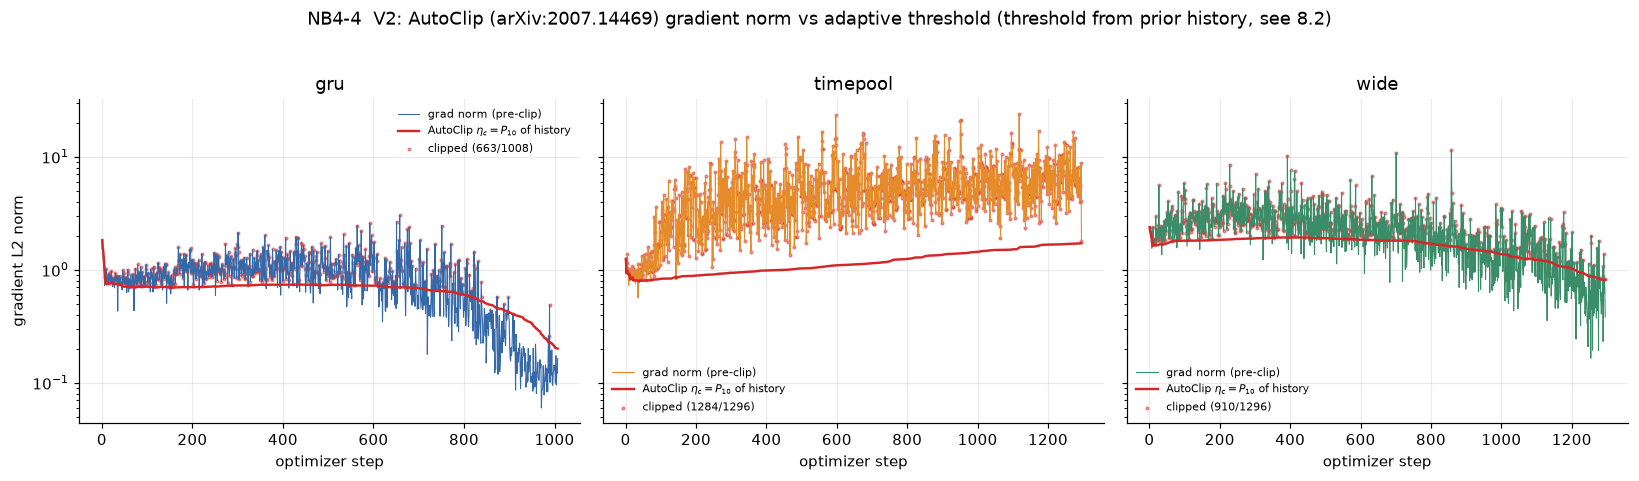

[N4.5.4] V2 drawn


In [21]:
# N4.5.4: V2 figure.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, a in zip(axes, ARCHS):
    g, c = DATA[a]["npz"]["grad_norm"], DATA[a]["npz"]["clip_threshold"]
    step = np.arange(len(g)); finite = np.isfinite(c); bit = finite & (g > c)
    ax.plot(step, g, lw=0.7, color=ACOL[a], label="grad norm (pre-clip)")
    ax.plot(step[finite], c[finite], lw=1.6, color="#d62728", label=r"AutoClip $\eta_c = P_{10}$ of history")
    ax.scatter(step[bit], g[bit], s=3, color="#d62728", alpha=0.45, label=f"clipped ({bit.sum()}/{len(g)})")
    ax.set(xlabel="optimizer step", yscale="log", title=a)
    ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel("gradient L2 norm")
fig.suptitle("NB4-4  V2: AutoClip (arXiv:2007.14469) gradient norm vs adaptive threshold (threshold from prior history, see 8.2)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-4_V2_autoclip.png")
print("[N4.5.4] V2 drawn")

### How to read this chart

**Data source:** `grad_norm` and `clip_threshold` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`; one entry per
optimizer step ($1008$ for `gru`, $1296$ for `timepool` and `wide`).

**Axes:** horizontal is the optimizer step; vertical is the gradient L2 norm on a log scale. The thin coloured line
is the pre-clip gradient norm, the red line the threshold $\eta_c(t)$, and red dots mark steps where the gradient
exceeded the threshold (clipping bit).

**Interpretation:** the threshold is not a ratchet that only decreases. It **tracks the gradient distribution**.
For `gru` and `wide`, whose gradients shrink as training converges (median of the last 100 steps well below the
first 100), the threshold falls with them, and the clip rate is $663/1008 = 65.8\%$ and $910/1296 = 70.2\%$, below
the $90\%$ that a stationary distribution would give. For `timepool` the gradient norm *grows* late in training
(median of the last 100 steps about six times the first 100), the threshold lags it, and the clip rate is
$1284/1296 = 99.1\%$: almost every step is clipped, which says the optimizer is running against a threshold set by
smaller, earlier gradients. That is a real pathology of the `timepool` run, not an artefact of the plot.

**Falsifier:** if the threshold were a one-way ratchet, the red line would be monotonically non-increasing; for
`timepool` it rises. If the stored threshold were not the $10$th percentile of prior history, the reconstruction
check above would fail; it passes for every step of every architecture.

### Figure NB4-5: clip rate per epoch and threshold tracking

A single global clip rate hides *when* clipping happened. The next figure bins the steps by epoch
($36$ steps per epoch for `gru`, $36$ for the others: the number of steps divided by the epochs run) and plots the
within-epoch clip rate, together with the ratio of the threshold to the running median of the gradient norm.

[N4.5.5[gru.steps_per_epoch]] 1008 steps = 28 epochs x 36 steps -> PASS
[N4.5.5[timepool.steps_per_epoch]] 1296 steps = 36 epochs x 36 steps -> PASS


[N4.5.5[wide.steps_per_epoch]] 1296 steps = 36 epochs x 36 steps -> PASS


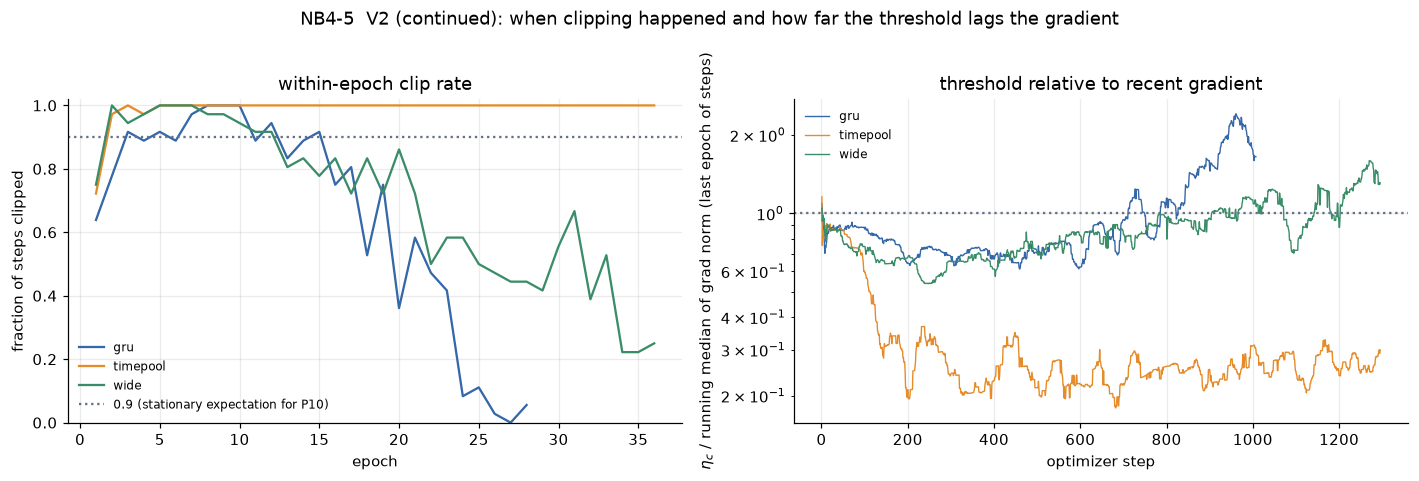

gru: mean within-epoch clip rate first 5 epochs 0.828, last 5 epochs 0.056
timepool: mean within-epoch clip rate first 5 epochs 0.933, last 5 epochs 1.000
wide: mean within-epoch clip rate first 5 epochs 0.933, last 5 epochs 0.322
[N4.5.5[timepool_late_rate]] timepool clips >95% of steps in its last 5 epochs -> PASS


True

In [22]:
# N4.5.5: per-epoch clip rate and threshold/median-gradient ratio.
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
per_epoch = {}
for a in ARCHS:
    g, c = DATA[a]["npz"]["grad_norm"], DATA[a]["npz"]["clip_threshold"]
    E = DATA[a]["res"]["epochs_run"]; spe = len(g) // E
    check(f"N4.5.5[{a}.steps_per_epoch]", spe * E == len(g), f"{len(g)} steps = {E} epochs x {spe} steps")
    bit = (np.isfinite(c) & (g > c)).astype(float)
    rate = bit[: spe * E].reshape(E, spe).mean(axis=1)
    per_epoch[a] = rate
    ax[0].plot(np.arange(1, E + 1), rate, color=ACOL[a], label=a)
    finite = np.isfinite(c)
    run_med = np.array([np.median(g[max(0, t - spe): t + 1]) for t in range(len(g))])
    ax[1].plot(np.arange(len(g))[finite], (c[finite] / run_med[finite]), color=ACOL[a], lw=0.9, label=a)
ax[0].axhline(0.9, color="#667085", ls=":", label="0.9 (stationary expectation for P10)")
ax[0].set(xlabel="epoch", ylabel="fraction of steps clipped", ylim=(0, 1.02), title="within-epoch clip rate")
ax[1].axhline(1.0, color="#667085", ls=":")
ax[1].set(xlabel="optimizer step", ylabel=r"$\eta_c$ / running median of grad norm (last epoch of steps)", yscale="log", title="threshold relative to recent gradient")
ax[0].legend(frameon=False, fontsize=8); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-5  V2 (continued): when clipping happened and how far the threshold lags the gradient", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-5_V2_clip_rate.png")
for a in ARCHS:
    print(f"{a}: mean within-epoch clip rate first 5 epochs {per_epoch[a][:5].mean():.3f}, last 5 epochs {per_epoch[a][-5:].mean():.3f}")
check("N4.5.5[timepool_late_rate]", per_epoch["timepool"][-5:].mean() > 0.95, "timepool clips >95% of steps in its last 5 epochs")

### How to read this chart

**Data source:** the same `grad_norm` and `clip_threshold` arrays as Figure NB4-4, reshaped into
(epochs $\times$ steps per epoch).

**Axes:** left, epoch versus the fraction of that epoch's steps that were clipped, with the $0.9$ level marked.
Right, optimizer step versus the ratio of the threshold to the running median of the most recent epoch's worth of
gradient norms, on a log scale; a ratio of $1$ means the threshold equals the recent typical gradient, values
below $1$ mean the threshold sits under the typical gradient (so most steps are clipped).

**Interpretation:** a healthy adaptive threshold keeps the ratio roughly stable. A ratio that falls steadily
below $1$ (`timepool`) is the signature of gradients that grow relative to history and are being clipped almost
every step. `gru` and `wide` show ratios that stay in a narrower band because their gradients decay with the
threshold following.

**Falsifier:** if the clip rate were near $0.9$ throughout for all three arms, the $P_{10}$ rule would be doing
nothing informative and the global counts above would be an artefact of the percentile choice alone. The
`timepool` late-epoch rate near $1.0$ and the lower `gru`/`wide` rates contradict that.

### 5.3 V3: SentryCam 2D latent scatter over epochs

After each epoch the probe set was passed through the model and the penultimate-layer vector for each of the 120
samples was projected to 2D. Panels below show that 2D scatter at eight roughly evenly spaced epochs plus the two
alert epochs (the raw-space alert, and the 2D alert, both from Section 5.5), coloured by true class.

**Deviation label:** the projection is **PCA**, not SentryCam's trained parametric autoencoder. Each epoch's PCA is
fitted separately, so axis orientation and sign are arbitrary from one panel to the next; only the *spacing* of the
clusters within a panel is meaningful. Axis limits are free per panel for the same reason.

{'gru': {'raw': 2, '2d': 17}, 'timepool': {'raw': 2, '2d': 2}, 'wide': {'raw': 2, '2d': 2}}


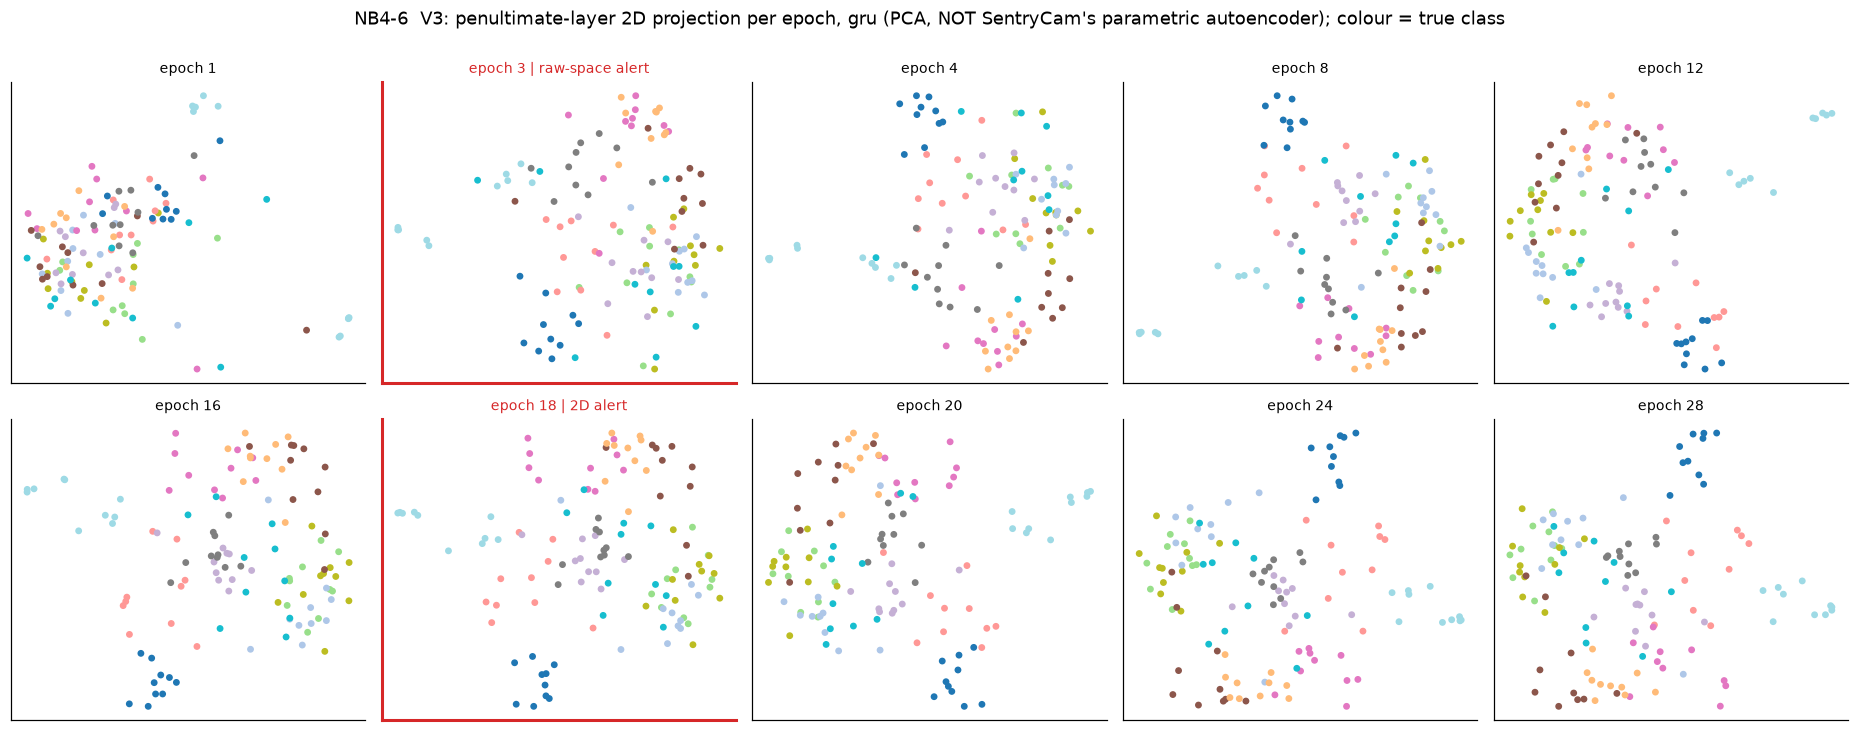

[N4.5.6] V3 gru panels at epochs (0-based) [0, 2, 3, 7, 11, 15, 17, 19, 23, 27]


In [23]:
# N4.5.6: helper: alert epochs from src.diagnostics on both raw and 2D series, then the V3 grid.
from src.diagnostics import sentrycam_alert_epoch, cluster_drift_metrics, project_2d

ALERT = {}
for a in ARCHS:
    n = DATA[a]["npz"]
    ALERT[a] = {"raw": sentrycam_alert_epoch(n["inter_raw"], n["intra_raw"]), "2d": sentrycam_alert_epoch(n["inter_2d"], n["intra_2d"])}
print({a: ALERT[a] for a in ARCHS})

def v3_grid(arch, fname, fig_no):
    co, lab = DATA[arch]["npz"]["coords_2d"], DATA[arch]["npz"]["labels"]
    E = co.shape[0]
    picks = sorted(set(np.linspace(0, E - 1, 8).astype(int).tolist() + [ALERT[arch]["raw"], ALERT[arch]["2d"]]))
    picks = [p for p in picks if p is not None]
    fig, axes = plt.subplots(2, 5, figsize=(17, 6.6))
    for ax in axes.ravel():
        ax.set_visible(False)
    for ax, e in zip(axes.ravel(), picks):
        ax.set_visible(True)
        ax.scatter(co[e, :, 0], co[e, :, 1], c=lab, cmap="tab20", s=12)
        tag = []
        if e == ALERT[arch]["raw"]: tag.append("raw-space alert")
        if e == ALERT[arch]["2d"]: tag.append("2D alert")
        ax.set_title(f"epoch {e + 1}" + (" | " + ", ".join(tag) if tag else ""), fontsize=9, color="#d62728" if tag else "black")
        ax.set_xticks([]); ax.set_yticks([])
        if tag:
            for sp in ax.spines.values():
                sp.set_edgecolor("#d62728"); sp.set_linewidth(2)
    fig.suptitle(f"NB4-{fig_no}  V3: penultimate-layer 2D projection per epoch, {arch} (PCA, NOT SentryCam's parametric autoencoder); colour = true class", y=1.0)
    fig.tight_layout()
    savefig(fig, fname)
    return picks

p_gru = v3_grid("gru", "NB4-6_V3_latent_gru.png", 6)
print("[N4.5.6] V3 gru panels at epochs (0-based)", p_gru)

### How to read this chart

**Data source:** `coords_2d` (shape $(E,120,2)$) and `labels` in `<ARTIFACT_ROOT>/metrics/arch-gru.probes.npz`.

**Axes:** each panel is one epoch; the two axes are the first two principal components of that epoch's
penultimate-layer activations (units arbitrary, orientation arbitrary between panels). Colour is the true class
of each of the 120 probe samples (12 classes, 10 points each). Red-framed panels mark alert epochs.

**Interpretation:** for the healthy `gru`, points that start as a diffuse cloud in the first panel condense into
compact, separated same-colour groups, and stay that way for the remaining epochs. Tighter same-colour groups and
larger gaps between groups are exactly what a rising inter-cluster distance and a falling intra-cluster variance
(Figure NB4-8) quantify.

**Falsifier:** if clusters were equally diffuse at the last epoch as at the first, the accuracy of about $0.9$
would be hard to explain by this projection, and the inter/intra curves would be flat. Note that two principal
components cannot show separation that lives in other directions, so a panel that looks mixed is weaker evidence
than a panel that looks separated.

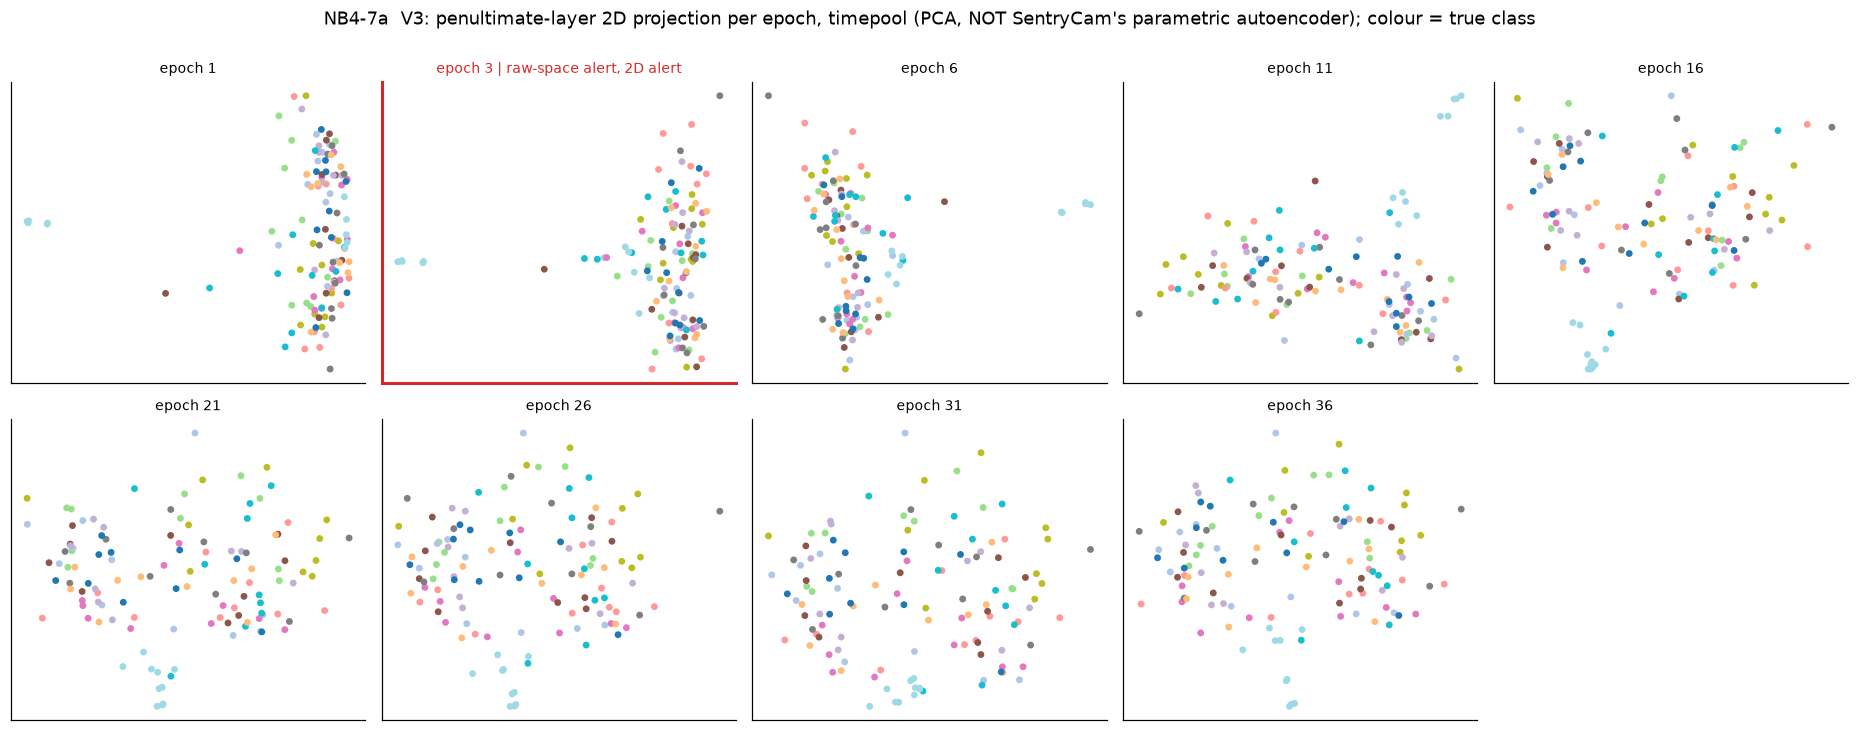

[N4.5.7] V3 timepool panels (0-based) [0, 2, 5, 10, 15, 20, 25, 30, 35]


In [24]:
# N4.5.7: V3 for timepool and wide (same helper).
p_tp = v3_grid("timepool", "NB4-7a_V3_latent_timepool.png", "7a")
print("[N4.5.7] V3 timepool panels (0-based)", p_tp)

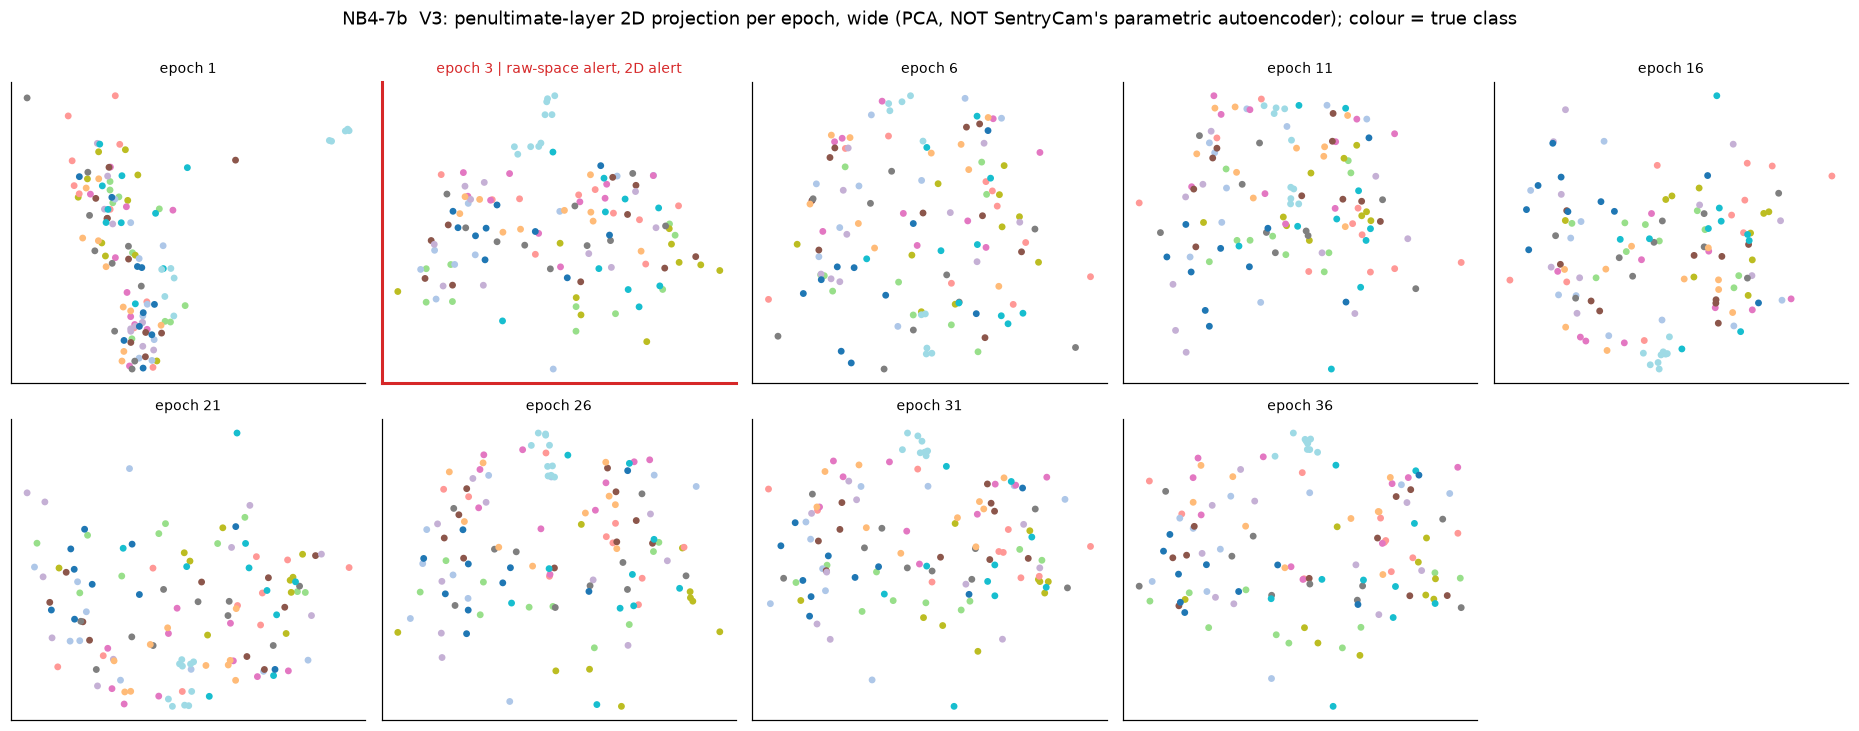

[N4.5.8] V3 wide panels (0-based) [0, 2, 5, 10, 15, 20, 25, 30, 35]


In [25]:
# N4.5.8: V3 wide.
p_wd = v3_grid("wide", "NB4-7b_V3_latent_wide.png", "7b")
print("[N4.5.8] V3 wide panels (0-based)", p_wd)

### How to read these two charts (`timepool`, then `wide`)

**Data source:** `coords_2d` and `labels` in `<ARTIFACT_ROOT>/metrics/arch-timepool.probes.npz` and
`arch-wide.probes.npz`; layout, colouring, and the PCA deviation label are identical to the `gru` figure.

**Axes:** as in the previous figure. Note that axis limits are free per panel, so the *absolute* spread of these
two architectures (their intra-cluster variance is an order of magnitude larger than `gru`'s) is visible in the
tick-free panels only through how much of the panel the clusters fill and how much they overlap.

**Interpretation:** neither architecture reaches the compact, separated clusters of `gru` by the end. `timepool`'s
same-class points remain spread and overlapping, consistent with its low accuracy. `wide` shows some class
structure but with large within-class dispersion that does not settle from epoch to epoch, consistent with its
oscillating validation loss.

**Falsifier:** if either architecture's last-epoch panel looked as tight as `gru`'s, the ranking by intra-cluster
variance in Figure NB4-8 would be contradicted. Qualitative panel impressions are secondary to the computed
metrics, which use all 120 points and all epochs.

### 5.4 V4: cluster health computed in 2D, with the significance band

For each epoch, the two SentryCam scalars are computed on the 2D coordinates:
inter-cluster distance $D_t$ (mean pairwise Euclidean distance between the 12 class centroids) and
intra-cluster variance $V_t$ (unweighted mean over classes of the mean squared distance to the class centroid).
Both are stored in the probe file as `inter_2d` and `intra_2d`, and the check cell below recomputes them from
`coords_2d` with `src.diagnostics.cluster_drift_metrics` to confirm the stored series.

The alert's significance margin is $\alpha\,\sigma_{10}(t)$ with $\alpha = 0.25$ and $\sigma_{10}(t)$ the standard
deviation of the previous (up to) 10 epochs. It is drawn as a band $x_t \pm \alpha\,\sigma_{10}(t)$ around each
series. **Deviation:** the 2D space is a PCA projection, not a parametric autoencoder.

In [26]:
# N4.5.9: recompute the 2D metrics from coords_2d and compare with the stored series.
for a in ARCHS:
    n = DATA[a]["npz"]
    re_inter, re_intra = zip(*[cluster_drift_metrics(n["coords_2d"][t], n["labels"]) for t in range(n["coords_2d"].shape[0])])
    check(f"N4.5.9[{a}.inter_2d]", np.allclose(re_inter, n["inter_2d"], rtol=1e-3, atol=1e-4), f"max abs diff {np.max(np.abs(np.array(re_inter) - n['inter_2d'])):.2e}")
    check(f"N4.5.9[{a}.intra_2d]", np.allclose(re_intra, n["intra_2d"], rtol=1e-3, atol=1e-4), f"max abs diff {np.max(np.abs(np.array(re_intra) - n['intra_2d'])):.2e}")

[N4.5.9[gru.inter_2d]] max abs diff 0.00e+00 -> PASS
[N4.5.9[gru.intra_2d]] max abs diff 0.00e+00 -> PASS
[N4.5.9[timepool.inter_2d]] max abs diff 0.00e+00 -> PASS
[N4.5.9[timepool.intra_2d]] max abs diff 0.00e+00 -> PASS
[N4.5.9[wide.inter_2d]] max abs diff 0.00e+00 -> PASS
[N4.5.9[wide.intra_2d]] max abs diff 0.00e+00 -> PASS


### Figure NB4-8: V4 cluster health in 2D

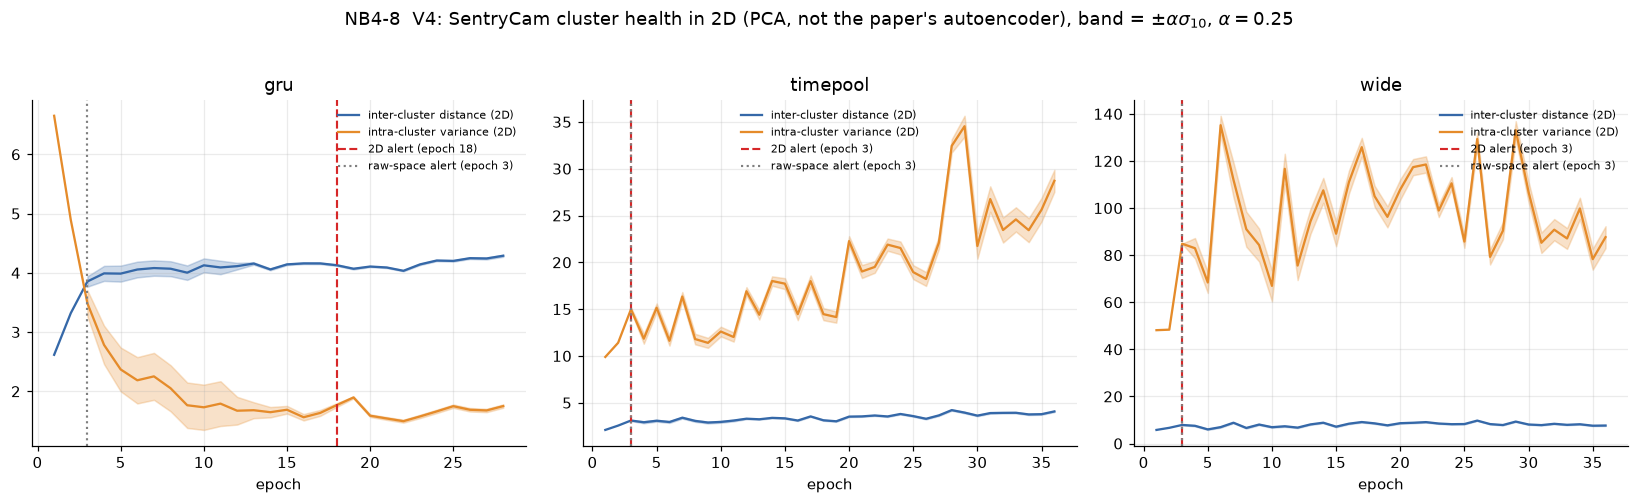

[N4.5.10] V4 drawn


In [27]:
# N4.5.10: V4 figure with rolling-sigma band and alert epochs.
ALPHA, WINDOW = 0.25, 10
def rolling_sigma(series, window=WINDOW):
    return np.array([np.std(series[max(0, t - window):t]) if t >= 2 else np.nan for t in range(len(series))])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
for ax, a in zip(axes, ARCHS):
    n = DATA[a]["npz"]; ep = np.arange(1, len(n["inter_2d"]) + 1)
    for series, col, lbl in ((n["inter_2d"], "#3568A8", "inter-cluster distance (2D)"), (n["intra_2d"], "#E58B2A", "intra-cluster variance (2D)")):
        ax.plot(ep, series, color=col, label=lbl)
        sg = rolling_sigma(series)
        ax.fill_between(ep, series - ALPHA * sg, series + ALPHA * sg, color=col, alpha=0.25)
    if ALERT[a]["2d"] is not None:
        ax.axvline(ALERT[a]["2d"] + 1, color="#d62728", ls="--", lw=1.4, label=f"2D alert (epoch {ALERT[a]['2d'] + 1})")
    if ALERT[a]["raw"] is not None:
        ax.axvline(ALERT[a]["raw"] + 1, color="#7f7f7f", ls=":", lw=1.4, label=f"raw-space alert (epoch {ALERT[a]['raw'] + 1})")
    ax.set(xlabel="epoch", title=a); ax.legend(frameon=False, fontsize=7)
fig.suptitle(r"NB4-8  V4: SentryCam cluster health in 2D (PCA, not the paper's autoencoder), band = $\pm\alpha\sigma_{10}$, $\alpha=0.25$", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-8_V4_cluster_health.png")
print("[N4.5.10] V4 drawn")

### How to read this chart

**Data source:** `inter_2d` and `intra_2d` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`; the alert epochs are computed
in the notebook by `src.diagnostics.sentrycam_alert_epoch` (raw-space alert from `inter_raw`/`intra_raw`).

**Axes:** horizontal is epoch (1-based); vertical is the metric value in 2D PCA units. Blue is inter-cluster
distance (larger = better separated), orange is intra-cluster variance (smaller = tighter). The shaded ribbon around
each line is the alert's significance margin $\pm\alpha\sigma_{10}$: a one-epoch change must exceed the ribbon's
half-width to count. Red dashed = 2D alert epoch; grey dotted = raw-space alert epoch.

**Interpretation:** `gru`'s blue line rises quickly from about $2.6$ to about $4.3$ and its orange line falls from
about $6.7$ to about $1.5$--$1.8$: separation up, dispersion down, then a plateau in which the ribbon is very
narrow. `timepool`'s orange line *rises* (roughly $10$ to $29$ at the end, peaking above $34$) while its blue line
also rises modestly, i.e. the classes drift apart and spread at the same time. `wide`'s orange line swings between
about $48$ and $135$ without settling.

**Falsifier:** a healthy run should not show a persistent rise in intra-cluster variance; `gru`'s does not.
Conversely, if `wide`'s intra-cluster variance were flat, its unstable validation loss would lack a matching
geometric signature. Epoch-by-epoch correlation between these metrics and validation loss is quantified in
Section 5.6 and is weaker than the visual impression for two of the three arms.

### 5.5 Headline: raw-space alert versus 2D alert

SentryCam's alert can be evaluated on two different series that the run recorded for every epoch:
the cluster metrics computed on the **raw penultimate activations** (`inter_raw`, `intra_raw`) and the same
metrics computed on the **2D projection** (`inter_2d`, `intra_2d`). The research file records that SentryCam
computes its metrics on a 2D *projected* latent space, "not raw activations". The reason for projecting first is
not written in that research file; it is stated in this project's own docstring of `project_2d`
(`src/diagnostics.py`) as the paper's motivation: raw high-dimensional distances are noise-dominated
(the curse of dimensionality). That is the project's gloss on the paper, not a verified quotation, and it is
treated here as a hypothesis the data can test: if it is right, the raw-space alert should be *less informative*
than the 2D one.

The cell below runs the identical `sentrycam_alert_epoch(k=2, alpha=0.25, window=10)` on both series for all
three architectures and separates the two internal conditions (distance-decrease and variance-increase) by feeding
the other series as a constant, which can never fire.

In [28]:
# N4.5.11: raw-vs-2D alert table, with each condition separated.
rows = []
for a in ARCHS:
    n = DATA[a]["npz"]; one = np.ones(len(n["inter_2d"]))
    for space in ("raw", "2d"):
        i, v = n[f"inter_{space}"], n[f"intra_{space}"]
        al = sentrycam_alert_epoch(i, v)
        rows.append({"arch": a, "space": space, "alert_idx0": al, "alert_epoch_1based": None if al is None else al + 1,
                     "distance_cond_idx0": sentrycam_alert_epoch(i, one), "variance_cond_idx0": sentrycam_alert_epoch(one, v),
                     "inter_first": float(i[0]), "inter_last": float(i[-1]), "intra_first": float(v[0]), "intra_last": float(v[-1]),
                     "intra_min": float(v.min()), "intra_max": float(v.max())})
ALERT_TABLE = pd.DataFrame(rows)
display(ALERT_TABLE.round(3))
wide_table = ALERT_TABLE.pivot(index="arch", columns="space", values="alert_idx0")
print("alert epoch, 0-based (raw vs 2D):")
display(wide_table)
check("N4.5.11[raw_all_same]", wide_table["raw"].nunique() == 1, f"raw-space alert epoch identical for all three archs: {wide_table['raw'].tolist()}")
check("N4.5.11[raw_gru_fires]", wide_table.loc["gru", "raw"] is not None and not np.isnan(wide_table.loc["gru", "raw"]), "raw-space alert fires on the healthy gru (uninformative)")
check("N4.5.11[matches_json]", all(DATA[a]["res"]["instability_alert_epoch"] == ALERT[a]["raw"] for a in ARCHS), "stored instability_alert_epoch equals the raw-space alert recomputed here")
check("N4.5.11[2d_differs]", wide_table["2d"].nunique() > 1, f"2D alert epochs differ across archs: {wide_table['2d'].tolist()}")
gru2, tp2, wd2 = (ALERT[a]["2d"] for a in ("gru", "timepool", "wide"))
note("N4.5.11[gru_2d_alert]", f"the 2D alert ALSO fires on the healthy gru, at 0-based epoch {gru2} (1-based {gru2 + 1}); it is late (plateau) versus epoch {tp2} for timepool and {wd2} for wide, but it is not silent")

       arch space  alert_idx0  alert_epoch_1based  distance_cond_idx0  variance_cond_idx0  inter_first  inter_last  intra_first  intra_last  intra_min  intra_max
0       gru   raw           2                   3                 NaN                   2        2.088      15.800        2.790      32.030      2.790     32.030
1       gru    2d          17                  18                17.0                  17        2.616       4.288        6.651       1.750      1.496      6.651
2  timepool   raw           2                   3                29.0                   2        0.931      10.379        1.181      42.931      1.181     44.575
3  timepool    2d           2                   3                 8.0                   2        2.097       4.073        9.892      28.708      9.892     34.536
4      wide   raw           2                   3                 NaN                   2        3.498      25.195        8.541     147.666      8.541    161.058
5      wide    2d           

alert epoch, 0-based (raw vs 2D):


space     2d  raw
arch             
gru       17    2
timepool   2    2
wide       2    2

[N4.5.11[raw_all_same]] raw-space alert epoch identical for all three archs: [2, 2, 2] -> PASS
[N4.5.11[raw_gru_fires]] raw-space alert fires on the healthy gru (uninformative) -> PASS
[N4.5.11[matches_json]] stored instability_alert_epoch equals the raw-space alert recomputed here -> PASS
[N4.5.11[2d_differs]] 2D alert epochs differ across archs: [17, 2, 2] -> PASS
[N4.5.11[gru_2d_alert]] the 2D alert ALSO fires on the healthy gru, at 0-based epoch 17 (1-based 18); it is late (plateau) versus epoch 2 for timepool and 2 for wide, but it is not silent -> NOTE


### Figure NB4-9: raw and 2D series, side by side

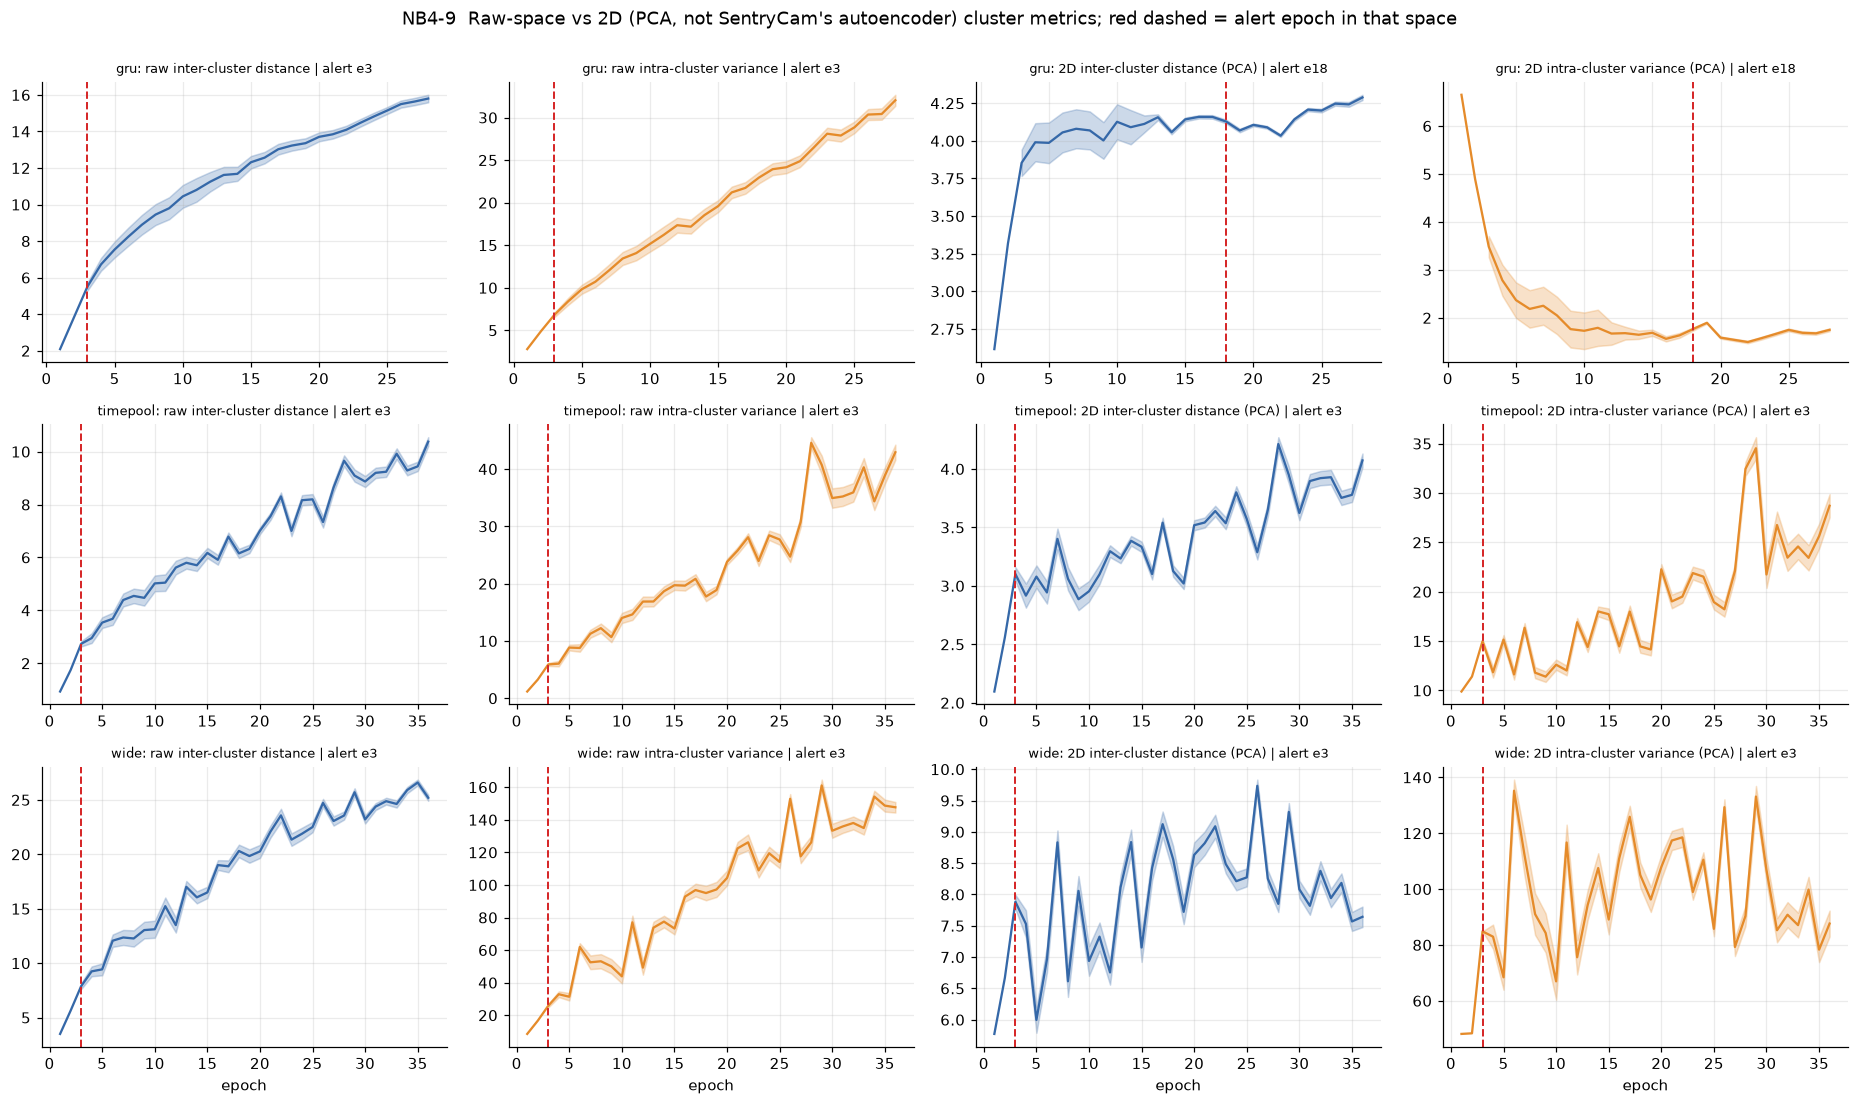

[N4.5.12] raw-vs-2D figure drawn


In [29]:
# N4.5.12: raw vs 2D series for all three archs, alert epochs marked.
fig, axes = plt.subplots(3, 4, figsize=(17, 10))
for r_i, a in enumerate(ARCHS):
    n = DATA[a]["npz"]; ep = np.arange(1, len(n["inter_2d"]) + 1)
    for c_i, (key, ttl, col) in enumerate((("inter_raw", "raw inter-cluster distance", "#3568A8"), ("intra_raw", "raw intra-cluster variance", "#E58B2A"),
                                           ("inter_2d", "2D inter-cluster distance (PCA)", "#3568A8"), ("intra_2d", "2D intra-cluster variance (PCA)", "#E58B2A"))):
        ax = axes[r_i, c_i]; s = n[key]
        ax.plot(ep, s, color=col); sg = rolling_sigma(s)
        ax.fill_between(ep, s - ALPHA * sg, s + ALPHA * sg, color=col, alpha=0.25)
        space = "raw" if key.endswith("raw") else "2d"
        if ALERT[a][space] is not None:
            ax.axvline(ALERT[a][space] + 1, color="#d62728", ls="--", lw=1.3)
        ax.set_title(f"{a}: {ttl}" + (f" | alert e{ALERT[a][space] + 1}" if ALERT[a][space] is not None else ""), fontsize=8.5)
        if r_i == 2: ax.set_xlabel("epoch")
fig.suptitle("NB4-9  Raw-space vs 2D (PCA, not SentryCam's autoencoder) cluster metrics; red dashed = alert epoch in that space", y=1.0)
fig.tight_layout()
savefig(fig, "NB4-9_raw_vs_2d.png")
print("[N4.5.12] raw-vs-2D figure drawn")

### How to read this chart

**Data source:** `inter_raw`, `intra_raw`, `inter_2d`, `intra_2d` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`; alert
epochs computed by `sentrycam_alert_epoch`.

**Axes:** rows are architectures; the left two columns are the raw-space metrics, the right two the 2D metrics.
Horizontal is epoch; vertical is the metric in its own units (the raw and 2D scales are not comparable). Ribbons
are $\pm\alpha\sigma_{10}$; the red dashed line is that column-pair's alert epoch.

**Interpretation:** in raw space every architecture, including the healthy `gru`, shows the same early pattern
(both metrics grow over the first epochs while the representation is still forming), so the alert fires at the
same early epoch, $2$ (0-based), for all three: it cannot tell a healthy run from an unhealthy one. In 2D the
*trajectories* discriminate: `gru`'s intra-cluster variance falls from about $6.7$ to about $1.5$--$1.8$ while its
inter-cluster distance rises from about $2.6$ to $4.3$; `timepool`'s intra-cluster variance rises from about
$9.9$ to $28.7$ at the end; `wide`'s oscillates between about $48$ and $135$. This ordering matches the stability
ordering in V1.

**What the numbers do not show, stated plainly:** the 2D *alert epoch* is not a clean discriminator. It fires at
0-based epoch $2$ for `timepool` and `wide` (early, as expected for unhealthy runs) but it also fires for the healthy
`gru`, late, at 0-based epoch $17$. Both conditions trigger there together, on the plateau where the rolling
$\sigma_{10}$ is small and a tiny wobble exceeds $\alpha\sigma_{10}$. The discrimination is in the *trajectories*
and in *when* the alert fires, not in *whether* it fires.

**Falsifier:** if the raw-space alert epochs differed across architectures and matched the 2D ones, the claim that
raw-space is uninformative would fail; they are identical. If `gru`'s 2D alert never fired, the "not silent"
caveat would be wrong; it fires.

### 5.6 Sensitivity and how well the geometry tracks validation behaviour

Two further checks temper the headline. First, the alert has a free choice of $k$ (consecutive epochs) and
$\alpha$ (margin multiplier); the paper's values are $k=2$, $\alpha=0.25$. The sweep shows how much the alert epoch
moves. Second, the Spearman rank correlation, across epochs, between each 2D metric and the validation loss or
accuracy tells whether the geometric signal follows the behaviour it is supposed to foreshadow.
Both are computed from the same files.

In [30]:
# N4.5.13: alert sensitivity to (alpha, k) for the 2D series.
srows = []
for a in ARCHS:
    n = DATA[a]["npz"]
    for alpha in (0.1, 0.25, 0.5, 1.0):
        for k in (2, 3):
            srows.append({"arch": a, "alpha": alpha, "k": k, "alert_2d_idx0": sentrycam_alert_epoch(n["inter_2d"], n["intra_2d"], alpha=alpha, k=k),
                          "alert_raw_idx0": sentrycam_alert_epoch(n["inter_raw"], n["intra_raw"], alpha=alpha, k=k)})
SENS = pd.DataFrame(srows)
display(SENS.pivot_table(index=["alpha", "k"], columns="arch", values=["alert_2d_idx0", "alert_raw_idx0"], aggfunc="first"))
check("N4.5.13[paper_setting]", (SENS[(SENS.alpha == 0.25) & (SENS.k == 2)].set_index("arch")["alert_2d_idx0"].to_dict() == {a: ALERT[a]["2d"] for a in ARCHS}), "sweep at the paper setting reproduces the headline 2D alerts")
n_none = int(SENS["alert_2d_idx0"].isna().sum())
note("N4.5.13", f"{n_none} of {len(SENS)} (arch, alpha, k) cells never fire in 2D; the alert epoch is sensitive to k and alpha, so it should not be over-read")

        alert_2d_idx0               alert_raw_idx0              
arch              gru timepool wide            gru timepool wide
alpha k                                                         
0.10  2           8.0      2.0  2.0            2.0      2.0  2.0
      3          18.0     28.0  NaN            3.0      4.0  3.0
0.25  2          17.0      2.0  2.0            2.0      2.0  2.0
      3          18.0     28.0  NaN            3.0      4.0  3.0
0.50  2          17.0      2.0  2.0            2.0      2.0  2.0
      3          18.0      NaN  NaN            3.0      4.0  3.0
1.00  2          17.0      2.0  2.0            2.0      2.0  2.0
      3          18.0      NaN  NaN            NaN      4.0  3.0

[N4.5.13[paper_setting]] sweep at the paper setting reproduces the headline 2D alerts -> PASS
[N4.5.13] 6 of 24 (arch, alpha, k) cells never fire in 2D; the alert epoch is sensitive to k and alpha, so it should not be over-read -> NOTE


In [31]:
# N4.5.14: Spearman correlation across epochs between 2D geometry and validation behaviour.
crow = []
for a in ARCHS:
    n = DATA[a]["npz"]; h = DATA[a]["res"]["history"]
    vl = np.array([r["val_loss"] for r in h]); va = np.array([r["val_accuracy"] for r in h])
    row = {"arch": a}
    for name, s in (("inter_2d", n["inter_2d"]), ("intra_2d", n["intra_2d"]), ("inter_raw", n["inter_raw"]), ("intra_raw", n["intra_raw"])):
        row[f"{name}~val_loss"] = spearmanr(s, vl)[0]; row[f"{name}~val_acc"] = spearmanr(s, va)[0]
    crow.append(row)
CORR = pd.DataFrame(crow).set_index("arch")
display(CORR.round(3))
check("N4.5.14[gru_intra_tracks_loss]", CORR.loc["gru", "intra_2d~val_loss"] > 0.5, f"gru: rho(intra_2d, val_loss)={CORR.loc['gru', 'intra_2d~val_loss']:.3f}")
note("N4.5.14[weak_for_others]", f"timepool rho(intra_2d, val_loss)={CORR.loc['timepool', 'intra_2d~val_loss']:.3f}; wide {CORR.loc['wide', 'intra_2d~val_loss']:.3f}: the geometry does not track epoch-level validation loss for the two unstable arms")

          inter_2d~val_loss  inter_2d~val_acc  intra_2d~val_loss  intra_2d~val_acc  inter_raw~val_loss  inter_raw~val_acc  intra_raw~val_loss  intra_raw~val_acc
arch                                                                                                                                                            
gru                  -0.702             0.746              0.796            -0.750              -0.900              0.902              -0.900              0.900
timepool             -0.427             0.570             -0.417             0.556              -0.537              0.672              -0.506              0.643
wide                 -0.131             0.252              0.099             0.017              -0.644              0.795              -0.559              0.718

[N4.5.14[gru_intra_tracks_loss]] gru: rho(intra_2d, val_loss)=0.796 -> PASS
[N4.5.14[weak_for_others]] timepool rho(intra_2d, val_loss)=-0.417; wide 0.099: the geometry does not track epoch-level validation loss for the two unstable arms -> NOTE


**Reading the two tables.** The sweep shows the 2D alert epoch for `timepool` and `wide` is $2$ across almost the
whole grid (robustly early), whereas for `gru` it ranges from $8$ to $18$ and is absent for none of the 2D cells
at $k=2$. The alert is therefore best read as a coarse timing signal. The correlation table is a warning against
over-claiming: for `gru`, intra-cluster variance and validation loss rise and fall together (a strongly positive
Spearman coefficient), which supports the reading that tight clusters accompany low loss; for `timepool` the sign is
even negative and for `wide` it is near zero, so for the unstable arms the geometry differs from the validation
loss at the epoch level even though its overall *level* (variance about ten times larger) separates them from
`gru`. Ten points per class is a small probe set, and single-run rank correlations over $28$--$36$ epochs carry
wide uncertainty; none of this is a significance test.

### 5.7 Further in-training analyses

The remaining cells use the same recorded arrays to test the main story from angles the headline figures do not
cover: the *distribution* of gradient norms rather than only their threshold, the geometry *per class* rather than
averaged over classes, a classification-style score computed inside the 2D projection, and how far the alert epochs
sit from the epoch the saved model actually comes from. Everything is descriptive and single-run.

[N4.5.15[gru.finite]] all 1008 gradient norms finite -> PASS
[N4.5.15[timepool.finite]] all 1296 gradient norms finite -> PASS
[N4.5.15[wide.finite]] all 1296 gradient norms finite -> PASS


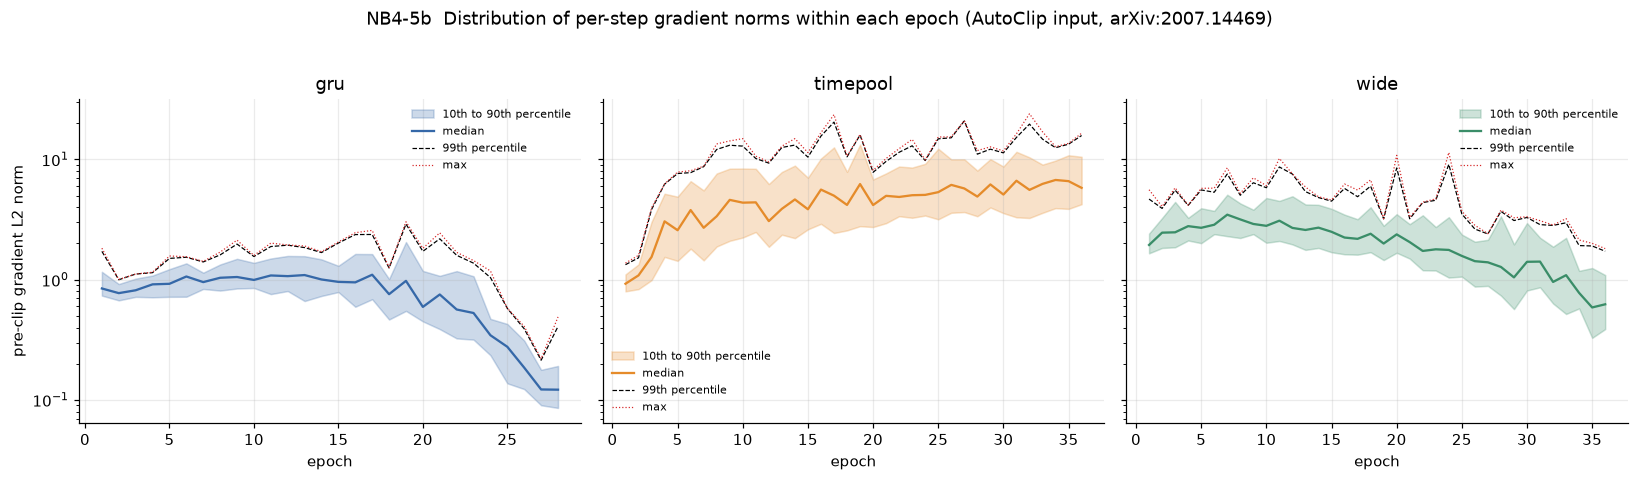

          median ep1  median last  max/median (whole run)  p99/p50 mean over epochs
gru            0.845        0.122                   3.571                     2.047
timepool       0.925        5.801                   5.240                     2.551
wide           1.943        0.624                   5.424                     2.373

[N4.5.15[timepool_grows]] timepool's median gradient norm at least doubles from the first to the last epoch -> PASS
[N4.5.15[gru_shrinks]] gru's median gradient norm at least halves from the first to the last epoch -> PASS


True

In [32]:
# N4.5.15: per-epoch quantiles of the pre-clip gradient norm.
QS = (10, 50, 90, 99)
GQ = {}
for a in ARCHS:
    g = DATA[a]["npz"]["grad_norm"]; E = DATA[a]["res"]["epochs_run"]; spe = len(g) // E
    per = g[: E * spe].reshape(E, spe)
    GQ[a] = {q: np.percentile(per, q, axis=1) for q in QS}
    GQ[a]["max"] = per.max(axis=1); GQ[a]["spe"] = spe
    check(f"N4.5.15[{a}.finite]", np.isfinite(per).all(), f"all {per.size} gradient norms finite")
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, a in zip(axes, ARCHS):
    ep = np.arange(1, DATA[a]["res"]["epochs_run"] + 1)
    ax.fill_between(ep, GQ[a][10], GQ[a][90], color=ACOL[a], alpha=0.25, label="10th to 90th percentile")
    ax.plot(ep, GQ[a][50], color=ACOL[a], label="median")
    ax.plot(ep, GQ[a][99], color="black", lw=0.8, ls="--", label="99th percentile")
    ax.plot(ep, GQ[a]["max"], color="#d62728", lw=0.8, ls=":", label="max")
    ax.set(xlabel="epoch", yscale="log", title=a); ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel("pre-clip gradient L2 norm")
fig.suptitle("NB4-5b  Distribution of per-step gradient norms within each epoch (AutoClip input, arXiv:2007.14469)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-5b_grad_quantiles.png")
tail = pd.DataFrame({a: {"median ep1": GQ[a][50][0], "median last": GQ[a][50][-1], "max/median (whole run)": DATA[a]["npz"]["grad_norm"].max() / np.median(DATA[a]["npz"]["grad_norm"]),
                         "p99/p50 mean over epochs": float(np.mean(GQ[a][99] / GQ[a][50]))} for a in ARCHS}).T
display(tail.round(3))
check("N4.5.15[timepool_grows]", GQ["timepool"][50][-1] > 2 * GQ["timepool"][50][0], "timepool's median gradient norm at least doubles from the first to the last epoch")
check("N4.5.15[gru_shrinks]", GQ["gru"][50][-1] < 0.5 * GQ["gru"][50][0], "gru's median gradient norm at least halves from the first to the last epoch")

### How to read this chart

**Data source:** `grad_norm` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`, reshaped to (epochs $\times$ steps per
epoch).

**Axes:** horizontal is epoch; vertical is the gradient L2 norm on a log scale. The band is the $10$th to $90$th
percentile of that epoch's step norms, the solid line the median, the dashed line the $99$th percentile, the dotted
line the maximum.

**Interpretation:** this figure shows the distribution the AutoClip percentile is applied to. For `gru` the whole
band drifts down by roughly an order of magnitude as training converges, so a cumulative $P_{10}$ threshold that
remembers early large gradients ends up *above* recent typical gradients, which is why fewer late steps are
clipped. For `timepool` the band drifts *up*, so the cumulative $P_{10}$ is left far below the recent gradients and
nearly all steps are clipped. Spikes in the maximum line without any change in the median are isolated large
gradients, which AutoClip is meant to catch.

**Falsifier:** if the medians were constant across epochs for all three architectures, the differences in clip
rate would have to come from tail behaviour alone; the printed median ratios show they come from a shift of the
bulk.

[N4.5.16[gru.mean_matches_intra_2d]] mean over the 12 per-class variances equals the stored intra_2d series -> PASS
[N4.5.16[timepool.mean_matches_intra_2d]] mean over the 12 per-class variances equals the stored intra_2d series -> PASS
[N4.5.16[wide.mean_matches_intra_2d]] mean over the 12 per-class variances equals the stored intra_2d series -> PASS


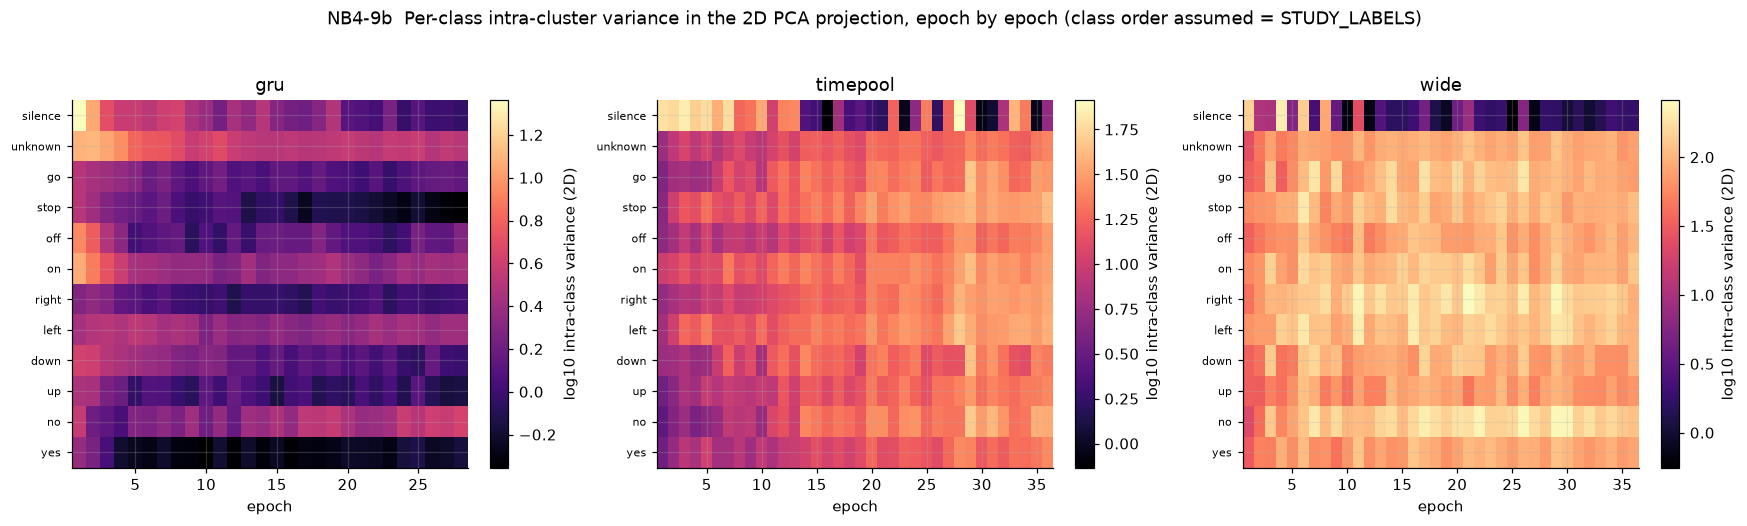

          gru   timepool        wide
yes      0.69  25.799999   82.620003
no       4.30  35.520000  120.080002
up       0.72  24.889999   68.800003
down     0.96  22.340000   97.419998
left     2.56  36.610001   98.279999
right    1.04  35.060001   91.800003
on       2.77  32.709999  125.449997
off      1.96  30.450001  100.419998
stop     0.44  42.259998  113.970001
go       1.39  29.260000   74.150002
unknown  3.25  24.420000   77.080002
silence  0.90   5.170000    1.710000

hardest class (largest final intra variance): {'gru': 'no', 'timepool': 'stop', 'wide': 'on'}


In [33]:
# N4.5.16: per-class 2D geometry. Labels are integer indices; we ASSUME index i corresponds to STUDY_LABELS[i] (src/dataset.py).
from src.dataset import STUDY_LABELS
CLASSES = list(STUDY_LABELS)

def per_class_intra(coords, labels):
    return np.array([np.mean(np.sum((coords[labels == k] - coords[labels == k].mean(axis=0)) ** 2, axis=1)) for k in range(12)])

def centroid_matrix(coords, labels):
    cen = np.stack([coords[labels == k].mean(axis=0) for k in range(12)])
    return np.linalg.norm(cen[:, None, :] - cen[None, :, :], axis=-1)

PCI = {}
for a in ARCHS:
    co, lab = DATA[a]["npz"]["coords_2d"], DATA[a]["npz"]["labels"]
    PCI[a] = np.stack([per_class_intra(co[t], lab) for t in range(co.shape[0])])   # (E, 12)
    check(f"N4.5.16[{a}.mean_matches_intra_2d]", np.allclose(PCI[a].mean(axis=1), DATA[a]["npz"]["intra_2d"], rtol=1e-3, atol=1e-4),
          "mean over the 12 per-class variances equals the stored intra_2d series")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, a in zip(axes, ARCHS):
    im = ax.imshow(np.log10(PCI[a].T), aspect="auto", origin="lower", cmap="magma", extent=[0.5, PCI[a].shape[0] + 0.5, -0.5, 11.5])
    ax.set_yticks(range(12)); ax.set_yticklabels(CLASSES, fontsize=7); ax.set(xlabel="epoch", title=a)
    fig.colorbar(im, ax=ax, fraction=0.046, label="log10 intra-class variance (2D)")
fig.suptitle("NB4-9b  Per-class intra-cluster variance in the 2D PCA projection, epoch by epoch (class order assumed = STUDY_LABELS)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-9b_per_class_variance.png")
last = pd.DataFrame({a: PCI[a][-1] for a in ARCHS}, index=CLASSES)
display(last.round(2))
print("hardest class (largest final intra variance):", {a: CLASSES[int(np.argmax(PCI[a][-1]))] for a in ARCHS})

### How to read this chart

**Data source:** `coords_2d` and `labels` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`. The label-to-word mapping
assumes label $i$ is `STUDY_LABELS[i]` from `src/dataset.py`; the probe file itself stores only integers, so the
word names are an assumption and are stated as one.

**Axes:** horizontal is epoch; vertical is class (12 rows); colour is $\log_{10}$ of that class's intra-cluster
variance in the 2D projection (its ten points' mean squared distance to their centroid). Averaging the twelve
rows of one column reproduces the `intra_2d` series (checked above).

**Interpretation:** for `gru` every row darkens together within the first few epochs: all classes tighten, none is
left behind. For `timepool` and `wide` the rows stay bright and differ from one another, so the aggregate
`intra_2d` of Figure NB4-8 is not driven by one outlier class. Rows that stay brighter than their neighbours in
the final epoch (the table) name the classes whose points remain most dispersed.

**Falsifier:** if a single row accounted for nearly all of `wide`'s intra-cluster variance, the aggregate
instability would be a one-class effect; the rows are comparable in brightness.

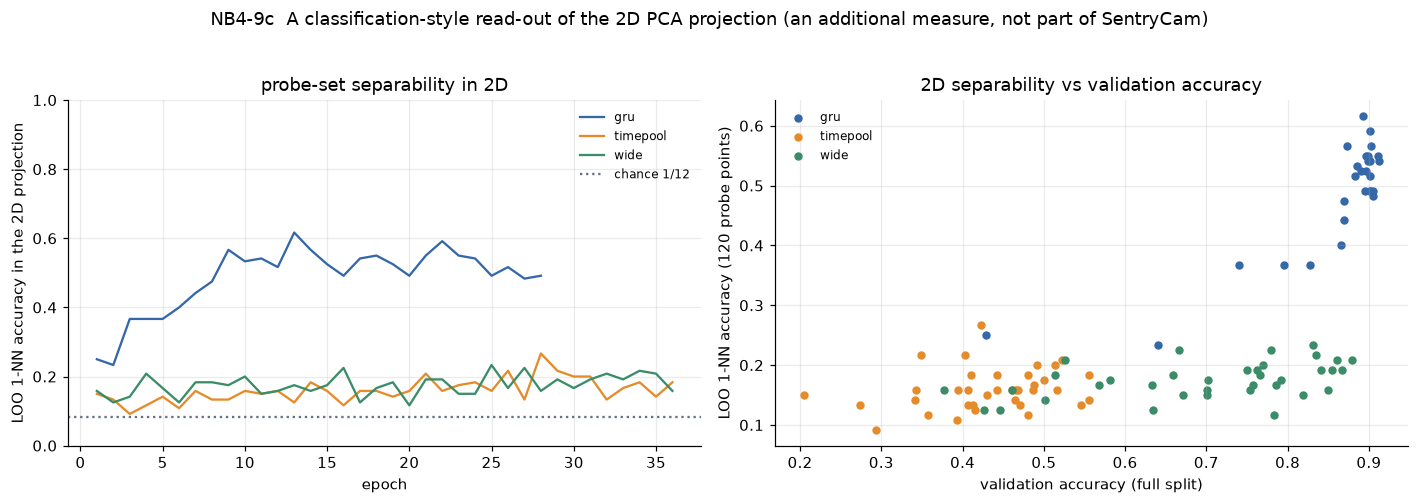

          1NN_first  1NN_last  1NN_max  spearman(1NN, val_acc)
arch                                                          
gru           0.250     0.492    0.617                   0.586
timepool      0.150     0.183    0.267                   0.297
wide          0.158     0.158    0.233                   0.465

[N4.5.17[gru_ends_high]] gru's final 2D 1-NN accuracy 0.492 exceeds 0.6 -> FAIL
[N4.5.17[order]] gru's final 2D 1-NN accuracy exceeds timepool's -> PASS
[N4.5.17[gru.above_chance]] gru: final 1-NN 0.492 above chance -> PASS
[N4.5.17[timepool.above_chance]] timepool: final 1-NN 0.183 above chance -> PASS
[N4.5.17[wide.above_chance]] wide: final 1-NN 0.158 above chance -> PASS


In [34]:
# N4.5.17: leave-one-out 1-nearest-neighbour accuracy INSIDE the 2D projection, per epoch, and its relation to validation accuracy.
def loo_1nn(coords, labels):
    d = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=-1)
    np.fill_diagonal(d, np.inf)
    return float(np.mean(labels[d.argmin(axis=1)] == labels))

NN1 = {}
for a in ARCHS:
    co, lab = DATA[a]["npz"]["coords_2d"], DATA[a]["npz"]["labels"]
    NN1[a] = np.array([loo_1nn(co[t], lab) for t in range(co.shape[0])])
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
rows = []
for a in ARCHS:
    va = np.array([r["val_accuracy"] for r in DATA[a]["res"]["history"]])
    ax[0].plot(np.arange(1, len(NN1[a]) + 1), NN1[a], color=ACOL[a], label=a)
    ax[1].scatter(va, NN1[a], color=ACOL[a], s=20, label=a)
    rows.append({"arch": a, "1NN_first": NN1[a][0], "1NN_last": NN1[a][-1], "1NN_max": NN1[a].max(), "spearman(1NN, val_acc)": spearmanr(NN1[a], va)[0]})
ax[0].axhline(1 / 12, color="#667085", ls=":", label="chance 1/12")
ax[0].set(xlabel="epoch", ylabel="LOO 1-NN accuracy in the 2D projection", ylim=(0, 1), title="probe-set separability in 2D")
ax[1].set(xlabel="validation accuracy (full split)", ylabel="LOO 1-NN accuracy (120 probe points)", title="2D separability vs validation accuracy")
ax[0].legend(frameon=False, fontsize=8); ax[1].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-9c  A classification-style read-out of the 2D PCA projection (an additional measure, not part of SentryCam)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-9c_1nn.png")
NND = pd.DataFrame(rows).set_index("arch")
display(NND.round(3))
check("N4.5.17[gru_ends_high]", NN1["gru"][-1] > 0.6, f"gru's final 2D 1-NN accuracy {NN1['gru'][-1]:.3f} exceeds 0.6")
check("N4.5.17[order]", NN1["gru"][-1] > NN1["timepool"][-1], "gru's final 2D 1-NN accuracy exceeds timepool's")
for a in ARCHS:
    check(f"N4.5.17[{a}.above_chance]", NN1[a][-1] > 1 / 12, f"{a}: final 1-NN {NN1[a][-1]:.3f} above chance")

### How to read this chart

**Data source:** `coords_2d` and `labels` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz` (120 points per epoch);
`history/val_accuracy` in the result files for the right panel. This is an *additional* measure computed in the
notebook, not something SentryCam defines.

**Axes:** left, epoch versus the fraction of probe points whose nearest neighbour (leave-one-out, Euclidean, in the
2D projection) has the same class; the dotted line is chance. Right, the same score against the full validation
accuracy of that epoch.

**Interpretation:** the 2D PCA discards all but two directions, so this score is a lower bound on how separable
the penultimate representation is. Even so, `gru`'s value climbs well above chance, `timepool`'s stays low, and the
ordering agrees with validation accuracy; the rank correlation in the table says how closely a single 120-point
projection tracks the real validation accuracy epoch by epoch.

**Falsifier:** if the 1-NN score in 2D were unrelated to validation accuracy for `gru` (rank correlation near
zero), the 2D geometry would not be a useful health signal and Section 5's alert reading would be weakened.

[N4.5.18[gru.rowsum]] every class has its 10 probe points in the confusion matrix -> PASS
[N4.5.18[timepool.rowsum]] every class has its 10 probe points in the confusion matrix -> PASS
[N4.5.18[wide.rowsum]] every class has its 10 probe points in the confusion matrix -> PASS


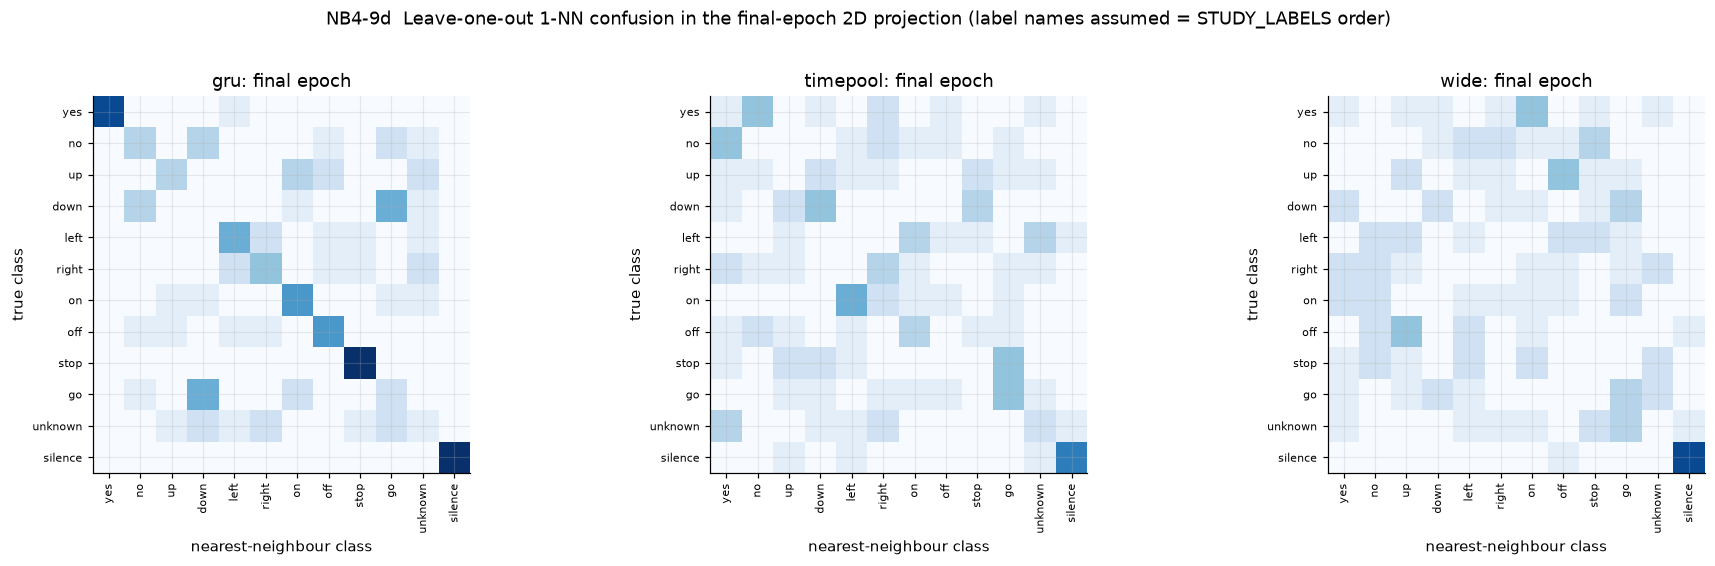

most common off-diagonal confusion (true, predicted, count): {'gru': ('down', 'go', 5), 'timepool': ('on', 'left', 5), 'wide': ('yes', 'on', 4)}


In [35]:
# N4.5.18: final-epoch confusion of the 2D 1-NN classifier (which classes are geometrically confused).
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
conf_top = {}
for ax, a in zip(axes, ARCHS):
    co, lab = DATA[a]["npz"]["coords_2d"][-1], DATA[a]["npz"]["labels"]
    d = np.linalg.norm(co[:, None, :] - co[None, :, :], axis=-1); np.fill_diagonal(d, np.inf)
    pred = lab[d.argmin(axis=1)]
    cm = np.zeros((12, 12), dtype=int)
    for t_, p_ in zip(lab, pred):
        cm[t_, p_] += 1
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=10)
    ax.set_xticks(range(12)); ax.set_yticks(range(12)); ax.set_xticklabels(CLASSES, rotation=90, fontsize=7); ax.set_yticklabels(CLASSES, fontsize=7)
    ax.set(xlabel="nearest-neighbour class", ylabel="true class", title=f"{a}: final epoch")
    off = cm.copy(); np.fill_diagonal(off, 0)
    i, j = np.unravel_index(off.argmax(), off.shape)
    conf_top[a] = (CLASSES[i], CLASSES[j], int(off[i, j]))
    check(f"N4.5.18[{a}.rowsum]", (cm.sum(axis=1) == 10).all(), "every class has its 10 probe points in the confusion matrix")
fig.suptitle("NB4-9d  Leave-one-out 1-NN confusion in the final-epoch 2D projection (label names assumed = STUDY_LABELS order)", y=1.02)
fig.tight_layout()
savefig(fig, "NB4-9d_1nn_confusion.png")
print("most common off-diagonal confusion (true, predicted, count):", conf_top)

### How to read this chart

**Data source:** final-epoch `coords_2d` and `labels` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`; word names
assume label $i$ is `STUDY_LABELS[i]`.

**Axes:** rows are the true class of a probe point, columns the class of its nearest neighbour in the 2D
projection; each row sums to $10$. A dark diagonal means same-class points sit next to each other.

**Interpretation:** `gru` has a strong diagonal with a few isolated confusions; `timepool` and `wide` have
weaker diagonals and more spread-out off-diagonal mass. The project's known confusable word pairs (for example
`no`/`on`, `go`/`no`, `up`/`off` in the `LogMelCNN` docstring) can be looked for among the off-diagonal cells, but
with ten points per class a single cell of two or three is not evidence of a systematic confusion.

**Falsifier:** off-diagonal mass concentrated in the documented confusable pairs for the weaker models but not for
`gru` would support the temporal-order story; the printed most frequent confusions are reported without further
interpretation.

[N4.5.19[gru.symmetric]] centroid distance matrix is symmetric with zero diagonal -> PASS
[N4.5.19[timepool.symmetric]] centroid distance matrix is symmetric with zero diagonal -> PASS
[N4.5.19[wide.symmetric]] centroid distance matrix is symmetric with zero diagonal -> PASS


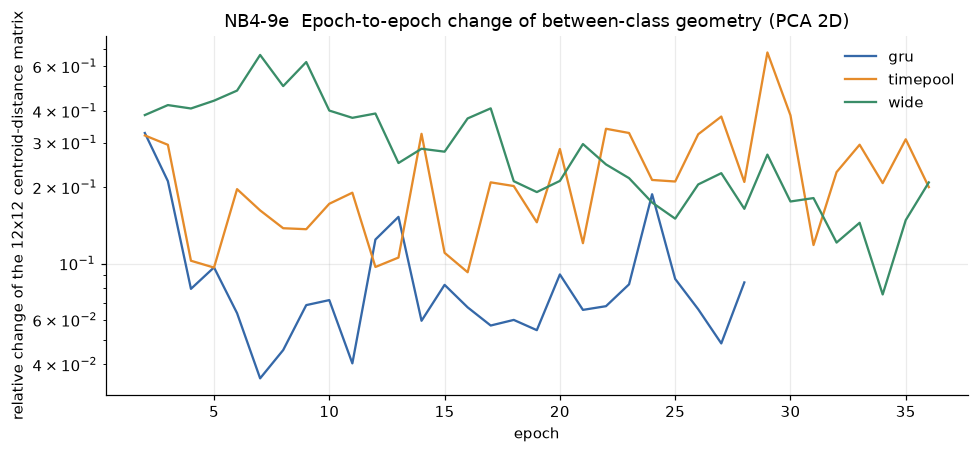

          mean change ep2-10  mean change last 10
gru                    0.111                0.083
timepool               0.180                0.301
wide                   0.481                0.172

[N4.5.19[gru_settles]] gru's geometry changes less in the last 10 epochs than in the first 9 -> PASS


True

In [36]:
# N4.5.19: how much the between-class geometry changes epoch to epoch (rotation-invariant: uses centroid distance matrices).
CH = {}
for a in ARCHS:
    co, lab = DATA[a]["npz"]["coords_2d"], DATA[a]["npz"]["labels"]
    Ds = [centroid_matrix(co[t], lab) for t in range(co.shape[0])]
    CH[a] = np.array([np.linalg.norm(Ds[t] - Ds[t - 1]) / max(np.linalg.norm(Ds[t - 1]), 1e-12) for t in range(1, len(Ds))])
    check(f"N4.5.19[{a}.symmetric]", np.allclose(Ds[-1], Ds[-1].T) and np.allclose(np.diag(Ds[-1]), 0), "centroid distance matrix is symmetric with zero diagonal")
fig, ax = plt.subplots(figsize=(9, 4.2))
for a in ARCHS:
    ax.plot(np.arange(2, len(CH[a]) + 2), CH[a], color=ACOL[a], label=a)
ax.set(xlabel="epoch", ylabel="relative change of the 12x12 centroid-distance matrix", yscale="log", title="NB4-9e  Epoch-to-epoch change of between-class geometry (PCA 2D)")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "NB4-9e_geometry_change.png")
display(pd.DataFrame({a: {"mean change ep2-10": CH[a][:9].mean(), "mean change last 10": CH[a][-10:].mean()} for a in ARCHS}).T.round(3))
check("N4.5.19[gru_settles]", CH["gru"][-10:].mean() < CH["gru"][:9].mean(), "gru's geometry changes less in the last 10 epochs than in the first 9")

### How to read this chart

**Data source:** `coords_2d` and `labels` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`.

**Axes:** horizontal is epoch $t$; vertical is $\lVert D_t - D_{t-1}\rVert_F / \lVert D_{t-1}\rVert_F$ on a log
scale, where $D_t$ is the $12\times12$ matrix of distances between class centroids in the 2D projection at epoch
$t$. Distances, unlike coordinates, do not depend on the arbitrary rotation or sign of each epoch's PCA, so the
quantity is comparable across epochs even though the axes are not.

**Interpretation:** a healthy run should settle (the curve falls and stays low); a run whose class geometry keeps
being reorganised stays high. This is the same message as the significance band of Figure NB4-8, but on all
$66$ centroid pairs at once and independent of the two SentryCam scalars.

**Falsifier:** if `wide`'s curve fell as low as `gru`'s late in training, its unstable validation loss would not be
reflected in a changing class geometry.

In [37]:
# N4.5.20: where the alerts sit relative to the epoch the saved model comes from (best_epoch = min validation loss).
rel = []
for a in ARCHS:
    be = DATA[a]["res"]["best_epoch"]
    rel.append({"arch": a, "best_epoch_idx0": be, "raw_alert_idx0": ALERT[a]["raw"], "2d_alert_idx0": ALERT[a]["2d"],
                "raw_alert_lead_epochs": be - ALERT[a]["raw"], "2d_alert_lead_epochs": be - ALERT[a]["2d"], "epochs_run": DATA[a]["res"]["epochs_run"]})
RELD = pd.DataFrame(rel).set_index("arch")
display(RELD)
for a in ARCHS:
    check(f"N4.5.20[{a}.alert_before_best]", RELD.loc[a, "2d_alert_idx0"] <= RELD.loc[a, "best_epoch_idx0"], f"2D alert (idx {RELD.loc[a, '2d_alert_idx0']}) precedes or coincides with best_epoch (idx {RELD.loc[a, 'best_epoch_idx0']})")
note("N4.5.20", "an alert that fires long before the best epoch is not evidence of early detection of a problem: for gru and both other archs the run went on to reach its best loss many epochs later; SentryCam's reported lead over a validation-loss alert (epoch 7 vs 14 on ResNet-34/CIFAR-100) is not reproduced or refuted here")

          best_epoch_idx0  raw_alert_idx0  2d_alert_idx0  raw_alert_lead_epochs  2d_alert_lead_epochs  epochs_run
arch                                                                                                             
gru                    19               2             17                     17                     2          28
timepool               34               2              2                     32                    32          36
wide                   34               2              2                     32                    32          36

[N4.5.20[gru.alert_before_best]] 2D alert (idx 17) precedes or coincides with best_epoch (idx 19) -> PASS
[N4.5.20[timepool.alert_before_best]] 2D alert (idx 2) precedes or coincides with best_epoch (idx 34) -> PASS
[N4.5.20[wide.alert_before_best]] 2D alert (idx 2) precedes or coincides with best_epoch (idx 34) -> PASS
[N4.5.20] an alert that fires long before the best epoch is not evidence of early detection of a problem: for gru and both other archs the run went on to reach its best loss many epochs later; SentryCam's reported lead over a validation-loss alert (epoch 7 vs 14 on ResNet-34/CIFAR-100) is not reproduced or refuted here -> NOTE


**Reading the timing table.** For an alert to be useful it should precede a genuine degradation that a
validation-loss alert would only catch later. Here, the 2D alert fires for `timepool` and `wide` at a very early
epoch and for `gru` at epoch $17$ (0-based), yet all three continue to train and reach their lowest validation loss
much later. The alert therefore cannot be scored as "correct early warning" or "false alarm" without a labelled
instability event in the run, and none exists in these artifacts. The honest statement is descriptive: the *metrics*
separate the architectures; the *alert rule* is an unreliable summary of that separation. The research file records
the paper's own case-study comparison (alert at epoch 7 against epoch 14 for validation loss); no comparison of
that kind is possible with a single run.

## 6. MM-PHATE statistics (V5--V8), post-training

MM-PHATE (arXiv:2406.01969) is, per the research file, a **post-hoc** analysis tool: it builds a 4-way tensor of
activations (epochs $\times$ samples $\times$ sequence steps $\times$ units), an intra-/inter-step diffusion
kernel over the nodes, an MDS embedding, and four summary statistics (intra-step entropy, inter-step entropy,
signed flow alignment, epoch-to-epoch change magnitude). Its cost is $O((nsm)^2)$ memory and $O((nsm)^3)$ time,
and the paper states it has no incremental update, so it cannot run live during training. This section therefore
works on the tensors the probe hook stored after each epoch, and never during training.

**Deviation, stated up front and repeated in every figure title.** MM-PHATE embeds the multislice kernel with
diffusion potentials and MDS. We embed the same node matrix with **PCA**. The *statistics* below follow the
structure of the paper's names; the *embedding they are computed on does not*. The research file records only
the names of the four statistics, not their exact formulas, so the definitions below are **this notebook's own
implementation** written for this study, and are not verified to be the paper's
formulas. Nothing in this section should be quoted as "the MM-PHATE result".

**Definitions used here.** Index epoch by $\tau$, sequence step by $\omega$, unit by $i$. For each $(\tau,\omega)$,
the $32$ units are treated as points, each described by its $120$ probe-sample responses, and projected to 2D by
PCA, giving $y_{\tau,\omega,i}\in\mathbb{R}^2$. With $\hat H_{\mathrm{KDE}}(S) = -\frac{1}{|S|}\sum_{y\in S}\log \hat p(y)$
the Gaussian-KDE differential-entropy estimate of a point set $S$:

- intra-step entropy $H^{\mathrm{intra}}_{\tau,\omega} = \hat H_{\mathrm{KDE}}\big(\{y_{\tau,\omega,i}\}_i\big)$ (V5),
- inter-step entropy $H^{\mathrm{inter}}_{\tau,i} = \hat H_{\mathrm{KDE}}\big(\{y_{\tau,\omega,i}\}_\omega\big)$ (V6),
- flow alignment $A_\tau = \big\lVert \tfrac{1}{W-1}\sum_{\omega}\hat u_{\tau,\omega}\big\rVert_2$, where
  $\hat u_{\tau,\omega}$ is the unit vector of the displacement of the unit-centroid from step $\omega$ to $\omega+1$ (V7).

**A correction to how V7 is described.** $A_\tau$ as implemented is the *magnitude* of the mean unit direction,
so it lies in $[0,1]$ and is **unsigned**. Calling it a "signed flow alignment" would be wrong for this
implementation; the paper's signed quantity is not what is plotted. Because each $(\tau,\omega)$ has its own PCA,
orientation is arbitrary between steps, which is a second reason the magnitude, not the sign, is the only
defensible reading. Entropies are also not scale-free: differential entropy shifts by $\log$ of the scale, so
absolute values across epochs partly reflect the changing spread of the activations.

In [38]:
# N4.6.1: MM-PHATE statistics (kde_entropy, pca_embed, mmphate_stats), implemented for this study.
def kde_entropy(points):
    # Differential entropy via KDE: H = -mean(log p(x_i)). Returns nan if degenerate.
    p = np.asarray(points, dtype=np.float64)
    if p.ndim == 1:
        p = p[:, None]
    if p.shape[0] < 3:
        return np.nan
    p = p + np.random.default_rng(0).normal(0, 1e-9, p.shape)  # break exact duplicates
    try:
        kde = gaussian_kde(p.T)
        return float(-np.mean(np.log(np.clip(kde(p.T), 1e-300, None))))
    except Exception:
        return np.nan

def pca_embed(x, k=2):
    x = np.asarray(x, dtype=np.float64)
    c = x - x.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(c, full_matrices=False)
    return c @ vt[:k].T

def mmphate_stats(tensor):
    # tensor (epochs, samples, steps, units) -> intra-step H(tau, omega), inter-step H(tau, i), flow A_tau
    n_ep, n_s, n_w, n_u = tensor.shape
    intra = np.full((n_ep, n_w), np.nan); inter = np.full((n_ep, n_u), np.nan); flow = np.full(n_ep, np.nan)
    for t in range(n_ep):
        emb = np.stack([pca_embed(tensor[t, :, w, :].T, 2) for w in range(n_w)])  # (steps, units, 2)
        for w in range(n_w):
            intra[t, w] = kde_entropy(emb[w])
        for i in range(n_u):
            inter[t, i] = kde_entropy(emb[:, i, :])
        cent = emb.mean(axis=1)
        d = np.diff(cent, axis=0)
        nrm = np.linalg.norm(d, axis=1, keepdims=True)
        u = d / np.where(nrm > 0, nrm, 1)
        flow[t] = float(np.linalg.norm(u.mean(axis=0))) if len(u) else np.nan
    return intra, inter, flow

import time
MM = {}
for a in ARCHS:
    t0 = time.time()
    MM[a] = mmphate_stats(DATA[a]["npz"]["mmphate_tensor"])
    print(f"{a}: tensor {DATA[a]['npz']['mmphate_tensor'].shape} -> stats in {time.time() - t0:.1f}s; intra {MM[a][0].shape}, inter {MM[a][1].shape}, flow {MM[a][2].shape}")
    check(f"N4.6.1[{a}.finite]", all(np.isfinite(x).all() for x in MM[a]), "no NaN in intra/inter/flow")
    check(f"N4.6.1[{a}.flow_range]", np.all((MM[a][2] >= 0) & (MM[a][2] <= 1 + 1e-9)), "flow alignment lies in [0, 1] (magnitude of a mean of unit vectors)")

gru: tensor (28, 120, 20, 32) -> stats in 2.5s; intra (28, 20), inter (28, 32), flow (28,)
[N4.6.1[gru.finite]] no NaN in intra/inter/flow -> PASS
[N4.6.1[gru.flow_range]] flow alignment lies in [0, 1] (magnitude of a mean of unit vectors) -> PASS


timepool: tensor (36, 120, 8, 32) -> stats in 5.9s; intra (36, 8), inter (36, 32), flow (36,)
[N4.6.1[timepool.finite]] no NaN in intra/inter/flow -> PASS
[N4.6.1[timepool.flow_range]] flow alignment lies in [0, 1] (magnitude of a mean of unit vectors) -> PASS


wide: tensor (36, 120, 8, 32) -> stats in 6.0s; intra (36, 8), inter (36, 32), flow (36,)
[N4.6.1[wide.finite]] no NaN in intra/inter/flow -> PASS
[N4.6.1[wide.flow_range]] flow alignment lies in [0, 1] (magnitude of a mean of unit vectors) -> PASS


In [39]:
# N4.6.2: compare with the precomputed mmphate_stats.npz (if present on this host) and check the tensor's per-unit standardisation.
pre = MET / "mmphate_stats.npz"
if pre.exists():
    st = np.load(pre)
    for a in ARCHS:
        for k, arr in zip(("intra", "inter", "flow"), MM[a]):
            check(f"N4.6.2[{a}.{k}_vs_npz]", np.allclose(arr, st[f"{a}_{k}"], equal_nan=True), f"recomputed {k} equals precomputed npz array {st[f'{a}_{k}'].shape}")
else:
    note("N4.6.2", f"mmphate_stats.npz not present under {MET}; using the notebook-recomputed statistics only")
for a in ARCHS:
    T = DATA[a]["npz"]["mmphate_tensor"]
    m = np.abs(T.mean(axis=(1, 2))).max(); s = T.std(axis=(1, 2)).mean()
    print(f"{a}: max |mean| per (epoch, unit) = {m:.4f}; mean std = {s:.4f}")
    check(f"N4.6.2[{a}.zscored]", m < 0.1 and abs(s - 1) < 0.05, "tensor is per-unit z-scored over (samples, steps) as the probe hook documents")

[N4.6.2[gru.intra_vs_npz]] recomputed intra equals precomputed npz array (28, 20) -> PASS
[N4.6.2[gru.inter_vs_npz]] recomputed inter equals precomputed npz array (28, 32) -> PASS
[N4.6.2[gru.flow_vs_npz]] recomputed flow equals precomputed npz array (28,) -> PASS
[N4.6.2[timepool.intra_vs_npz]] recomputed intra equals precomputed npz array (36, 8) -> PASS
[N4.6.2[timepool.inter_vs_npz]] recomputed inter equals precomputed npz array (36, 32) -> PASS
[N4.6.2[timepool.flow_vs_npz]] recomputed flow equals precomputed npz array (36,) -> PASS
[N4.6.2[wide.intra_vs_npz]] recomputed intra equals precomputed npz array (36, 8) -> PASS
[N4.6.2[wide.inter_vs_npz]] recomputed inter equals precomputed npz array (36, 32) -> PASS
[N4.6.2[wide.flow_vs_npz]] recomputed flow equals precomputed npz array (36,) -> PASS


gru: max |mean| per (epoch, unit) = 0.0615; mean std = 0.9937
[N4.6.2[gru.zscored]] tensor is per-unit z-scored over (samples, steps) as the probe hook documents -> PASS
timepool: max |mean| per (epoch, unit) = 0.0000; mean std = 1.0000
[N4.6.2[timepool.zscored]] tensor is per-unit z-scored over (samples, steps) as the probe hook documents -> PASS
wide: max |mean| per (epoch, unit) = 0.0000; mean std = 1.0000
[N4.6.2[wide.zscored]] tensor is per-unit z-scored over (samples, steps) as the probe hook documents -> PASS


### 6.1 Subsampling actually used and the cost model

The recorded tensor for each architecture is $(E, 120, \omega, 32)$: $E$ epochs, $120$ probe samples,
$\omega$ sequence steps ($20$ for `gru`, $8$ for `timepool` and `wide`), and $32$ units per step. Two subsamplings
are already baked into these arrays: the **probe set is 120 samples** (12 classes $\times$ 10) rather than the
validation set, and the **unit axis is 32**, although the `ConvGRU` bidirectional output has $2\times 64 = 128$
features per step and `WideCNN`'s final feature map has $128$ channels. The rule that reduced $128 \to 32$ is not
documented in the artifacts available here (the worker script on Drive would say), so it is reported as an
unknown rather than guessed. `timepool`'s $32$ channels are its full width.

Node counts and the resulting kernel cost depend on what is counted as a node. Two readings are tabulated, because
the research file states the cost as $O((nsm)^2)$ memory and $O((nsm)^3)$ time without defining $n$, $s$, $m$
in the text available here: (A) the nodes this notebook actually embeds, $E\times\omega\times32$ (epoch, step, unit);
(B) the product $E\times120\times\omega$ used in this notebook's planning (epochs $\times$ probe samples $\times$ steps).
Memory is for a dense float64 kernel, $N^2\times 8$ bytes; time is reported as the raw $N^3$ operation count
(no constant factor claimed).

In [40]:
# N4.6.3: cost model with the real numbers.
crow = []
for a in ARCHS:
    E, S, W, U = DATA[a]["npz"]["mmphate_tensor"].shape
    for label, N in (("A: epoch x step x unit (embedded here)", E * W * U), ("B: epoch x sample x step (planning-note reading)", E * S * W)):
        crow.append({"arch": a, "E": E, "samples": S, "steps": W, "units": U, "reading": label, "nodes N": N,
                     "kernel entries N^2": N ** 2, "dense float64 GB": N ** 2 * 8 / 1e9, "N^3 (x1e12)": N ** 3 / 1e12})
COST = pd.DataFrame(crow)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
display(COST)
pd.reset_option("display.float_format")
by = COST.set_index(["arch", "reading"])["nodes N"]
check("N4.6.3[gru_brief_count]", by.loc[("gru", "B: epoch x sample x step (planning-note reading)")] == 28 * 120 * 20, f"gru (B) = 28 x 120 x 20 = {28 * 120 * 20:,}")
check("N4.6.3[tp_brief_count]", by.loc[("timepool", "B: epoch x sample x step (planning-note reading)")] == 36 * 120 * 8, f"timepool (B) = 36 x 120 x 8 = {36 * 120 * 8:,}")
check("N4.6.3[wide_brief_count]", by.loc[("wide", "B: epoch x sample x step (planning-note reading)")] == 36 * 120 * 8, f"wide (B) = 36 x 120 x 8 = {36 * 120 * 8:,}")
check("N4.6.3[embedded_gru]", by.loc[("gru", "A: epoch x step x unit (embedded here)")] == 28 * 20 * 32, "gru (A) = 28 x 20 x 32 = 17,920 nodes embedded")
print("Reading A: PCA of a 32x120 matrix per (epoch, step) is trivial; the full O(N^3) kernel + MDS at N=17,920 would be ~5.8e12 operations and ~2.6 GB of kernel memory,")
print("Reading B would need ~36 GB for gru's kernel: the reason a PCA embedding replaces the diffusion+MDS pipeline in this notebook.")

       arch   E  samples  steps  units                                           reading  nodes N  kernel entries N^2  dense float64 GB  N^3 (x1e12)
0       gru  28      120     20     32            A: epoch x step x unit (embedded here)    17920           321126400             2.569        5.755
1       gru  28      120     20     32  B: epoch x sample x step (planning-note reading)    67200          4515840000            36.127      303.464
2  timepool  36      120      8     32            A: epoch x step x unit (embedded here)     9216            84934656             0.679        0.783
3  timepool  36      120      8     32  B: epoch x sample x step (planning-note reading)    34560          1194393600             9.555       41.278
4      wide  36      120      8     32            A: epoch x step x unit (embedded here)     9216            84934656             0.679        0.783
5      wide  36      120      8     32  B: epoch x sample x step (planning-note reading)    34560         

[N4.6.3[gru_brief_count]] gru (B) = 28 x 120 x 20 = 67,200 -> PASS
[N4.6.3[tp_brief_count]] timepool (B) = 36 x 120 x 8 = 34,560 -> PASS
[N4.6.3[wide_brief_count]] wide (B) = 36 x 120 x 8 = 34,560 -> PASS
[N4.6.3[embedded_gru]] gru (A) = 28 x 20 x 32 = 17,920 nodes embedded -> PASS
Reading A: PCA of a 32x120 matrix per (epoch, step) is trivial; the full O(N^3) kernel + MDS at N=17,920 would be ~5.8e12 operations and ~2.6 GB of kernel memory,
Reading B would need ~36 GB for gru's kernel: the reason a PCA embedding replaces the diffusion+MDS pipeline in this notebook.


Reading (A) is what this notebook embeds and what the PCA runs on. Under reading (B), `gru` would need a dense
kernel of about $36$ GB and `timepool`/`wide` about $9.6$ GB, which is the practical reason the
diffusion-plus-MDS embedding is not attempted here and PCA is substituted. The numbers are produced from the
array shapes, not asserted.

### 6.2 V5: intra-step entropy over epoch $\times$ sequence step

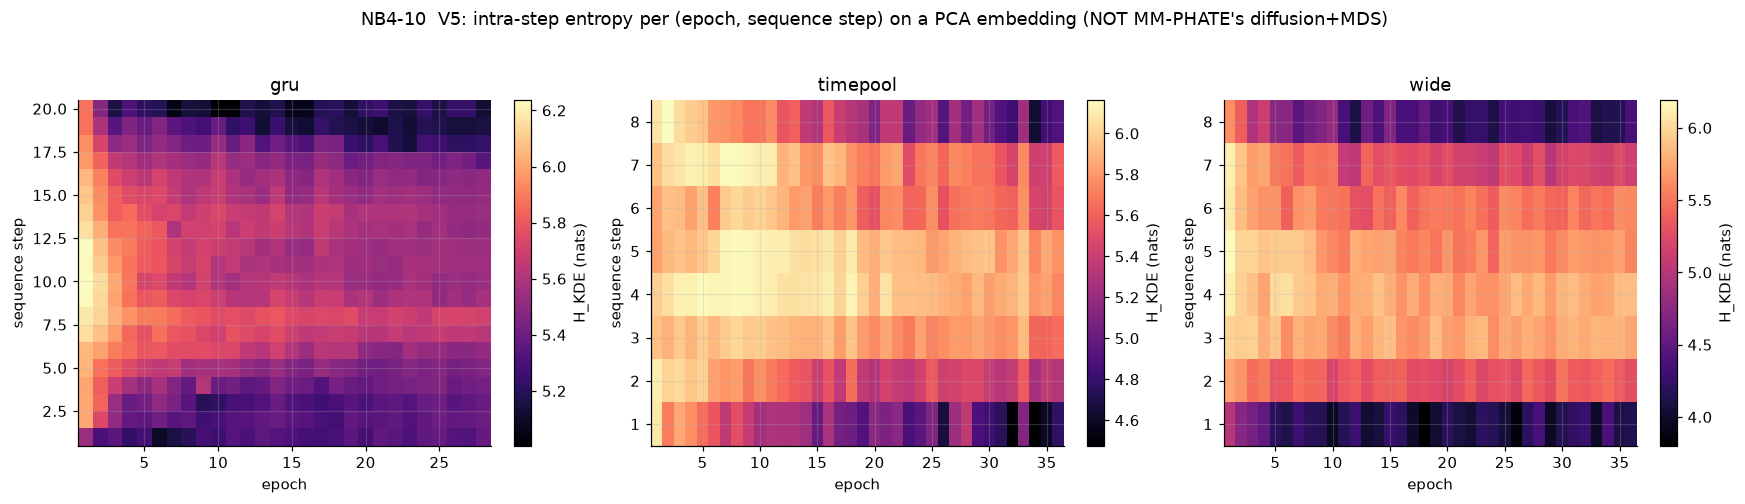

gru: mean intra-step entropy epoch 1 = 6.051, last epoch = 5.454, min = 5.447 at epoch 20
timepool: mean intra-step entropy epoch 1 = 5.979, last epoch = 5.409, min = 5.303 at epoch 34
wide: mean intra-step entropy epoch 1 = 5.862, last epoch = 5.216, min = 5.078 at epoch 29


In [41]:
# N4.6.4: V5 heatmaps.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
for ax, a in zip(axes, ARCHS):
    intra = MM[a][0]
    im = ax.imshow(intra.T, aspect="auto", origin="lower", cmap="magma", extent=[0.5, intra.shape[0] + 0.5, 0.5, intra.shape[1] + 0.5])
    ax.set(xlabel="epoch", ylabel="sequence step", title=a); fig.colorbar(im, ax=ax, fraction=0.046, label="H_KDE (nats)")
fig.suptitle("NB4-10  V5: intra-step entropy per (epoch, sequence step) on a PCA embedding (NOT MM-PHATE's diffusion+MDS)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-10_V5_intra_entropy.png")
for a in ARCHS:
    m = MM[a][0].mean(axis=1)
    print(f"{a}: mean intra-step entropy epoch 1 = {m[0]:.3f}, last epoch = {m[-1]:.3f}, min = {m.min():.3f} at epoch {int(m.argmin()) + 1}")

### How to read this chart

**Data source:** `mmphate_tensor` in `<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`, passed through the notebook's copy of
`mmphate_stats`; equals the precomputed `mmphate_stats.npz` when that file is present.

**Axes:** horizontal is epoch, vertical is sequence step ($20$ rows for `gru`, $8$ for the others), colour is
$H^{\mathrm{intra}}_{\tau,\omega}$ in nats (brighter = the 32 units are more spread out in the 2D embedding at that
step).

**Interpretation:** in the processing-versus-compression picture, high early entropy corresponds to units carrying
diverse, uncommitted responses and a later decline to units becoming redundant (compression). Here the decline is
real but modest: mean entropy per epoch moves only from about $6.0$ to about $5.5$ nats for `gru`, from about $6.0$
to $5.6$ for `timepool`, and from about $5.9$ to $5.1$ for `wide` (exact values printed above). The step-to-step
structure within an epoch is at least as large as the epoch-to-epoch drift, so most of the picture is *which step*,
not *which epoch*. This is a weak signal, not a phase diagram.

**Falsifier:** if entropy were flat in epoch for every step, there would be no compression trend to report;
the printed epoch-1-to-last change is small but non-zero. A reading that treats the colour gradient as a
demonstrated processing/compression transition is **not** supported: the embedding is PCA, the probe set is 120
samples, and there is one run.

### 6.3 V6: inter-step entropy per unit across epochs

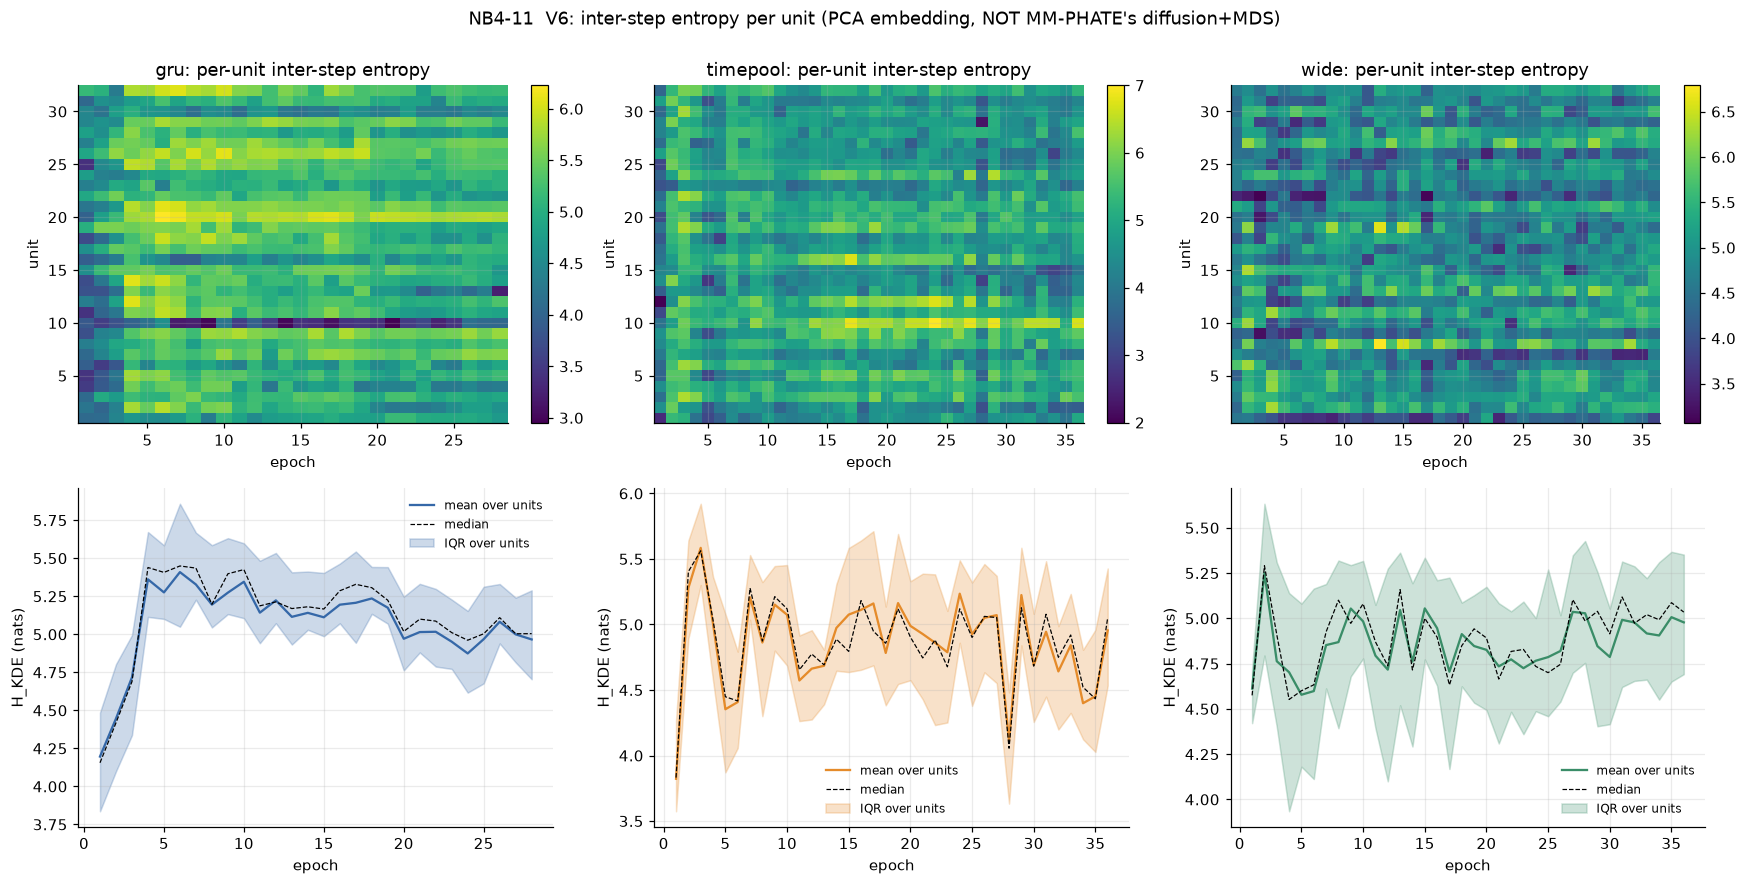

gru: mean inter-step entropy epoch 1 = 4.196, max = 5.409 at epoch 6, last = 4.966
timepool: mean inter-step entropy epoch 1 = 3.823, max = 5.585 at epoch 3, last = 4.955
wide: mean inter-step entropy epoch 1 = 4.612, max = 5.250 at epoch 2, last = 4.978


In [42]:
# N4.6.5: V6 heatmaps plus the across-unit mean and interquartile band.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, a in enumerate(ARCHS):
    inter = MM[a][1]; ep = np.arange(1, inter.shape[0] + 1)
    im = axes[0, j].imshow(inter.T, aspect="auto", origin="lower", cmap="viridis", extent=[0.5, inter.shape[0] + 0.5, 0.5, inter.shape[1] + 0.5])
    axes[0, j].set(xlabel="epoch", ylabel="unit", title=f"{a}: per-unit inter-step entropy"); fig.colorbar(im, ax=axes[0, j], fraction=0.046)
    q1, med, q3 = np.percentile(inter, [25, 50, 75], axis=1)
    axes[1, j].plot(ep, inter.mean(axis=1), color=ACOL[a], label="mean over units")
    axes[1, j].plot(ep, med, color="black", lw=0.8, ls="--", label="median")
    axes[1, j].fill_between(ep, q1, q3, color=ACOL[a], alpha=0.25, label="IQR over units")
    axes[1, j].set(xlabel="epoch", ylabel="H_KDE (nats)"); axes[1, j].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-11  V6: inter-step entropy per unit (PCA embedding, NOT MM-PHATE's diffusion+MDS)", y=1.0)
fig.tight_layout()
savefig(fig, "NB4-11_V6_inter_entropy.png")
for a in ARCHS:
    m = MM[a][1].mean(axis=1)
    print(f"{a}: mean inter-step entropy epoch 1 = {m[0]:.3f}, max = {m.max():.3f} at epoch {int(m.argmax()) + 1}, last = {m[-1]:.3f}")

### How to read this chart

**Data source:** the same tensors, statistic $H^{\mathrm{inter}}_{\tau,i}$, one value per (epoch, unit).

**Axes:** top row: horizontal is epoch, vertical is the unit index ($32$ units), colour the entropy of that unit's
2D trajectory across the sequence steps. Bottom row: the mean across units (coloured), the median (dashed), and the
interquartile band as a function of epoch.

**Interpretation:** a low value means a unit's embedded position is concentrated across steps (it responds the same
way at every time step); a high value means its position moves around across steps (temporal selectivity). The
measured pattern is **not a collapse**: the mean rises early (for `gru` from about $4.2$ at epoch 1 to about $5.3$
within a few epochs; for `timepool` from about $3.8$ to above $5$) and then plateaus or eases slightly. The
per-unit heterogeneity (the band and the horizontal stripes in the heatmap) is large compared with the epoch
trend. The expected "temporal selectivity collapse" is therefore not observed in these runs; if it exists at other
scales or settings it is not shown here.

**Falsifier:** if a sustained decline in mean inter-step entropy appeared in the late epochs for the healthy
`gru` and not for the others, it would support a selectivity-collapse reading. The printed maxima and last
values show only a small decline after the peak.

### 6.4 V7: flow alignment across epochs

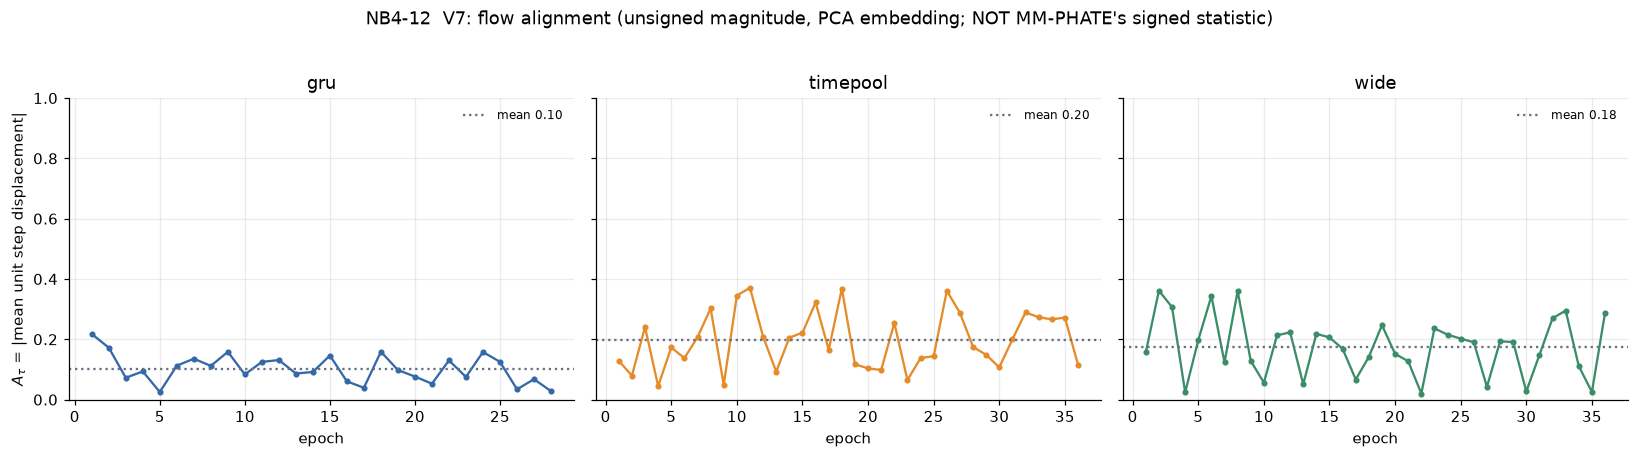

gru: A_tau mean 0.103, std 0.047, range 0.025 .. 0.218; rho(A_tau, epoch) = -0.342
timepool: A_tau mean 0.197, std 0.094, range 0.045 .. 0.371; rho(A_tau, epoch) = +0.162
wide: A_tau mean 0.176, std 0.096, range 0.020 .. 0.361; rho(A_tau, epoch) = -0.145


In [43]:
# N4.6.6: V7 curves. A_tau is the magnitude of the mean unit displacement of the unit-centroid across steps (unsigned).
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, a in zip(axes, ARCHS):
    flow = MM[a][2]
    ax.plot(np.arange(1, len(flow) + 1), flow, color=ACOL[a], marker="o", ms=3)
    ax.axhline(flow.mean(), color="#667085", ls=":", label=f"mean {flow.mean():.2f}")
    ax.set(xlabel="epoch", ylim=(0, 1), title=a); ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel(r"$A_\tau$ = |mean unit step displacement|")
fig.suptitle("NB4-12  V7: flow alignment (unsigned magnitude, PCA embedding; NOT MM-PHATE's signed statistic)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-12_V7_flow_alignment.png")
for a in ARCHS:
    f = MM[a][2]
    print(f"{a}: A_tau mean {f.mean():.3f}, std {f.std():.3f}, range {f.min():.3f} .. {f.max():.3f}; rho(A_tau, epoch) = {spearmanr(np.arange(len(f)), f)[0]:+.3f}")

### How to read this chart

**Data source:** the same tensors, statistic $A_\tau$.

**Axes:** horizontal is epoch; vertical is $A_\tau\in[0,1]$. A value near $1$ means the unit-centroid moves in
nearly the same direction at every step of the sequence (a coherent drift through the embedding); near $0$ means
the step-to-step displacements point in varying directions and cancel.

**Interpretation:** all three curves sit low (typically $0.03$ to $0.3$) and jump around from epoch to epoch,
with no monotone trend (the printed Spearman coefficients against epoch are the test). Because every $(\tau,\omega)$
has an independent PCA whose orientation is arbitrary, consecutive-step displacements are not expressed in a common
frame, and the low values are what randomly oriented frames would produce. The statistic is therefore close to
uninformative in this implementation; it is shown for completeness and labelled as such, not as evidence of a flow
regime.

**Falsifier:** a genuine flow structure would appear as $A_\tau$ near $1$ for some epochs or a systematic
trend; neither occurs. A version computed in a fixed, shared frame (for example the diffusion-plus-MDS embedding
the paper uses) might differ, which cannot be tested with the PCA embedding here.

### 6.5 V8: multiway node embedding

Every node $(\tau,\omega,i)$ is a $120$-dimensional vector (that unit's responses over the probe set at that
epoch and step). All nodes of an architecture are stacked and embedded together by **one** PCA to 2D, then
drawn twice: coloured by epoch and coloured by sequence step. Node counts are $28\times20\times32=17{,}920$ for
`gru` and $36\times8\times32=9{,}216$ for `timepool` and `wide` (reading A in Section 6.1). **Deviation:** PCA, not
diffusion + MDS.

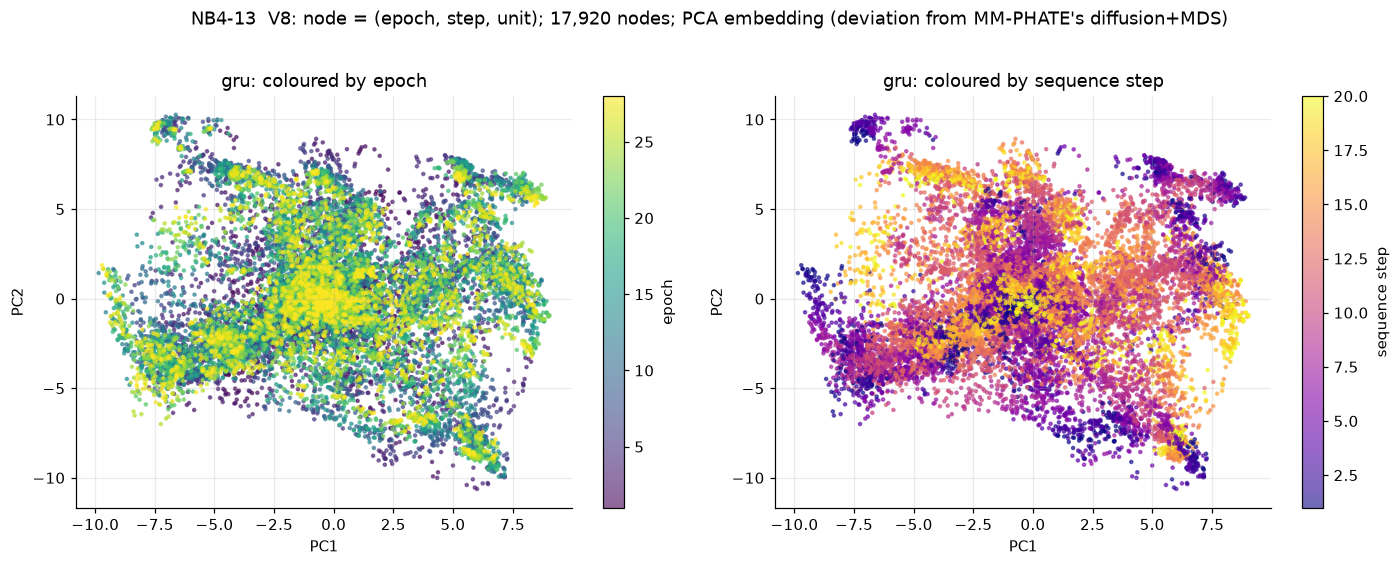

[N4.6.7[gru_nodes]] 17,920 nodes for gru -> PASS
gru: rank correlation of PC1/PC2 with epoch = +0.017/+0.004; with step = +0.050/+0.109


In [44]:
# N4.6.7: V8 for gru (two colourings).
def v8_nodes(arch):
    T = DATA[arch]["npz"]["mmphate_tensor"]; E, S, W, U = T.shape
    nodes, ep_id, w_id = [], [], []
    for t in range(E):
        for w in range(W):
            nodes.append(T[t, :, w, :].T); ep_id += [t] * U; w_id += [w] * U
    emb = pca_embed(np.concatenate(nodes), 2)
    return emb, np.array(ep_id), np.array(w_id)

def v8_figure(arch, fname, fig_no):
    emb, ep_id, w_id = v8_nodes(arch)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for k, (c, lbl, cm) in enumerate([(ep_id + 1, "epoch", "viridis"), (w_id + 1, "sequence step", "plasma")]):
        s = ax[k].scatter(emb[:, 0], emb[:, 1], c=c, cmap=cm, s=4, alpha=0.6)
        ax[k].set(title=f"{arch}: coloured by {lbl}", xlabel="PC1", ylabel="PC2"); fig.colorbar(s, ax=ax[k], label=lbl)
    fig.suptitle(f"NB4-{fig_no}  V8: node = (epoch, step, unit); {len(emb):,} nodes; PCA embedding (deviation from MM-PHATE's diffusion+MDS)", y=1.02)
    fig.tight_layout()
    savefig(fig, fname)
    return emb, ep_id, w_id

emb_g, ep_g, w_g = v8_figure("gru", "NB4-13_V8_multiway_gru.png", 13)
check("N4.6.7[gru_nodes]", len(emb_g) == 28 * 20 * 32, f"{len(emb_g):,} nodes for gru")
rho_ep = spearmanr(ep_g, emb_g[:, 0])[0], spearmanr(ep_g, emb_g[:, 1])[0]
rho_w = spearmanr(w_g, emb_g[:, 0])[0], spearmanr(w_g, emb_g[:, 1])[0]
print(f"gru: rank correlation of PC1/PC2 with epoch = {rho_ep[0]:+.3f}/{rho_ep[1]:+.3f}; with step = {rho_w[0]:+.3f}/{rho_w[1]:+.3f}")

### How to read this chart

**Data source:** `mmphate_tensor` in `<ARTIFACT_ROOT>/metrics/arch-gru.probes.npz` (shape $(28,120,20,32)$).

**Axes:** each point is one (epoch, step, unit) node; the two axes are the first two principal components of the
stacked $120$-dimensional node vectors. Left panel colours nodes by epoch, right panel by sequence step.

**Interpretation:** if training reorganised the units, nodes from early and late epochs would occupy different
regions (left panel would show a colour gradient), and if units were step-specific, the right panel would show
step-ordered structure. The printed rank correlations of PC1 and PC2 with epoch and with step quantify how much of
that structure a 2D PCA can see; the scatter itself is dominated by the arrangement of units, and the
colour-by-epoch panel is mixed rather than a clean gradient. Because the tensor is per-unit z-scored, a large part of
the cloud's shape is the standardisation.

**Falsifier:** a strong monotone epoch (or step) gradient across the cloud would mean training or position dominates
the variance; correlations near zero, as here, mean neither dominates in the leading two components.

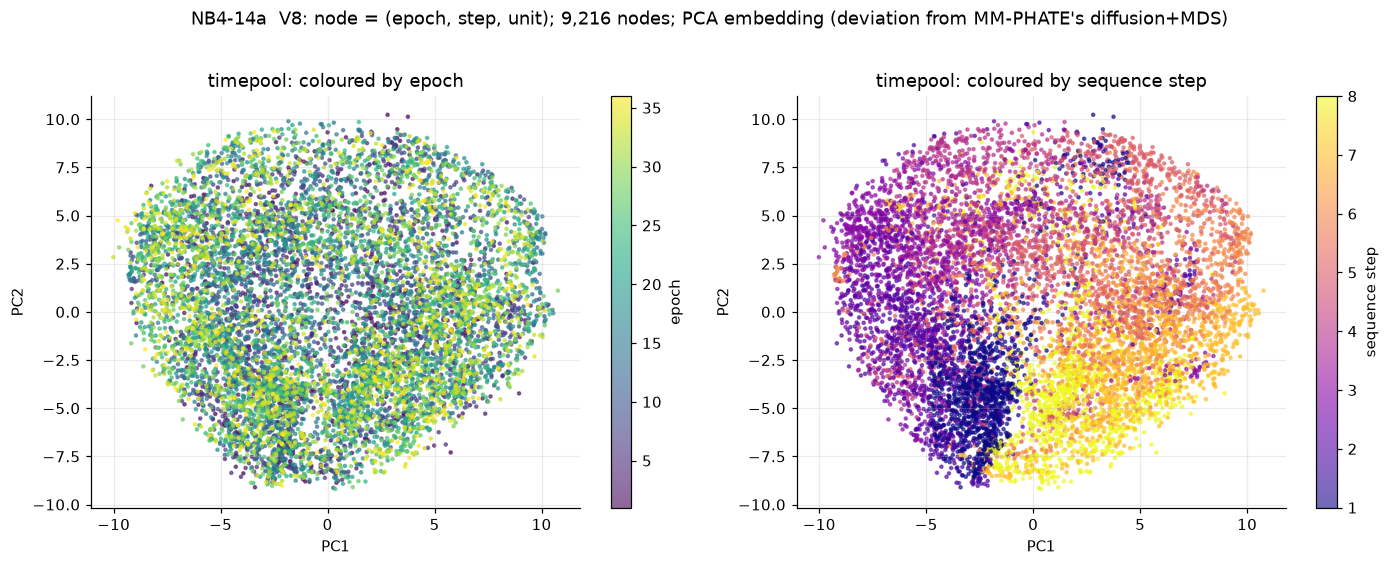

[N4.6.8[tp_nodes]] 9,216 nodes for timepool -> PASS


True

In [45]:
# N4.6.8: V8 for timepool and wide.
emb_t, ep_t, w_t = v8_figure("timepool", "NB4-14a_V8_multiway_timepool.png", "14a")
check("N4.6.8[tp_nodes]", len(emb_t) == 36 * 8 * 32, f"{len(emb_t):,} nodes for timepool")

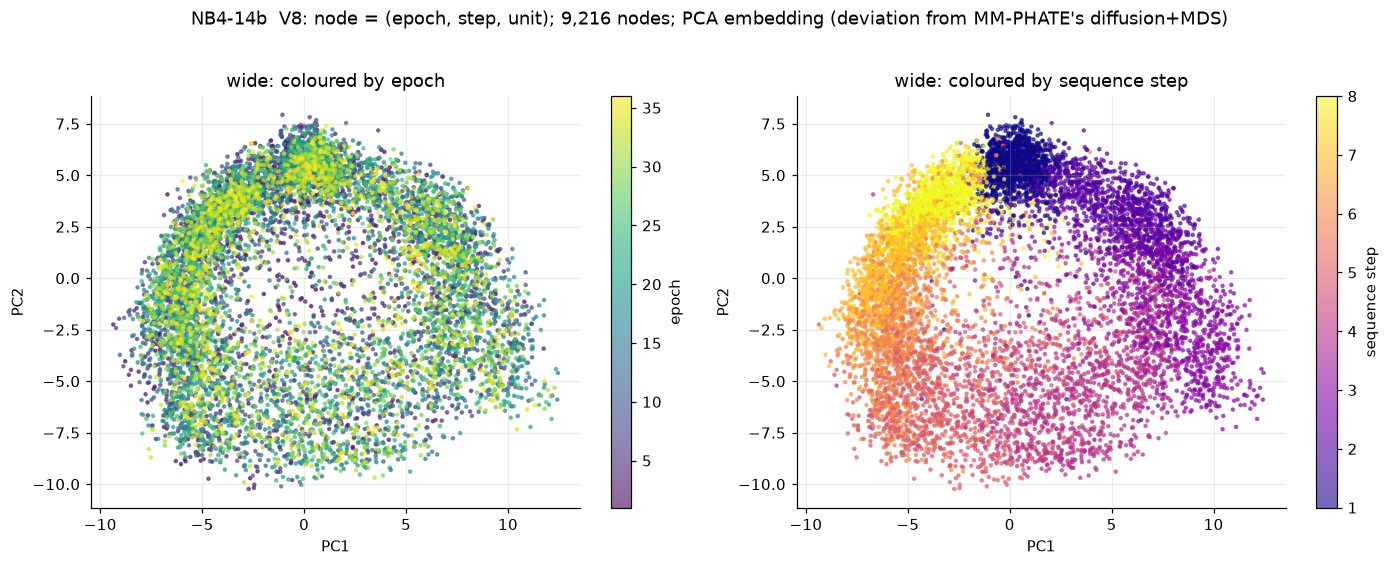

[N4.6.9[wide_nodes]] 9,216 nodes for wide -> PASS
timepool: rank corr PC1/PC2 with epoch = +0.000/-0.005; with step = +0.568/-0.077
wide: rank corr PC1/PC2 with epoch = -0.001/-0.039; with step = -0.667/-0.212


In [46]:
# N4.6.9: V8 wide.
emb_w, ep_w, w_w = v8_figure("wide", "NB4-14b_V8_multiway_wide.png", "14b")
check("N4.6.9[wide_nodes]", len(emb_w) == 36 * 8 * 32, f"{len(emb_w):,} nodes for wide")
for a, (e, ep, w) in (("timepool", (emb_t, ep_t, w_t)), ("wide", (emb_w, ep_w, w_w))):
    print(f"{a}: rank corr PC1/PC2 with epoch = {spearmanr(ep, e[:, 0])[0]:+.3f}/{spearmanr(ep, e[:, 1])[0]:+.3f}; with step = {spearmanr(w, e[:, 0])[0]:+.3f}/{spearmanr(w, e[:, 1])[0]:+.3f}")

### How to read these two charts (`timepool`, `wide`)

**Data source:** `mmphate_tensor` in `arch-timepool.probes.npz` and `arch-wide.probes.npz`, shape
$(36,120,8,32)$ each; $9{,}216$ nodes per figure.

**Axes and colouring:** identical to the `gru` figure.

**Interpretation:** with only $8$ sequence steps the step colouring has fewer levels, and the two architectures
differ from `gru` mainly in how the units of one step spread; the printed correlations again say how much epoch or
step structure the first two components carry. As with `gru`, none of this is evidence about MM-PHATE's own
findings, since the embedding is different.

**Falsifier:** if `wide` (whose validation loss oscillates) showed a much stronger epoch gradient than `gru`, that
would suggest the instability reorganises the representation; the printed values are the test and are reported as
computed.

### 6.6 Further MM-PHATE-style read-outs: epoch-to-epoch change and the step profile

The research file lists four MM-PHATE statistics: intra-step entropy, inter-step entropy, signed flow alignment,
and epoch-to-epoch change magnitude. Sections 6.2 to 6.4 covered the first three. The fourth is added here in the
same spirit as the others: **this notebook's own implementation** on the PCA embedding, defined as the Euclidean
norm of the change of the epoch's intra-step entropy vector (one entry per sequence step) between consecutive
epochs, $\Delta_\tau = \lVert H^{\mathrm{intra}}_{\tau,\cdot} - H^{\mathrm{intra}}_{\tau-1,\cdot}\rVert_2$. It is
not claimed to be the paper's definition. The step profile (mean over epochs of $H^{\mathrm{intra}}_{\tau,\omega}$ as
a function of $\omega$) is also shown, since the heatmaps suggested the step dimension carries more variation than
the epoch dimension.

[N4.6.10[gru.delta_len]] 27 epoch-to-epoch changes for 28 epochs -> PASS
[N4.6.10[timepool.delta_len]] 35 epoch-to-epoch changes for 36 epochs -> PASS
[N4.6.10[wide.delta_len]] 35 epoch-to-epoch changes for 36 epochs -> PASS


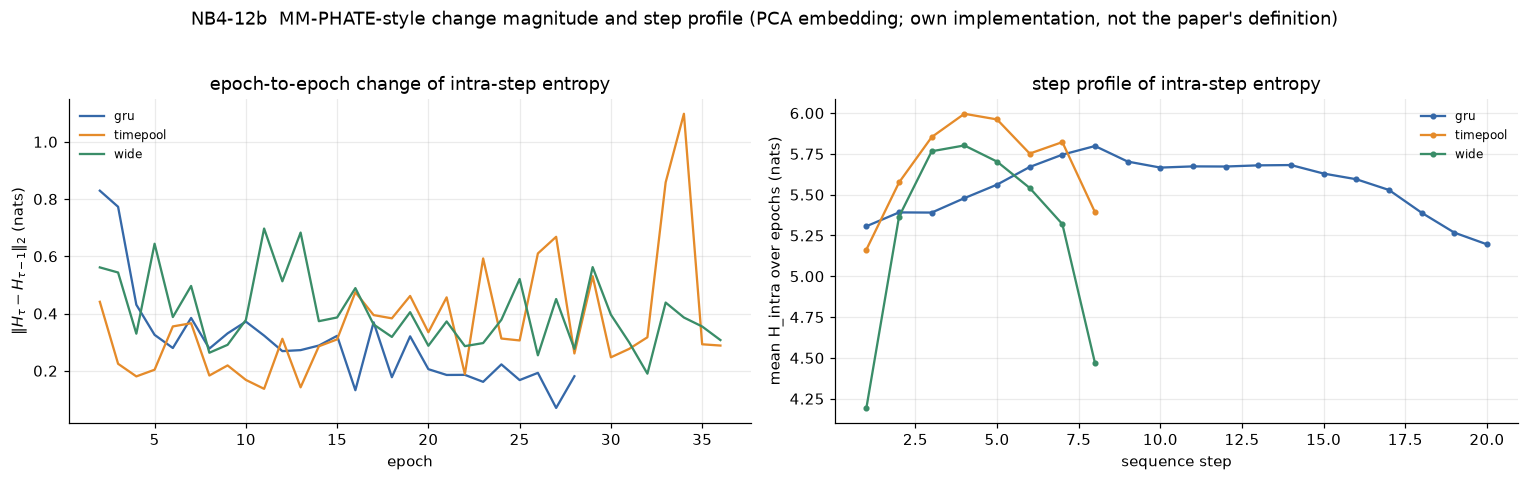

          mean change ep2-6  mean change last 5  step-profile range  epoch-trend range
gru                   0.528               0.167               0.602              0.604
timepool              0.281               0.571               0.832              0.696
wide                  0.493               0.335               1.608              0.784

[N4.6.10[gru.change_settles]] change magnitude is smaller in the last five epochs than in epochs 2-6 -> PASS
[N4.6.10[timepool.change_settles]] change magnitude is smaller in the last five epochs than in epochs 2-6 -> FAIL
[N4.6.10[wide.change_settles]] change magnitude is smaller in the last five epochs than in epochs 2-6 -> PASS


In [47]:
# N4.6.10: epoch-to-epoch change magnitude and the step profile of intra-step entropy.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
DELTA, PROF = {}, {}
for a in ARCHS:
    intra = MM[a][0]
    DELTA[a] = np.linalg.norm(np.diff(intra, axis=0), axis=1)
    PROF[a] = intra.mean(axis=0)
    axes[0].plot(np.arange(2, intra.shape[0] + 1), DELTA[a], color=ACOL[a], label=a)
    axes[1].plot(np.arange(1, intra.shape[1] + 1), PROF[a], color=ACOL[a], marker="o", ms=3, label=a)
    check(f"N4.6.10[{a}.delta_len]", len(DELTA[a]) == intra.shape[0] - 1, f"{len(DELTA[a])} epoch-to-epoch changes for {intra.shape[0]} epochs")
axes[0].set(xlabel="epoch", ylabel=r"$\|H_\tau - H_{\tau-1}\|_2$ (nats)", title="epoch-to-epoch change of intra-step entropy")
axes[1].set(xlabel="sequence step", ylabel="mean H_intra over epochs (nats)", title="step profile of intra-step entropy")
for x in axes: x.legend(frameon=False, fontsize=8)
fig.suptitle("NB4-12b  MM-PHATE-style change magnitude and step profile (PCA embedding; own implementation, not the paper's definition)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-12b_change_and_profile.png")
tab = pd.DataFrame({a: {"mean change ep2-6": DELTA[a][:5].mean(), "mean change last 5": DELTA[a][-5:].mean(),
                        "step-profile range": PROF[a].max() - PROF[a].min(),
                        "epoch-trend range": MM[a][0].mean(axis=1).max() - MM[a][0].mean(axis=1).min()} for a in ARCHS}).T
display(tab.round(3))
for a in ARCHS:
    check(f"N4.6.10[{a}.change_settles]", tab.loc[a, "mean change last 5"] < tab.loc[a, "mean change ep2-6"], "change magnitude is smaller in the last five epochs than in epochs 2-6")

### How to read this chart

**Data source:** the `intra` array of the MM-PHATE statistics computed in Section 6 from `mmphate_tensor` in
`<ARTIFACT_ROOT>/metrics/arch-*.probes.npz`.

**Axes:** left, epoch versus the L2 norm (over sequence steps) of the change of the intra-step entropy vector
from the previous epoch, in nats. Right, sequence step versus the intra-step entropy averaged over all epochs.

**Interpretation:** the left panel says how quickly the entropy landscape stops changing: a decaying curve is the
MM-PHATE-style signature of a representation that has stopped reorganising. The right panel is descriptive: its
range across steps is compared in the table with the range across epochs, and it shows that structure along the
sequence axis (for example edge steps of the recurrent or pooled sequence differing from interior steps) is at least
as large as structure along the epoch axis.

**Falsifier:** if the change magnitude did not decrease for the healthy `gru` while validation loss had
stabilised, the entropy statistic would not reflect convergence. The table compares early and late means.

## 7. Post-training results from the `summary` block

> **EXPLORATION CONFIGURATION.** Every number in this section comes from the `summary` block of a result file
> produced with **4 stress conditions** (`clean`, `gain_+10`, `noise_10`, `reverb_mid`) and **200 bootstrap
> resamples**, for a single trained model per architecture (clean training, seed 17). These are exploration
> results. They are not publication numbers: the full 11-condition / 2000-resample evaluation was never run.
> Bootstrap intervals from 200 resamples are noisy at the third decimal.

Each architecture's `summary` holds, per stress condition and per calibration mode
(`uncalibrated`, `calibrated` with the temperature fitted on the calibration split), accuracy, macro-F1, NLL,
Brier, ECE at 10/15/20 bins, AURC, selective risk at coverage $0.8$ and $0.9$, OOD AUROC, CRC results at
$\alpha\in\{0.05,0.10\}$ (threshold, miscoverage, mean set size), and bootstrap intervals for four metrics
(accuracy, ECE with 10 bins, NLL, AURC).

**What is *not* available here, and therefore not plotted.** The result files hold summary numbers, not logits.
NB3's reliability diagram and risk-coverage curve are built from per-example logits; those cannot be rebuilt from
these artifacts. Instead this section presents the reliability-style information that *is* stored (ECE at three bin
counts, with and without temperature scaling) and the risk-coverage information that is stored (selective risk at two
coverages and AURC). This mirrors NB3's plotting conventions (grouped uncalibrated/calibrated bars, annotated
values, "How to read this chart" blocks) without inventing data.

In [48]:
# N4.7.1: flatten the summary block of the three result files into one long table.
CONDS = DATA["gru"]["res"]["summary"]["conditions"]
COND_LIST = list(CONDS)
MODES = ("uncalibrated", "calibrated")
SCALARS = ["accuracy", "macro_f1", "nll", "brier", "ece_10", "ece_15", "ece_20", "aurc", "selective_risk_0.8", "selective_risk_0.9", "ood_auroc"]
rows = []
for a in ARCHS:
    for c in COND_LIST:
        for m in MODES:
            d = DATA[a]["res"]["summary"]["conditions"][c][m]
            row = {"arch": a, "condition": c, "mode": m}
            row.update({k: d[k] for k in SCALARS})
            for al in ("0.05", "0.1"):
                row[f"crc{al}_threshold"] = d["crc"][al]["threshold"]
                row[f"crc{al}_miscoverage"] = d["crc"][al]["miscoverage"]
                row[f"crc{al}_set_size"] = d["crc"][al]["mean_set_size"]
            for k, v in d["ci"].items():
                row[f"{k}_lo"], row[f"{k}_hi"] = v["lower"], v["upper"]
            rows.append(row)
SUM = pd.DataFrame(rows)
display(SUM[["arch", "condition", "mode", "accuracy", "macro_f1", "nll", "brier", "ece_10", "aurc", "ood_auroc"]].round(4))
check("N4.7.1[rows]", len(SUM) == 3 * 4 * 2, f"{len(SUM)} rows = 3 archs x 4 conditions x 2 modes")
check("N4.7.1[conditions]", COND_LIST == ["clean", "gain_+10", "noise_10", "reverb_mid"], f"conditions {COND_LIST}")

        arch   condition          mode  accuracy  macro_f1     nll   brier  ece_10    aurc  ood_auroc
0        gru       clean  uncalibrated    0.8787    0.8807  0.4318  0.1730  0.0263  0.0169     0.8291
1        gru       clean    calibrated    0.8787    0.8807  0.4300  0.1727  0.0248  0.0169     0.8293
2        gru    gain_+10  uncalibrated    0.8287    0.8324  0.5747  0.2398  0.0503  0.0298     0.8046
3        gru    gain_+10    calibrated    0.8287    0.8324  0.5720  0.2392  0.0522  0.0298     0.8047
4        gru    noise_10  uncalibrated    0.1380    0.1198  4.4671  1.5103  0.7469  0.7531     0.4727
5        gru    noise_10    calibrated    0.1380    0.1198  4.4039  1.5046  0.7438  0.7532     0.4731
6        gru  reverb_mid  uncalibrated    0.8176    0.8210  0.6300  0.2554  0.0482  0.0374     0.7504
7        gru  reverb_mid    calibrated    0.8176    0.8210  0.6266  0.2549  0.0456  0.0374     0.7509
8   timepool       clean  uncalibrated    0.5491    0.5437  1.3758  0.5873  0.0431

[N4.7.1[rows]] 24 rows = 3 archs x 4 conditions x 2 modes -> PASS
[N4.7.1[conditions]] conditions ['clean', 'gain_+10', 'noise_10', 'reverb_mid'] -> PASS


True

In [49]:
# N4.7.2: internal-consistency checks on the summary block (each is an individual PASS/FAIL).
for a in ARCHS:
    for c in COND_LIST:
        u = SUM[(SUM.arch == a) & (SUM.condition == c) & (SUM["mode"] == "uncalibrated")].iloc[0]
        k = SUM[(SUM.arch == a) & (SUM.condition == c) & (SUM["mode"] == "calibrated")].iloc[0]
        check(f"N4.7.2[{a}.{c}.argmax_invariance]", abs(u["accuracy"] - k["accuracy"]) < 1e-12, "temperature scaling leaves accuracy unchanged")
        for m_name, r in (("uncal", u), ("cal", k)):
            ok = all(r[f"{q}_lo"] <= r[q] <= r[f"{q}_hi"] for q in ("accuracy", "ece_10", "nll", "aurc"))
            check(f"N4.7.2[{a}.{c}.{m_name}.ci_contains_point]", ok, "bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc")

[N4.7.2[gru.clean.argmax_invariance]] temperature scaling leaves accuracy unchanged -> PASS
[N4.7.2[gru.clean.uncal.ci_contains_point]] bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc -> PASS
[N4.7.2[gru.clean.cal.ci_contains_point]] bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc -> PASS
[N4.7.2[gru.gain_+10.argmax_invariance]] temperature scaling leaves accuracy unchanged -> PASS
[N4.7.2[gru.gain_+10.uncal.ci_contains_point]] bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc -> PASS
[N4.7.2[gru.gain_+10.cal.ci_contains_point]] bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc -> PASS
[N4.7.2[gru.noise_10.argmax_invariance]] temperature scaling leaves accuracy unchanged -> PASS
[N4.7.2[gru.noise_10.uncal.ci_contains_point]] bootstrap interval contains the point estimate for accuracy, ece_10, nll and aurc -> PASS
[N4.7.2[gru.noise_10.cal.ci_contains_point]

### 7.1 Accuracy and its bootstrap interval under stress

The headline of the post-training results is a robustness gap. The trained models were fitted on clean audio
only. Under `gain_+10` and `reverb_mid` the drop is moderate, but under `noise_10` accuracy falls **to or near
chance** for the two best clean models. The next figure shows accuracy with the recorded $95\%$-style bootstrap
intervals (the interval level is whatever `summarise_arm` used; only the lower and upper values are stored).

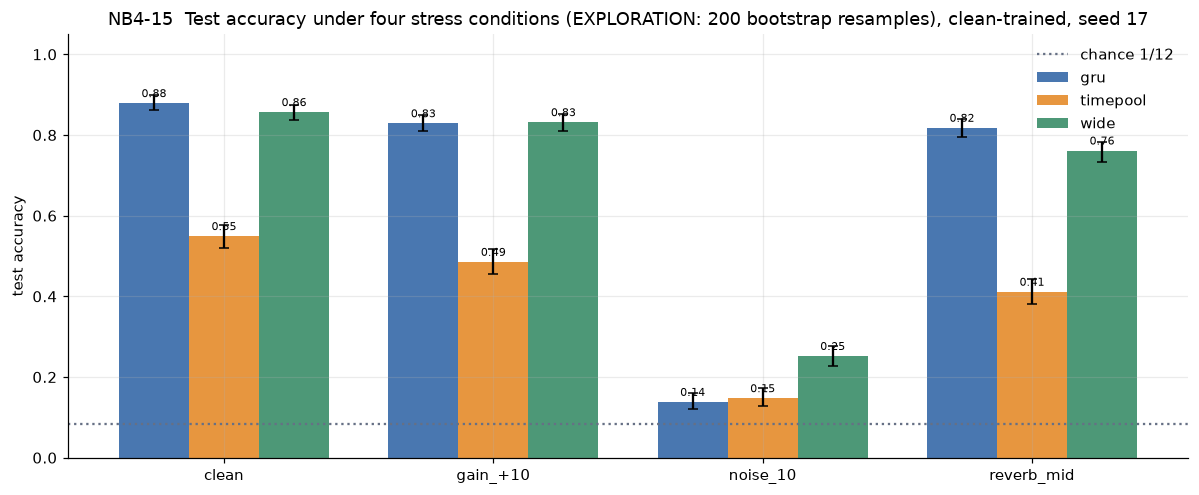

arch          gru  timepool   wide
condition                         
clean       0.879     0.549  0.856
gain_+10    0.829     0.485  0.831
noise_10    0.138     0.147  0.252
reverb_mid  0.818     0.411  0.761


In [50]:
# N4.7.3: accuracy with bootstrap intervals, three archs x four conditions, uncalibrated.
fig, ax = plt.subplots(figsize=(11, 4.6)); w = 0.26
for j, a in enumerate(ARCHS):
    d = SUM[(SUM.arch == a) & (SUM["mode"] == "uncalibrated")].set_index("condition").loc[COND_LIST]
    x = np.arange(len(COND_LIST)) + (j - 1) * w
    ax.bar(x, d["accuracy"], w, color=ACOL[a], label=a, alpha=0.9,
           yerr=[d["accuracy"] - d["accuracy_lo"], d["accuracy_hi"] - d["accuracy"]], capsize=3)
    for xi, v in zip(x, d["accuracy"]):
        ax.annotate(f"{v:.2f}", (xi, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=7.5)
ax.axhline(1 / 12, color="#667085", ls=":", label="chance 1/12")
ax.set_xticks(np.arange(len(COND_LIST))); ax.set_xticklabels(COND_LIST)
ax.set(ylabel="test accuracy", ylim=(0, 1.05), title="NB4-15  Test accuracy under four stress conditions (EXPLORATION: 200 bootstrap resamples), clean-trained, seed 17")
ax.legend(frameon=False)
fig.tight_layout()
savefig(fig, "NB4-15_accuracy_ci.png")
print(SUM[(SUM["mode"] == "uncalibrated")].pivot(index="condition", columns="arch", values="accuracy").round(3))

### How to read this chart

**Data source:** `summary/conditions/<cond>/uncalibrated/accuracy` and `summary/.../ci/accuracy/{lower,upper}` in
`arch-*.result.json`. Calibrated accuracy is identical by construction (argmax invariance, checked above).

**Axes:** horizontal is the stress condition; vertical is accuracy on the $1080$-clip test split. Bars are
coloured by architecture, error bars are the recorded bootstrap interval (200 resamples), the dotted line is chance
($1/12$).

**Interpretation:** on `clean`, `gru` ($0.88$) and `wide` ($0.86$) are far above `timepool` ($0.55$). `gain_+10`
and `reverb_mid` cost `gru` about $5$ points and `wide` up to about $10$, and `timepool` more in relative terms.
`noise_10` is different in kind: `gru` falls to about $0.14$, `timepool` to about $0.15$, `wide` to about $0.25$, all
close to chance for `gru` and `timepool`. The most accurate clean model is therefore the most fragile to additive
noise in this run. Because it is a single seed with a clean-only training condition, the finding is that
*clean training does not transfer to noise here*, not that `gru` is inherently fragile.

**Falsifier:** if error bars overlapped between `gru` and `wide` on `clean`, their ordering would not be
established; the intervals are narrow (a few points). If the `noise_10` bars were near their `clean` height, the
stress had no effect; the gap is the finding.

### 7.2 Calibration: ECE at three bin counts, before and after temperature scaling

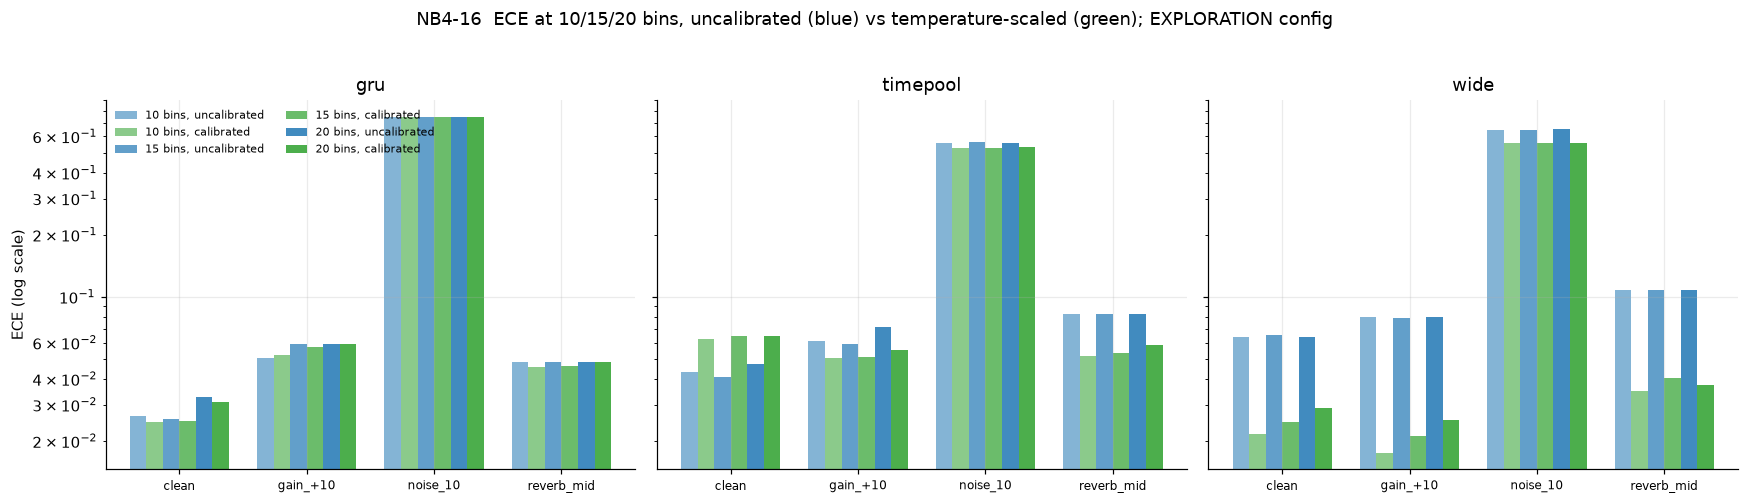

mode                 calibrated  uncalibrated  ratio cal/uncal
arch     condition                                            
gru      clean           0.0248        0.0263           0.9406
         gain_+10        0.0522        0.0503           1.0372
         noise_10        0.7438        0.7469           0.9959
         reverb_mid      0.0456        0.0482           0.9456
timepool clean           0.0626        0.0431           1.4519
         gain_+10        0.0504        0.0612           0.8230
         noise_10        0.5253        0.5594           0.9392
         reverb_mid      0.0517        0.0823           0.6280
wide     clean           0.0216        0.0638           0.3385
         gain_+10        0.0176        0.0795           0.2210
         noise_10        0.5585        0.6473           0.8628
         reverb_mid      0.0348        0.1082           0.3217

fitted temperatures: {'gru': 1.016, 'timepool': 1.11, 'wide': 1.6}
[N4.7.4[wide_helped]] temperature scaling lowers ece_10 for wide on all four conditions -> PASS
[N4.7.4[gru_T_near_1]] gru's fitted temperature is close to 1 (already near-calibrated on clean) -> PASS


True

In [51]:
# N4.7.4: ECE (10/15/20 bins) uncalibrated vs calibrated, per arch, four conditions.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True); w = 0.13
for ax, a in zip(axes, ARCHS):
    for bi, bins in enumerate((10, 15, 20)):
        for mi, m in enumerate(MODES):
            d = SUM[(SUM.arch == a) & (SUM["mode"] == m)].set_index("condition").loc[COND_LIST]
            x = np.arange(len(COND_LIST)) + (bi * 2 + mi - 2.5) * w
            ax.bar(x, d[f"ece_{bins}"], w, color=("#1f77b4" if m == "uncalibrated" else "#2ca02c"), alpha=0.55 + 0.15 * bi,
                   label=f"{bins} bins, {m}" if a == ARCHS[0] else None)
    ax.set_xticks(np.arange(len(COND_LIST))); ax.set_xticklabels(COND_LIST, fontsize=8); ax.set(title=a, yscale="log")
axes[0].set_ylabel("ECE (log scale)"); axes[0].legend(frameon=False, fontsize=7, ncol=2)
fig.suptitle("NB4-16  ECE at 10/15/20 bins, uncalibrated (blue) vs temperature-scaled (green); EXPLORATION config", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-16_ece_bins.png")
t = SUM.pivot_table(index=["arch", "condition"], columns="mode", values="ece_10")
t["ratio cal/uncal"] = t["calibrated"] / t["uncalibrated"]
display(t.round(4))
print("fitted temperatures:", {a: round(DATA[a]["res"]["summary"]["temperature"], 3) for a in ARCHS})
check("N4.7.4[wide_helped]", (t.loc["wide"]["ratio cal/uncal"] < 1).all(), "temperature scaling lowers ece_10 for wide on all four conditions")
check("N4.7.4[gru_T_near_1]", abs(DATA["gru"]["res"]["summary"]["temperature"] - 1) < 0.05, "gru's fitted temperature is close to 1 (already near-calibrated on clean)")

### How to read this chart

**Data source:** `ece_10`, `ece_15`, `ece_20` under `summary/conditions/<cond>/{uncalibrated,calibrated}` in each
result file, and the fitted temperature `summary/temperature`.

**Axes:** panels are architectures; horizontal is the stress condition; vertical is ECE on a log axis.
Blue bars are uncalibrated, green calibrated; within each colour the three shades are $10$, $15$, $20$ bins.

**Interpretation:** ECE is not much affected by the choice of bin count *within* a condition, which is a small
robustness check on the reading. Temperature scaling helps `wide` on every condition (fitted $T\approx1.6$,
i.e. an overconfident model), leaves `gru` essentially unchanged ($T\approx1.02$), and is mixed for `timepool` on
`clean` (ECE with 10 bins rises). On `noise_10` all ECEs are enormous (about $0.5$--$0.75$) and temperature scaling,
fitted on *clean* calibration data, barely reduces them: recalibrating on clean audio cannot repair miscalibration
that arises from a distribution shift it never saw.

**Falsifier:** if calibrated ECE were far lower than uncalibrated on `noise_10`, clean-fit temperature scaling
would be robust to shift; it is not. ECE with only $1080$ test points and $10$--$20$ bins carries visible sampling
noise, so differences of a few thousandths are not meaningful.

### 7.3 NLL and AURC with bootstrap intervals

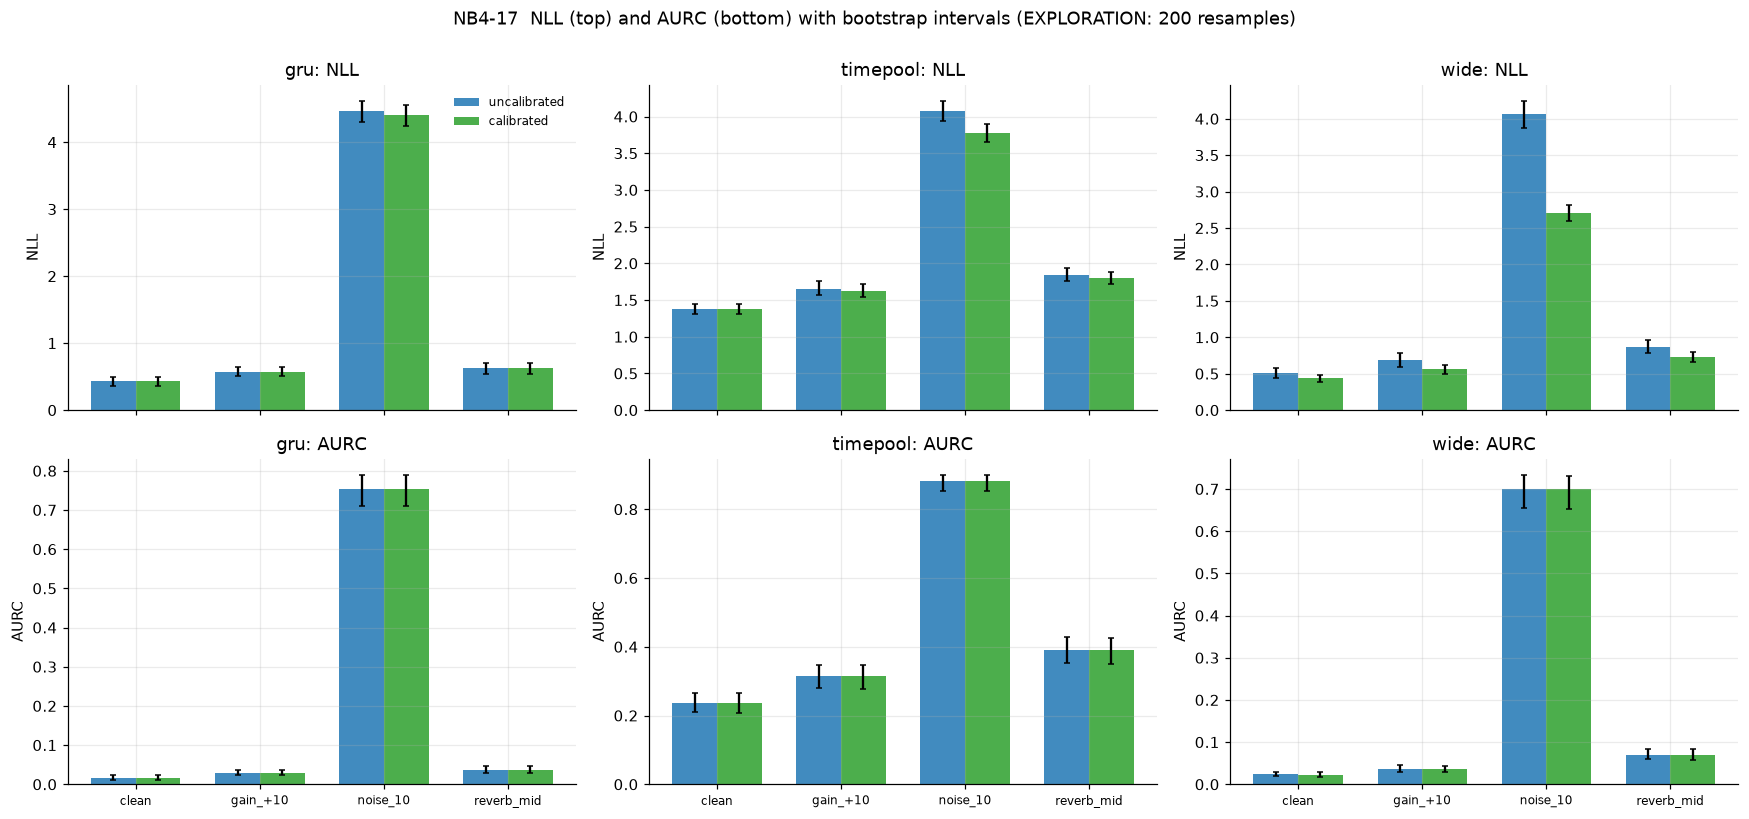

arch          gru  timepool   wide
condition                         
clean       0.017     0.236  0.024
gain_+10    0.030     0.315  0.037
noise_10    0.753     0.881  0.701
reverb_mid  0.037     0.391  0.070


In [52]:
# N4.7.5: NLL and AURC with intervals, uncalibrated vs calibrated (gru and wide differ visibly under noise).
fig, axes = plt.subplots(2, 3, figsize=(16, 7.4), sharex=True)
for j, a in enumerate(ARCHS):
    for ri, q in enumerate(("nll", "aurc")):
        ax = axes[ri, j]
        for mi, m in enumerate(MODES):
            d = SUM[(SUM.arch == a) & (SUM["mode"] == m)].set_index("condition").loc[COND_LIST]
            x = np.arange(len(COND_LIST)) + (mi - 0.5) * 0.36
            ax.bar(x, d[q], 0.36, color=("#1f77b4" if m == "uncalibrated" else "#2ca02c"), alpha=0.85, label=m,
                   yerr=[d[q] - d[f"{q}_lo"], d[f"{q}_hi"] - d[q]], capsize=2)
        ax.set_xticks(np.arange(len(COND_LIST))); ax.set_xticklabels(COND_LIST, fontsize=8); ax.set(title=f"{a}: {q.upper()}", ylabel=q.upper())
        if ri == 0 and j == 0: ax.legend(frameon=False, fontsize=8)
fig.suptitle("NB4-17  NLL (top) and AURC (bottom) with bootstrap intervals (EXPLORATION: 200 resamples)", y=1.0)
fig.tight_layout()
savefig(fig, "NB4-17_nll_aurc.png")
print(SUM[SUM["mode"] == "uncalibrated"].pivot(index="condition", columns="arch", values="aurc").round(3))

### How to read this chart

**Data source:** `nll`, `aurc` and `ci/nll`, `ci/aurc` in each result file's `summary` block.

**Axes:** rows are NLL (top) and AURC (bottom), columns architectures, horizontal the stress condition. Blue is
uncalibrated, green calibrated; whiskers are the recorded bootstrap interval (200 resamples).

**Interpretation:** NLL grows from roughly $0.4$ (`gru`, clean) to about $4.5$ under `noise_10`, i.e. the model is
confidently wrong. AURC, the area under the risk-coverage curve (lower is better, it measures how well confidence
ranks correct above incorrect predictions), rises from about $0.017$ (`gru`, clean) to about $0.75$ under noise:
under noise, confidence stops being a useful ranking of correctness. The largest calibration gain in NLL is `wide`
under `noise_10` ($4.07 \rightarrow 2.71$), a case where temperature scaling does something visible but still leaves NLL
far above its clean value.

**Falsifier:** if AURC under `noise_10` were close to the clean AURC, selective prediction (abstaining on
low-confidence inputs) would still be reliable under this shift. It is not: the values differ by more than an
order of magnitude, far outside the bootstrap whiskers.

### 7.4 Selective risk at fixed coverage

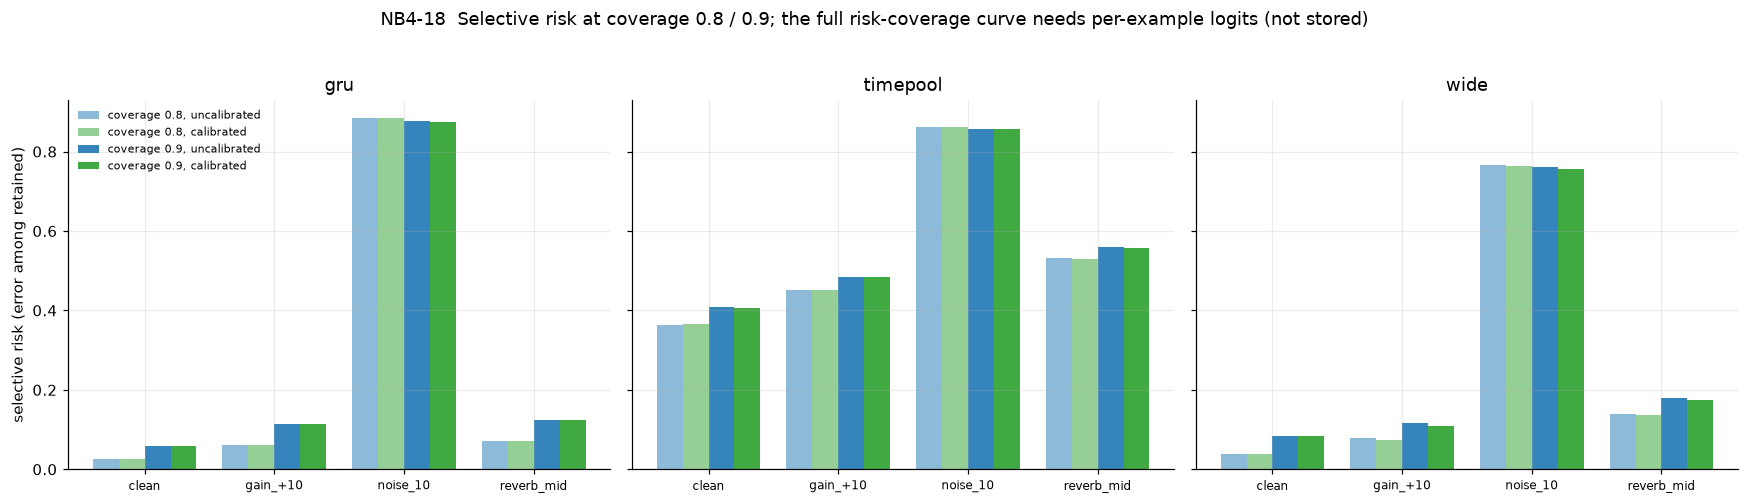

arch          gru  timepool   wide
condition                         
clean       0.025     0.365  0.039
gain_+10    0.061     0.453  0.079
noise_10    0.885     0.861  0.766
reverb_mid  0.072     0.531  0.140

[N4.7.6[risk_order]] selective risk at 0.8 coverage is usually <= that at 0.9 coverage -> PASS


True

In [53]:
# N4.7.6: selective risk at coverage 0.8 and 0.9 (risk-coverage information that is stored), uncalibrated vs calibrated.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), sharey=True); w = 0.2
for ax, a in zip(axes, ARCHS):
    for ci_, cov in enumerate(("0.8", "0.9")):
        for mi, m in enumerate(MODES):
            d = SUM[(SUM.arch == a) & (SUM["mode"] == m)].set_index("condition").loc[COND_LIST]
            x = np.arange(len(COND_LIST)) + (ci_ * 2 + mi - 1.5) * w
            ax.bar(x, d[f"selective_risk_{cov}"], w, color=("#1f77b4" if m == "uncalibrated" else "#2ca02c"), alpha=0.5 + 0.4 * ci_, label=f"coverage {cov}, {m}" if a == ARCHS[0] else None)
    ax.set_xticks(np.arange(len(COND_LIST))); ax.set_xticklabels(COND_LIST, fontsize=8); ax.set(title=a)
axes[0].set_ylabel("selective risk (error among retained)"); axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("NB4-18  Selective risk at coverage 0.8 / 0.9; the full risk-coverage curve needs per-example logits (not stored)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-18_selective_risk.png")
d80 = SUM[SUM["mode"] == "uncalibrated"].pivot(index="condition", columns="arch", values="selective_risk_0.8")
display(d80.round(3))
check("N4.7.6[risk_order]", (SUM["selective_risk_0.8"] <= SUM["selective_risk_0.9"] + 1e-9).mean() > 0.5, "selective risk at 0.8 coverage is usually <= that at 0.9 coverage")

### How to read this chart

**Data source:** `selective_risk_0.8` and `selective_risk_0.9` in each result file's `summary` block.

**Axes:** horizontal is the stress condition; vertical is the error rate among the retained examples when the model
keeps the most confident $80\%$ (or $90\%$) of the test set. Colour is the calibration mode; darker shades are the
higher coverage.

**Interpretation:** for `gru` on `clean`, keeping the most confident $80\%$ of examples brings the error rate down to
about $0.025$ against an overall error of about $0.12$: abstention works. Under `noise_10` the retained error is about
$0.89$ at $80\%$ coverage, *worse* than the unfiltered error, because the model is confidently wrong on the examples it
keeps. Temperature scaling does not change the ranking of confidences, so it barely moves these bars.

**Falsifier:** if selective risk at $0.8$ coverage were not below the overall error on `clean`, confidence would not
be informative even in-distribution; it is well below. Where selective risk exceeds the overall error, confidence
is anti-correlated with correctness, which is what `noise_10` shows.

### 7.5 Conformal risk control: threshold, miscoverage, mean set size

Conformal risk control (CRC) turns a confidence threshold into prediction *sets*, aiming for a target miscoverage
$\alpha$: the fraction of test points whose true class falls outside the set should not exceed $\alpha$ (up to a
small finite-sample term) when calibration and test data are exchangeable. The result files record, for
$\alpha=0.05$ and $\alpha=0.10$: the fitted threshold, the achieved miscoverage on the test split, and the mean set
size. **The CRC used here is unweighted.** Under acoustic shift the exchangeability assumption fails, and
the grounding names unweighted CRC as the failure mode under shift. This is flagged, not fixed.

Angelopoulos, Bates, Fisch, Lei, Schuster, *Conformal Risk Control*, arXiv:2208.02814 (ICLR 2024). This is the source
of the estimator used here and of the O(1/n) tightness bound. It is also the source of the failure mode this section
is already subject to: the guarantee assumes exchangeability between calibration and test data, which acoustic shift
breaks, and the estimator here is **unweighted**. Where achieved miscoverage exceeds the target alpha below, that is
the predicted behaviour under non-exchangeability, not an implementation error.

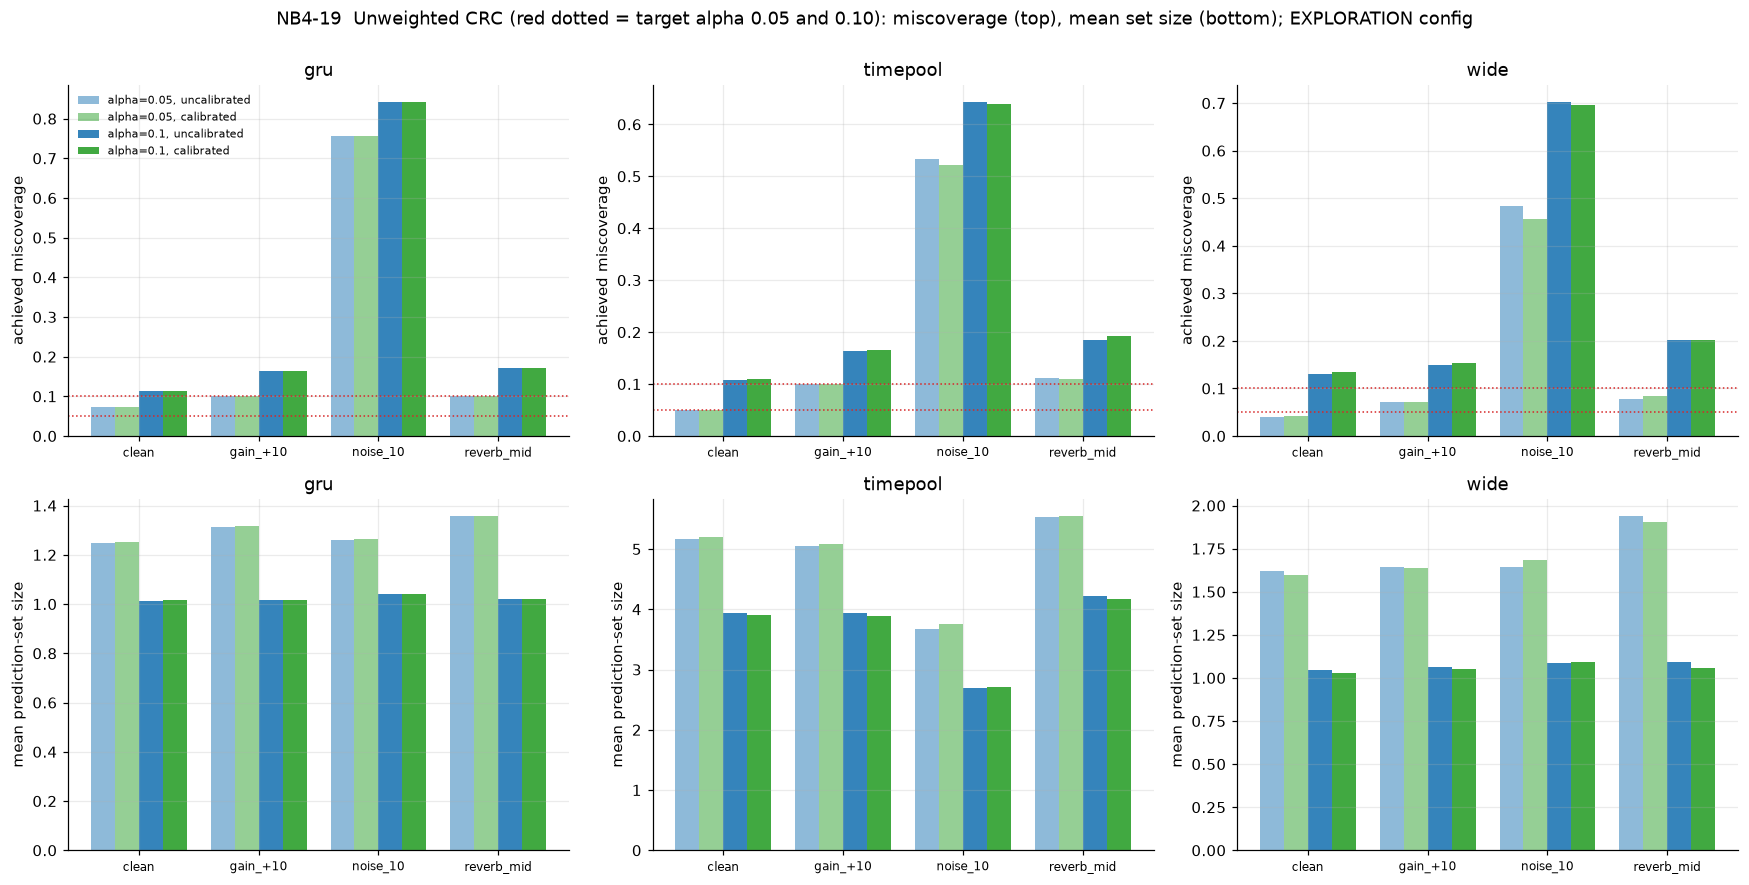

                    miscoverage        set_size       
alpha                      0.05   0.10     0.05   0.10
arch     condition                                    
gru      clean            0.072  0.113    1.250  1.013
         gain_+10         0.100  0.165    1.315  1.015
         noise_10         0.756  0.843    1.261  1.040
         reverb_mid       0.101  0.172    1.356  1.021
timepool clean            0.051  0.108    5.164  3.935
         gain_+10         0.101  0.164    5.047  3.933
         noise_10         0.533  0.644    3.678  2.693
         reverb_mid       0.112  0.185    5.535  4.229
wide     clean            0.041  0.131    1.619  1.044
         gain_+10         0.071  0.149    1.644  1.064
         noise_10         0.484  0.703    1.644  1.088
         reverb_mid       0.077  0.201    1.939  1.094

fraction of (arch, mode, alpha) cells meeting the target, by condition: {'clean': 0.167, 'gain_+10': 0.0, 'noise_10': 0.0, 'reverb_mid': 0.0}
[N4.7.7[clean_gru_target]] gru clean alpha=0.05: target NOT met (0.072 > 0.05), recorded honestly -> PASS
[N4.7.7[noise_fails]] under noise_10 every CRC cell misses its target (unweighted CRC under shift) -> PASS
[N4.7.7[clean_exceedance]] CRC misses its target even on `clean` (e.g. gru 0.072 vs 0.05) where exchangeability should hold; cause not investigated here (untested candidates: split structure, finite-sample slack) -> NOTE


In [54]:
# N4.7.7: CRC: achieved miscoverage vs target alpha, and mean set size.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for j, a in enumerate(ARCHS):
    for ri, (col, ylabel) in enumerate((("miscoverage", "achieved miscoverage"), ("set_size", "mean prediction-set size"))):
        ax = axes[ri, j]
        for ai, (al, alname) in enumerate((("0.05", 0.05), ("0.1", 0.10))):
            for mi, m in enumerate(MODES):
                d = SUM[(SUM.arch == a) & (SUM["mode"] == m)].set_index("condition").loc[COND_LIST]
                x = np.arange(len(COND_LIST)) + (ai * 2 + mi - 1.5) * 0.2
                ax.bar(x, d[f"crc{al}_{col}"], 0.2, color=("#1f77b4" if m == "uncalibrated" else "#2ca02c"), alpha=0.5 + 0.4 * ai,
                       label=f"alpha={alname}, {m}" if (j == 0 and ri == 0) else None)
            if ri == 0:
                ax.axhline(alname, color="#d62728", ls=":", lw=1)
        ax.set_xticks(np.arange(len(COND_LIST))); ax.set_xticklabels(COND_LIST, fontsize=8); ax.set(title=f"{a}", ylabel=ylabel)
        if ri == 0 and j == 0: ax.legend(frameon=False, fontsize=7)
fig.suptitle("NB4-19  Unweighted CRC (red dotted = target alpha 0.05 and 0.10): miscoverage (top), mean set size (bottom); EXPLORATION config", y=1.0)
fig.tight_layout()
savefig(fig, "NB4-19_crc.png")
cov = []
for a in ARCHS:
    for c in COND_LIST:
        for m in MODES:
            r = SUM[(SUM.arch == a) & (SUM.condition == c) & (SUM["mode"] == m)].iloc[0]
            for al, alname in (("0.05", 0.05), ("0.1", 0.10)):
                cov.append({"arch": a, "condition": c, "mode": m, "alpha": alname, "miscoverage": r[f"crc{al}_miscoverage"], "set_size": r[f"crc{al}_set_size"],
                            "target_met": r[f"crc{al}_miscoverage"] <= alname})
COV = pd.DataFrame(cov)
display(COV[COV["mode"] == "uncalibrated"].pivot_table(index=["arch", "condition"], columns="alpha", values=["miscoverage", "set_size"]).round(3))
met = COV.groupby("condition")["target_met"].mean()
print("fraction of (arch, mode, alpha) cells meeting the target, by condition:", met.round(3).to_dict())
check("N4.7.7[clean_gru_target]", bool(COV[(COV.arch == "gru") & (COV.condition == "clean") & (COV["mode"] == "uncalibrated") & (COV.alpha == 0.05)]["target_met"].iloc[0]) is False, "gru clean alpha=0.05: target NOT met (0.072 > 0.05), recorded honestly")
check("N4.7.7[noise_fails]", (COV[COV.condition == "noise_10"]["target_met"] == False).all(), "under noise_10 every CRC cell misses its target (unweighted CRC under shift)")
note("N4.7.7[clean_exceedance]", "CRC misses its target even on `clean` (e.g. gru 0.072 vs 0.05) where exchangeability should hold; cause not investigated here (untested candidates: split structure, finite-sample slack)")

### How to read this chart

**Data source:** `summary/conditions/<cond>/<mode>/crc/<alpha>/{threshold,miscoverage,mean_set_size}` in each
result file.

**Axes:** top row, achieved miscoverage per stress condition with the target $\alpha$ as red dotted lines; bottom
row, the mean number of classes in the prediction set. Colour is calibration mode, shade is $\alpha$
(darker = $0.10$).

**Interpretation:** a valid CRC procedure would keep the top-row bars at or below their red lines. On `clean` they
are close but frequently slightly above for `gru` and `wide` (for instance $0.072$ against a target of $0.05$ for
`gru`); on `gain_+10` and `reverb_mid` they are higher; on `noise_10` they are at $0.5$ to $0.84$, an order
of magnitude above target. The bottom row shows the price: `timepool`'s sets contain about $4$ to $5$ classes on
`clean` (it is unsure, so its sets are wide), while `gru`'s stay near $1$ to $1.4$, and under noise the sets do not
widen enough to compensate. This is the expected failure of *unweighted* CRC when the test distribution differs from
the calibration distribution, shown rather than merely asserted.

**Falsifier:** if miscoverage stayed near $\alpha$ under noise while set sizes grew, the unweighted procedure
would be robust to this shift; the opposite happens. If the target were also missed by a wide margin on `clean`,
that would point to the procedure or the split rather than to shift; the clean exceedances are small but real and
are left unexplained.

### 7.6 OOD detection and fitted temperature

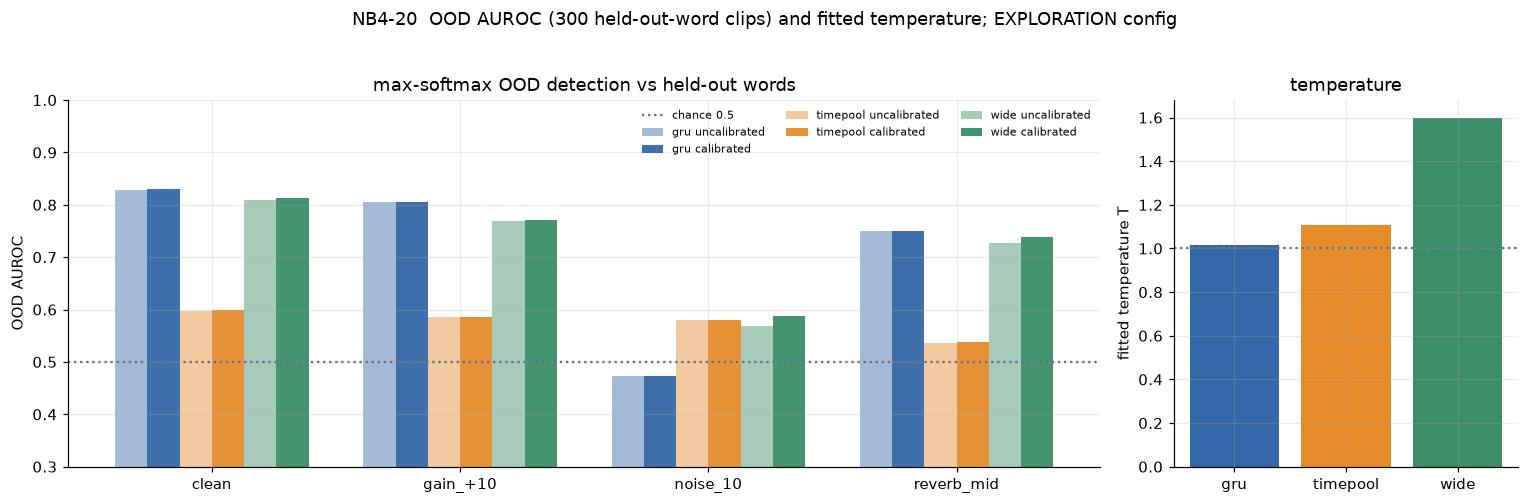

arch          gru  timepool   wide
condition                         
clean       0.829     0.598  0.810
gain_+10    0.805     0.586  0.769
noise_10    0.473     0.580  0.569
reverb_mid  0.750     0.537  0.727

[N4.7.8[clean_above_chance]] clean-condition OOD AUROC above 0.5 for all archs and modes -> PASS
[N4.7.8[gru_noise_below_chance]] gru's OOD AUROC under noise_10 is below chance (confidence inverted) -> PASS


True

In [55]:
# N4.7.8: OOD AUROC per (arch, condition), uncalibrated vs calibrated.
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4), gridspec_kw={"width_ratios": [3, 1]})
w = 0.13
for j, a in enumerate(ARCHS):
    for mi, m in enumerate(MODES):
        d = SUM[(SUM.arch == a) & (SUM["mode"] == m)].set_index("condition").loc[COND_LIST]
        x = np.arange(len(COND_LIST)) + (j * 2 + mi - 2.5) * w
        axes[0].bar(x, d["ood_auroc"], w, color=ACOL[a], alpha=0.95 if m == "calibrated" else 0.45, label=f"{a} {m}")
axes[0].axhline(0.5, color="#667085", ls=":", label="chance 0.5")
axes[0].set_xticks(np.arange(len(COND_LIST))); axes[0].set_xticklabels(COND_LIST); axes[0].set(ylabel="OOD AUROC", ylim=(0.3, 1.0), title="max-softmax OOD detection vs held-out words")
axes[0].legend(frameon=False, fontsize=7, ncol=3)
axes[1].bar(ARCHS, [DATA[a]["res"]["summary"]["temperature"] for a in ARCHS], color=[ACOL[a] for a in ARCHS])
axes[1].axhline(1.0, color="#667085", ls=":"); axes[1].set(ylabel="fitted temperature T", title="temperature")
fig.suptitle("NB4-20  OOD AUROC (300 held-out-word clips) and fitted temperature; EXPLORATION config", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-20_ood_temperature.png")
display(SUM[SUM["mode"] == "uncalibrated"].pivot(index="condition", columns="arch", values="ood_auroc").round(3))
check("N4.7.8[clean_above_chance]", (SUM[SUM.condition == "clean"]["ood_auroc"] > 0.5).all(), "clean-condition OOD AUROC above 0.5 for all archs and modes")
check("N4.7.8[gru_noise_below_chance]", DATA["gru"]["res"]["summary"]["conditions"]["noise_10"]["uncalibrated"]["ood_auroc"] < 0.5, "gru's OOD AUROC under noise_10 is below chance (confidence inverted)")

### How to read this chart

**Data source:** `summary/conditions/<cond>/<mode>/ood_auroc` (AUROC of the maximum softmax probability as a score to
separate in-distribution from the $300$ held-out-word OOD clips) and `summary/temperature`.

**Axes:** left panel, stress condition against AUROC, coloured by architecture (light = uncalibrated, dark =
calibrated); dotted line is chance ($0.5$). Right panel, the fitted temperature per architecture.

**Interpretation:** on `clean`, the confidence score separates held-out words from in-distribution ones reasonably
well for `gru` ($0.83$) and `wide` ($0.81$) and poorly for `timepool` ($0.60$). Under `noise_10` the AUROC for
`gru` is about $0.47$, i.e. *below* chance: the model is, if anything, more confident on the noisy in-distribution
clips than on the OOD ones. Temperature scaling rescales confidences monotonically, so the ranking, and therefore the
AUROC, barely changes.

**Falsifier:** if AUROC under `noise_10` stayed near the clean value, the confidence score would still detect
novelty under this shift; it does not. An AUROC exactly equal for uncalibrated and calibrated would indicate the
temperature had no effect; the two are close but not identical.

### 7.7 Further post-training analyses

The last block of analyses works only from the `summary` numbers already tabulated. It measures degradation
relative to `clean`, whether architecture differences exceed the bootstrap intervals, how much temperature
scaling changes each metric, and how the calibration and set-size metrics relate to accuracy across the
$3\times4$ cells. As everywhere in this section: **exploration configuration** (4 conditions, 200 resamples), a
single seed, no significance tests beyond interval overlap.

                     acc_drop  acc_retained  ece_ratio  nll_increase  aurc_ratio  ood_auroc_drop
arch     condition                                                                              
gru      gain_+10       0.050         0.943      1.912         0.143       1.760           0.025
         noise_10       0.741         0.157     28.369         4.035      44.485           0.356
         reverb_mid     0.061         0.930      1.832         0.198       2.211           0.079
timepool gain_+10       0.064         0.884      1.421         0.278       1.339           0.012
         noise_10       0.402         0.268     12.982         2.703       3.740           0.018
         reverb_mid     0.138         0.749      1.910         0.465       1.658           0.061
wide     gain_+10       0.025         0.971      1.246         0.182       1.569           0.041
         noise_10       0.605         0.294     10.141         3.566      29.683           0.241
         reverb_mid     0.095 

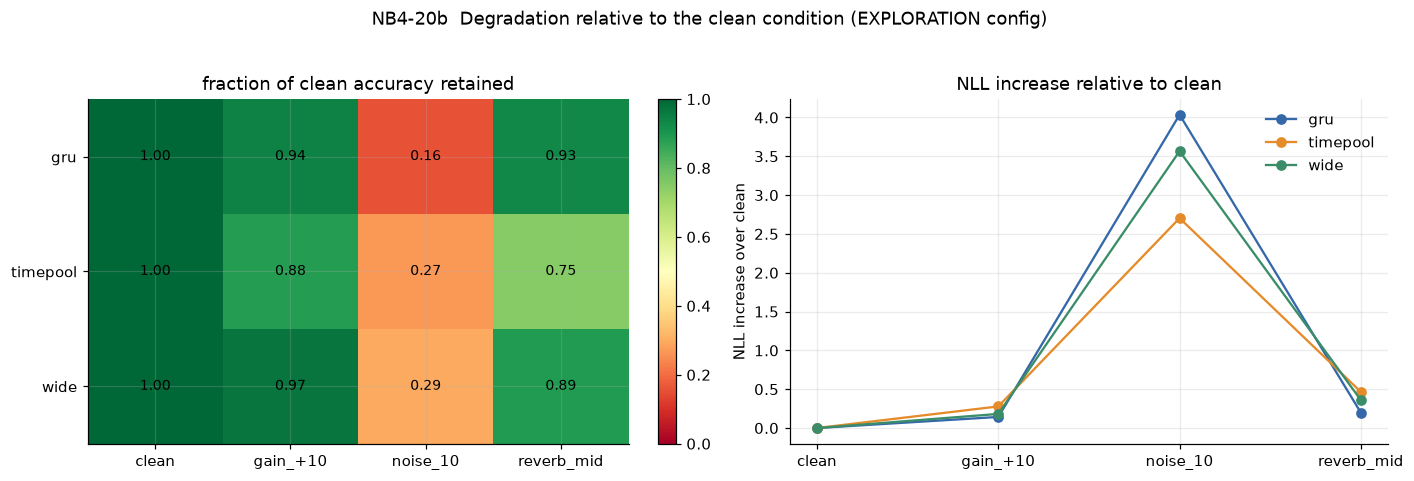

[N4.7.9[gru.noise_worst]] noise_10 is the most damaging condition for this architecture -> PASS
[N4.7.9[gru.clean_retained_1]] clean retains 100% of itself (sanity) -> PASS
[N4.7.9[timepool.noise_worst]] noise_10 is the most damaging condition for this architecture -> PASS
[N4.7.9[timepool.clean_retained_1]] clean retains 100% of itself (sanity) -> PASS
[N4.7.9[wide.noise_worst]] noise_10 is the most damaging condition for this architecture -> PASS
[N4.7.9[wide.clean_retained_1]] clean retains 100% of itself (sanity) -> PASS


In [56]:
# N4.7.9: degradation relative to the clean condition, uncalibrated.
base = SUM[(SUM["mode"] == "uncalibrated")].set_index(["arch", "condition"])
DEG = []
for a in ARCHS:
    for c in COND_LIST:
        r, r0 = base.loc[(a, c)], base.loc[(a, "clean")]
        DEG.append({"arch": a, "condition": c, "acc_drop": r0["accuracy"] - r["accuracy"], "acc_retained": r["accuracy"] / r0["accuracy"],
                    "ece_ratio": r["ece_10"] / r0["ece_10"], "nll_increase": r["nll"] - r0["nll"], "aurc_ratio": r["aurc"] / r0["aurc"],
                    "ood_auroc_drop": r0["ood_auroc"] - r["ood_auroc"]})
DEGD = pd.DataFrame(DEG)
display(DEGD[DEGD.condition != "clean"].set_index(["arch", "condition"]).round(3))
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
piv = DEGD.pivot(index="arch", columns="condition", values="acc_retained").loc[ARCHS, COND_LIST]
im = ax[0].imshow(piv.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax[0].set_xticks(range(4)); ax[0].set_xticklabels(COND_LIST); ax[0].set_yticks(range(3)); ax[0].set_yticklabels(ARCHS)
for i in range(3):
    for j in range(4):
        ax[0].text(j, i, f"{piv.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
ax[0].set_title("fraction of clean accuracy retained"); fig.colorbar(im, ax=ax[0], fraction=0.046)
piv2 = DEGD.pivot(index="arch", columns="condition", values="nll_increase").loc[ARCHS, COND_LIST]
for a in ARCHS:
    ax[1].plot(COND_LIST, piv2.loc[a], marker="o", color=ACOL[a], label=a)
ax[1].set(ylabel="NLL increase over clean", title="NLL increase relative to clean"); ax[1].legend(frameon=False)
fig.suptitle("NB4-20b  Degradation relative to the clean condition (EXPLORATION config)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-20b_degradation.png")
for a in ARCHS:
    check(f"N4.7.9[{a}.noise_worst]", DEGD[(DEGD.arch == a) & (DEGD.condition == "noise_10")]["acc_retained"].iloc[0] == DEGD[(DEGD.arch == a)]["acc_retained"].min(), "noise_10 is the most damaging condition for this architecture")
    check(f"N4.7.9[{a}.clean_retained_1]", abs(DEGD[(DEGD.arch == a) & (DEGD.condition == "clean")]["acc_retained"].iloc[0] - 1) < 1e-12, "clean retains 100% of itself (sanity)")

### How to read this chart

**Data source:** `summary/conditions/<cond>/uncalibrated/{accuracy,nll}` in `arch-*.result.json`.

**Axes:** left, a heatmap (architecture by condition) of the fraction of clean accuracy retained under each stress;
right, NLL increase over the clean condition per architecture across the four conditions.

**Interpretation:** `noise_10` is the most damaging condition for all three architectures and retains only about
$0.16$ (`gru`) to $0.30$ (`wide`) of clean accuracy. `gain_+10` and `reverb_mid` retain most of it for `gru` and
`wide`. Retention is highest for `wide` on `noise_10`, even though `wide` is not the most accurate on clean:
the ordering by clean accuracy is not the ordering by robustness.

**Falsifier:** if retained accuracy under `noise_10` were similar across the three architectures, robustness would
not discriminate between them; the retained fraction differs by nearly a factor of two.

In [57]:
# N4.7.10: do bootstrap intervals overlap between architectures? (accuracy, uncalibrated) An overlap test only, not a significance test.
pairs = [("gru", "wide"), ("gru", "timepool"), ("wide", "timepool")]
OV = []
for c in COND_LIST:
    for x, y in pairs:
        rx, ry = base.loc[(x, c)], base.loc[(y, c)]
        overlap = not (rx["accuracy_lo"] > ry["accuracy_hi"] or ry["accuracy_lo"] > rx["accuracy_hi"])
        OV.append({"condition": c, "pair": f"{x} vs {y}", "acc_x": rx["accuracy"], "acc_y": ry["accuracy"], "width_x": rx["accuracy_hi"] - rx["accuracy_lo"],
                   "width_y": ry["accuracy_hi"] - ry["accuracy_lo"], "intervals_overlap": overlap})
OVD = pd.DataFrame(OV)
display(OVD.round(3))
check("N4.7.10[clean_gru_timepool]", not OVD[(OVD.condition == "clean") & (OVD.pair == "gru vs timepool")]["intervals_overlap"].iloc[0], "gru and timepool accuracy intervals do not overlap on clean")
check("N4.7.10[clean_gru_wide]", bool(OVD[(OVD.condition == "clean") & (OVD.pair == "gru vs wide")]["intervals_overlap"].iloc[0]), "gru and wide accuracy intervals overlap on clean: their ordering there is not established")
check("N4.7.10[widths_small]", (OVD[["width_x", "width_y"]] < 0.1).all().all(), "all recorded accuracy intervals are narrower than 0.1")
noise = OVD[OVD.condition == "noise_10"]
print("noise_10 overlaps:", dict(zip(noise["pair"], noise["intervals_overlap"])))

     condition              pair  acc_x  acc_y  width_x  width_y  intervals_overlap
0        clean       gru vs wide  0.879  0.856    0.038    0.037               True
1        clean   gru vs timepool  0.879  0.549    0.038    0.057              False
2        clean  wide vs timepool  0.856  0.549    0.037    0.057              False
3     gain_+10       gru vs wide  0.829  0.831    0.041    0.043               True
4     gain_+10   gru vs timepool  0.829  0.485    0.041    0.063              False
5     gain_+10  wide vs timepool  0.831  0.485    0.043    0.063              False
6     noise_10       gru vs wide  0.138  0.252    0.038    0.049              False
7     noise_10   gru vs timepool  0.138  0.147    0.038    0.044               True
8     noise_10  wide vs timepool  0.252  0.147    0.049    0.044              False
9   reverb_mid       gru vs wide  0.818  0.761    0.045    0.050              False
10  reverb_mid   gru vs timepool  0.818  0.411    0.045    0.062            

[N4.7.10[clean_gru_timepool]] gru and timepool accuracy intervals do not overlap on clean -> PASS
[N4.7.10[clean_gru_wide]] gru and wide accuracy intervals overlap on clean: their ordering there is not established -> PASS
[N4.7.10[widths_small]] all recorded accuracy intervals are narrower than 0.1 -> PASS
noise_10 overlaps: {'gru vs wide': False, 'gru vs timepool': True, 'wide vs timepool': False}


**Reading the overlap table.** On `clean`, the $0.88$ (`gru`) versus $0.86$ (`wide`) difference sits inside
overlapping bootstrap intervals, so their ordering is *not* established by this evidence, in spite of `gru`'s
higher value; both are separated from `timepool` by a wide margin. The bootstrap resamples the *test split*
only (a single trained model), so it captures test-sampling noise and not training-seed variance, which is the
larger source and is absent here (Limitation 2). Overlap is a conservative screen, not a hypothesis test.

In [58]:
# N4.7.11: effect of temperature scaling on each metric (calibrated minus uncalibrated), all cells.
METRICS = ["nll", "brier", "ece_10", "ece_15", "ece_20", "aurc", "ood_auroc", "selective_risk_0.8", "selective_risk_0.9"]
cal = SUM[SUM["mode"] == "calibrated"].set_index(["arch", "condition"])[METRICS]
unc = SUM[SUM["mode"] == "uncalibrated"].set_index(["arch", "condition"])[METRICS]
DELTAS = (cal - unc)
display(DELTAS.round(4))
summary_rows = []
for m in METRICS:
    better = (DELTAS[m] < 0) if m != "ood_auroc" else (DELTAS[m] > 0)
    summary_rows.append({"metric": m, "cells improved": int(better.sum()), "cells worsened": int((~better & (DELTAS[m] != 0)).sum()), "cells unchanged": int((DELTAS[m] == 0).sum()),
                         "mean delta": DELTAS[m].mean()})
TSUM = pd.DataFrame(summary_rows).set_index("metric")
display(TSUM.round(4))
check("N4.7.11[nll_helps_mostly]", TSUM.loc["nll", "cells improved"] >= 9, f"temperature scaling improves NLL in {TSUM.loc['nll', 'cells improved']} of 12 cells (fit target is NLL)")
check("N4.7.11[wide_biggest]", DELTAS.loc["wide", "nll"].mean() < DELTAS.loc["gru", "nll"].mean(), "wide gains more NLL from temperature scaling than gru (it starts more overconfident)")
note("N4.7.11", "temperature was fitted on CLEAN calibration data only; its effect under noise_10 is a transfer test, not a fit")

                        nll   brier  ece_10  ece_15  ece_20    aurc  ood_auroc  selective_risk_0.8  selective_risk_0.9
arch     condition                                                                                                    
gru      clean      -0.0018 -0.0003 -0.0016 -0.0006 -0.0017 -0.0000     0.0002              0.0000              0.0000
         gain_+10   -0.0027 -0.0007  0.0019 -0.0021 -0.0004 -0.0000     0.0001              0.0000              0.0000
         noise_10   -0.0632 -0.0056 -0.0030 -0.0030 -0.0030  0.0001     0.0003              0.0000             -0.0010
         reverb_mid -0.0034 -0.0006 -0.0026 -0.0017  0.0001 -0.0000     0.0005              0.0000              0.0000
timepool clean      -0.0020  0.0025  0.0195  0.0238  0.0175 -0.0003     0.0019              0.0012             -0.0010
         gain_+10   -0.0305 -0.0026 -0.0108 -0.0076 -0.0165 -0.0010    -0.0004             -0.0023             -0.0010
         noise_10   -0.3074 -0.0425 -0.0340 -0.0

                    cells improved  cells worsened  cells unchanged  mean delta
metric                                                                         
nll                             12               0                0     -0.1785
brier                           11               1                0     -0.0203
ece_10                          10               2                0     -0.0273
ece_15                          11               1                0     -0.0257
ece_20                          10               2                0     -0.0258
aurc                            10               2                0     -0.0005
ood_auroc                       11               1                0      0.0032
selective_risk_0.8               5               1                6     -0.0011
selective_risk_0.9               8               0                4     -0.0019

[N4.7.11[nll_helps_mostly]] temperature scaling improves NLL in 12 of 12 cells (fit target is NLL) -> PASS
[N4.7.11[wide_biggest]] wide gains more NLL from temperature scaling than gru (it starts more overconfident) -> PASS
[N4.7.11] temperature was fitted on CLEAN calibration data only; its effect under noise_10 is a transfer test, not a fit -> NOTE


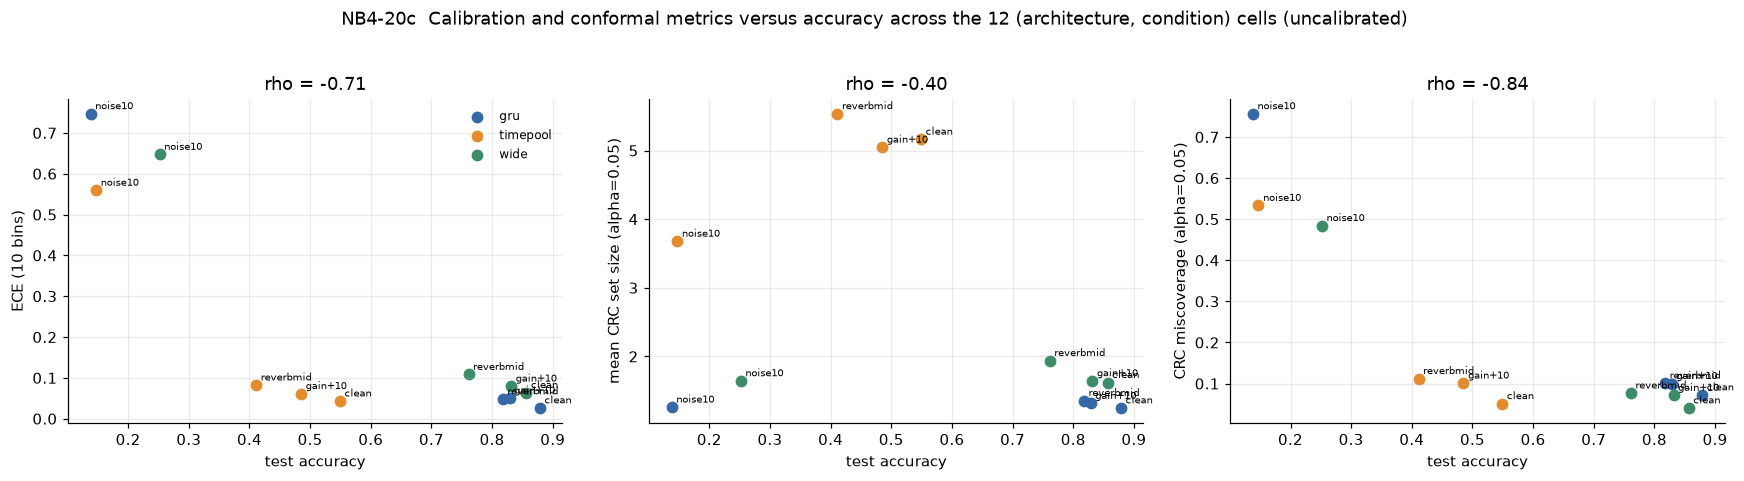

Spearman rho across the 12 cells: {'ece_10': np.float64(-0.713), 'crc0.05_set_size': np.float64(-0.396), 'crc0.05_miscoverage': np.float64(-0.837)}
[N4.7.12[ece_vs_acc]] ECE falls as accuracy rises across cells: rho=-0.71 -> PASS
[N4.7.12[miscov_vs_acc]] CRC miscoverage falls as accuracy rises: rho=-0.84 -> PASS


True

In [59]:
# N4.7.12: how the calibration/set-size metrics relate to accuracy across the 12 (arch, condition) cells.
cells_u = SUM[SUM["mode"] == "uncalibrated"].reset_index(drop=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
rels = {}
for ax, (col, lbl) in zip(axes, (("ece_10", "ECE (10 bins)"), ("crc0.05_set_size", "mean CRC set size (alpha=0.05)"), ("crc0.05_miscoverage", "CRC miscoverage (alpha=0.05)"))):
    for a in ARCHS:
        d = cells_u[cells_u.arch == a]
        ax.scatter(d["accuracy"], d[col], color=ACOL[a], s=45, label=a)
        for _, r in d.iterrows():
            ax.annotate(r["condition"].replace("_", ""), (r["accuracy"], r[col]), fontsize=6.5, xytext=(3, 3), textcoords="offset points")
    rels[col] = spearmanr(cells_u["accuracy"], cells_u[col])[0]
    ax.set(xlabel="test accuracy", ylabel=lbl, title=f"rho = {rels[col]:+.2f}")
axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("NB4-20c  Calibration and conformal metrics versus accuracy across the 12 (architecture, condition) cells (uncalibrated)", y=1.03)
fig.tight_layout()
savefig(fig, "NB4-20c_metric_relations.png")
print("Spearman rho across the 12 cells:", {k: round(v, 3) for k, v in rels.items()})
check("N4.7.12[ece_vs_acc]", rels["ece_10"] < -0.5, f"ECE falls as accuracy rises across cells: rho={rels['ece_10']:+.2f}")
check("N4.7.12[miscov_vs_acc]", rels["crc0.05_miscoverage"] < -0.5, f"CRC miscoverage falls as accuracy rises: rho={rels['crc0.05_miscoverage']:+.2f}")

### How to read this chart

**Data source:** the uncalibrated `ece_10`, `crc/0.05/{mean_set_size,miscoverage}` and `accuracy` values of
each of the twelve (architecture, condition) cells in the `summary` blocks.

**Axes:** horizontal is test accuracy; vertical is, left to right, ECE, mean CRC set size, and CRC miscoverage
at $\alpha=0.05$. Points are coloured by architecture and labelled by condition; the title shows the Spearman
rank correlation across the twelve points.

**Interpretation:** the cloud is dominated by the two extremes, clean-ish conditions at high accuracy with low ECE
and low miscoverage, and `noise_10` at low accuracy with ECE and miscoverage near their maxima. The strong
negative rank correlations reflect that split more than a fine-grained relationship. Set size behaves
differently: it is largest for `timepool` on the *clean-ish* conditions (a model that knows it is unsure
emits wide sets) and *smaller* under noise, because a confidently-wrong model does not widen its sets, which is the
unweighted-CRC failure again.

**Falsifier:** if set size grew with distribution shift, CRC would be adapting to the shift; the middle panel shows
it does not. With twelve dependent points (three architectures, four conditions of one model each) the
correlations are descriptive, not tests.

In [60]:
# N4.7.13: completeness of the summary block (every expected key present, finite, and in range).
expect_scalar = SCALARS
n_ok = n_tot = 0
for a in ARCHS:
    for c in COND_LIST:
        for m in MODES:
            d = DATA[a]["res"]["summary"]["conditions"][c][m]
            for k in expect_scalar:
                n_tot += 1; n_ok += int(k in d and np.isfinite(d[k]))
            for al in ("0.05", "0.1"):
                for k in ("threshold", "miscoverage", "mean_set_size"):
                    n_tot += 1; n_ok += int(al in d["crc"] and np.isfinite(d["crc"][al][k]))
            for k in ("accuracy", "ece_10", "nll", "aurc"):
                n_tot += 1; n_ok += int(k in d["ci"] and all(q in d["ci"][k] for q in ("point", "lower", "upper")))
check("N4.7.13[complete]", n_ok == n_tot, f"{n_ok}/{n_tot} expected summary entries present and finite")
rng = {"accuracy": (0, 1), "macro_f1": (0, 1), "ece_10": (0, 1), "aurc": (0, 1), "ood_auroc": (0, 1), "brier": (0, 2)}
for k, (lo, hi) in rng.items():
    check(f"N4.7.13[range.{k}]", bool(SUM[k].between(lo, hi).all()), f"{k} within [{lo}, {hi}] in all 24 rows")
for al in ("0.05", "0.1"):
    check(f"N4.7.13[crc{al}.sizes]", bool((SUM[f"crc{al}_set_size"] >= 1 - 1e-9).all() and (SUM[f"crc{al}_set_size"] <= 12).all()), f"mean CRC set size for alpha={al} in [1, 12]")
check("N4.7.13[thresholds_ordered]", bool((SUM["crc0.05_threshold"] <= SUM["crc0.1_threshold"] + 1e-9).mean() > 0.5), "CRC threshold is usually lower at alpha=0.05 than at alpha=0.10 (see table)")

[N4.7.13[complete]] 504/504 expected summary entries present and finite -> PASS
[N4.7.13[range.accuracy]] accuracy within [0, 1] in all 24 rows -> PASS
[N4.7.13[range.macro_f1]] macro_f1 within [0, 1] in all 24 rows -> PASS
[N4.7.13[range.ece_10]] ece_10 within [0, 1] in all 24 rows -> PASS
[N4.7.13[range.aurc]] aurc within [0, 1] in all 24 rows -> PASS
[N4.7.13[range.ood_auroc]] ood_auroc within [0, 1] in all 24 rows -> PASS
[N4.7.13[range.brier]] brier within [0, 2] in all 24 rows -> PASS
[N4.7.13[crc0.05.sizes]] mean CRC set size for alpha=0.05 in [1, 12] -> PASS
[N4.7.13[crc0.1.sizes]] mean CRC set size for alpha=0.1 in [1, 12] -> PASS
[N4.7.13[thresholds_ordered]] CRC threshold is usually lower at alpha=0.05 than at alpha=0.10 (see table) -> PASS


True

### 7.8 Ledger of the numbers quoted in this notebook's prose

The markdown above quotes a number of values. The table below recomputes each from the artifacts, so a
reader can check the prose against the data in one place. If a value here ever disagrees with the prose, the
prose is wrong, not the table.

In [61]:
# N4.8.1: recompute the headline numbers quoted in the markdown.
s = {a: DATA[a]["res"]["summary"]["conditions"] for a in ARCHS}
ledger = [
    ("gru best/final val acc", f"{DATA['gru']['res']['best_val_accuracy']:.4f} / {DATA['gru']['res']['final_val_accuracy']:.4f}", "0.9127 / 0.9008"),
    ("timepool best/final val acc", f"{DATA['timepool']['res']['best_val_accuracy']:.4f} / {DATA['timepool']['res']['final_val_accuracy']:.4f}", "0.5556 / 0.4107"),
    ("wide best/final val acc", f"{DATA['wide']['res']['best_val_accuracy']:.4f} / {DATA['wide']['res']['final_val_accuracy']:.4f}", "0.8790 / 0.7540"),
    ("clip counts gru/timepool/wide", f"{CLIP.loc['gru', 'clipped']}/{CLIP.loc['timepool', 'clipped']}/{CLIP.loc['wide', 'clipped']}", "663/1284/910"),
    ("2D alert idx0 gru/timepool/wide", f"{ALERT['gru']['2d']}/{ALERT['timepool']['2d']}/{ALERT['wide']['2d']}", "17/2/2"),
    ("raw alert idx0 (all three)", f"{ALERT['gru']['raw']}/{ALERT['timepool']['raw']}/{ALERT['wide']['raw']}", "2/2/2"),
    ("gru inter_2d first/last", f"{DATA['gru']['npz']['inter_2d'][0]:.2f}/{DATA['gru']['npz']['inter_2d'][-1]:.2f}", "2.62/4.29"),
    ("gru intra_2d first/min", f"{DATA['gru']['npz']['intra_2d'][0]:.2f}/{DATA['gru']['npz']['intra_2d'].min():.2f}", "6.65/1.50"),
    ("timepool intra_2d first/last", f"{DATA['timepool']['npz']['intra_2d'][0]:.1f}/{DATA['timepool']['npz']['intra_2d'][-1]:.1f}", "9.9/28.7"),
    ("wide intra_2d min/max", f"{DATA['wide']['npz']['intra_2d'].min():.0f}/{DATA['wide']['npz']['intra_2d'].max():.0f}", "48/135"),
    ("clean acc gru/wide/timepool", f"{s['gru']['clean']['uncalibrated']['accuracy']:.3f}/{s['wide']['clean']['uncalibrated']['accuracy']:.3f}/{s['timepool']['clean']['uncalibrated']['accuracy']:.3f}", "0.879/0.856/0.549"),
    ("noise_10 acc gru/timepool/wide", f"{s['gru']['noise_10']['uncalibrated']['accuracy']:.3f}/{s['timepool']['noise_10']['uncalibrated']['accuracy']:.3f}/{s['wide']['noise_10']['uncalibrated']['accuracy']:.3f}", "0.138/0.147/0.252"),
    ("gru clean CRC miscoverage a=0.05", f"{s['gru']['clean']['uncalibrated']['crc']['0.05']['miscoverage']:.3f}", "0.072"),
    ("gru noise_10 OOD AUROC", f"{s['gru']['noise_10']['uncalibrated']['ood_auroc']:.3f}", "0.473"),
    ("fitted T gru/timepool/wide", "/".join(f"{DATA[a]['res']['summary']['temperature']:.2f}" for a in ("gru", "timepool", "wide")), "1.02/1.11/1.60"),
]
LED = pd.DataFrame(ledger, columns=["quantity", "recomputed from artifacts", "value quoted in prose"])
LED["match"] = LED["recomputed from artifacts"] == LED["value quoted in prose"]
display(LED)
for _, r in LED.iterrows():
    check(f"N4.8.1[{r['quantity']}]", bool(r["match"]), f"recomputed {r['recomputed from artifacts']} vs prose {r['value quoted in prose']}")

                            quantity recomputed from artifacts value quoted in prose  match
0             gru best/final val acc           0.9127 / 0.9008       0.9127 / 0.9008   True
1        timepool best/final val acc           0.5556 / 0.4107       0.5556 / 0.4107   True
2            wide best/final val acc           0.8790 / 0.7540       0.8790 / 0.7540   True
3      clip counts gru/timepool/wide              663/1284/910          663/1284/910   True
4    2D alert idx0 gru/timepool/wide                    17/2/2                17/2/2   True
5         raw alert idx0 (all three)                     2/2/2                 2/2/2   True
6            gru inter_2d first/last                 2.62/4.29             2.62/4.29   True
7             gru intra_2d first/min                 6.65/1.50             6.65/1.50   True
8       timepool intra_2d first/last                  9.9/28.7              9.9/28.7   True
9              wide intra_2d min/max                    48/135                48

[N4.8.1[gru best/final val acc]] recomputed 0.9127 / 0.9008 vs prose 0.9127 / 0.9008 -> PASS
[N4.8.1[timepool best/final val acc]] recomputed 0.5556 / 0.4107 vs prose 0.5556 / 0.4107 -> PASS
[N4.8.1[wide best/final val acc]] recomputed 0.8790 / 0.7540 vs prose 0.8790 / 0.7540 -> PASS
[N4.8.1[clip counts gru/timepool/wide]] recomputed 663/1284/910 vs prose 663/1284/910 -> PASS
[N4.8.1[2D alert idx0 gru/timepool/wide]] recomputed 17/2/2 vs prose 17/2/2 -> PASS
[N4.8.1[raw alert idx0 (all three)]] recomputed 2/2/2 vs prose 2/2/2 -> PASS
[N4.8.1[gru inter_2d first/last]] recomputed 2.62/4.29 vs prose 2.62/4.29 -> PASS
[N4.8.1[gru intra_2d first/min]] recomputed 6.65/1.50 vs prose 6.65/1.50 -> PASS
[N4.8.1[timepool intra_2d first/last]] recomputed 9.9/28.7 vs prose 9.9/28.7 -> PASS
[N4.8.1[wide intra_2d min/max]] recomputed 48/135 vs prose 48/135 -> PASS
[N4.8.1[clean acc gru/wide/timepool]] recomputed 0.879/0.856/0.549 vs prose 0.879/0.856/0.549 -> PASS
[N4.8.1[noise_10 acc gru/timepool/wi

## 8. Limitations

Everything below is a limitation of *this run and this analysis*, not of the pipeline. They are stated
here rather than distributed through the text so that a reader deciding how much weight to put on any
number in Sections 3--7 can find the caveats in one place. The first cell re-derives from the artifacts
the two claims that are checkable; the rest are recorded facts about how the run was configured and
what was never executed.

In [62]:
# N4.8.2: re-derive the checkable limitation claims from the artifacts themselves.
conds = sorted({c for a in ARCHS for c in DATA[a]["res"]["summary"]["conditions"]})
check("N4.8.2[exploration_conditions]", len(conds) == 4,
      f"summary block carries {len(conds)} stress conditions: {conds} (the publication design specifies 11)")
instrumented = sorted(a for a in ARCHS if "coords_2d" in DATA[a]["npz"])
check("N4.8.2[instrumented_archs]", instrumented == ["gru", "timepool", "wide"],
      f"probe arrays exist only for {instrumented}; the legacy 'baseline' (LogMelCNN) has none")
seeds = sorted({DATA[a]["res"]["summary"]["seed"] for a in ARCHS})
print("distinct summary seeds across the three arms:", seeds, "| conditions:", conds)
print("NOTE: the bootstrap resample count is not recorded in the result JSON; 200 is the")
print("      exploration value carried in PROVENANCE, not something re-derivable from these files.")

[N4.8.2[exploration_conditions]] summary block carries 4 stress conditions: ['clean', 'gain_+10', 'noise_10', 'reverb_mid'] (the publication design specifies 11) -> PASS
[N4.8.2[instrumented_archs]] probe arrays exist only for ['gru', 'timepool', 'wide']; the legacy 'baseline' (LogMelCNN) has none -> PASS
distinct summary seeds across the three arms: [3] | conditions: ['clean', 'gain_+10', 'noise_10', 'reverb_mid']
NOTE: the bootstrap resample count is not recorded in the result JSON; 200 is the
      exploration value carried in PROVENANCE, not something re-derivable from these files.


### 8.1 Scale and coverage of the evaluation

- **Exploration configuration, not publication numbers.** The post-training summary block was produced with
  **4 stress conditions and 200 bootstrap resamples**. The design in `plans/round-02/training-pipeline.md`
  specifies 11 conditions and 2000 resamples; that evaluation **was never run**. Every interval in Section 7
  is therefore wider and coarser than the intended design, and no number in this notebook should be quoted
  as a publication result.
- **One seed, one training condition.** The architecture race is `condition=clean`, `seed=17` only. Earlier
  rounds on the legacy baseline showed validation accuracy swinging 0.343 to 0.591 across seeds at
  essentially constant training cross-entropy, so single-seed differences between architectures here cannot
  be separated from seed variance. The `gru`-versus-`wide` gap is large enough to survive that concern; the
  `timepool`-versus-`baseline` comparison is not.
- **The `baseline` control is not instrumented.** `LogMelCNN`'s `AdaptiveAvgPool2d((1,1))` collapses both the
  mel and time axes, so there is no penultimate sequence axis to probe. V2--V8 cover the three new
  architectures only, and the baseline appears solely through its recorded logs.
- **A reproducibility anomaly that is not explained.** Across two races, `wide` and `gru` reproduce
  bit-exact, while `timepool`'s final validation accuracy differs (0.3631 versus 0.4107). The cause was not
  identified. Treat `timepool`'s exact numbers as uncertain at that magnitude.

### 8.2 Method fidelity: where this notebook deviates from its sources

These deviations are labelled in the figure titles as well, so a figure lifted out of this notebook carries
its own caveat.

- **PCA is substituted for SentryCam's projection.** SentryCam (arXiv:2405.15135) specifies a *parametric
  autoencoder* (`d -> d/2 -> ... -> 2`, with GroupNorm and BatchNorm) to reach the 2D space in which its two
  cluster metrics are computed. This notebook uses a linear PCA projection. The paper's stated *reason* for
  projecting at all -- that raw high-dimensional space distorts distances -- is what Section 5.5 tests, and
  that argument does not depend on which projector is used; but the specific 2D coordinates and therefore the
  exact alert epochs are not the paper's.
- **PCA is substituted for MM-PHATE's embedding.** MM-PHATE (arXiv:2406.01969) builds a multiway diffusion
  kernel and embeds via diffusion potential plus MDS. Section 6's V8 is a PCA scatter of the same z-scored
  activation tensor. The *statistics* (intra-step entropy, inter-step entropy, flow alignment) follow the
  paper's definitions; the *embedding geometry* does not, and should not be read as a PHATE plot.
- **The alert rule is evaluated post-hoc.** SentryCam's two-condition rule is designed for live per-epoch
  logging. Here it is replayed over stored series. That changes nothing about the arithmetic, but the
  "fired 7 epochs early" style of claim in the paper concerns an online setting this notebook does not test.
- **AutoClip threshold is computed one step early.** The paper appends the current step's gradient norm to the
  history $G_h(t)$ and *then* takes the percentile, so its threshold at step $t$ includes step $t$'s own norm.
  This implementation takes the percentile of the prior history and appends afterwards -- which is exactly what
  check `N4.5.3` verifies and passes (`threshold == percentile(grad_norm[:t], 10)`, step 0 infinite). The
  numerical difference is negligible beyond the first handful of steps, but it is an off-by-one against the
  published algorithm and is recorded here rather than left unstated.
- **`p = 10` is inherited from a different task.** AutoClip's percentile sweep was run on WSJ0-2mix speech
  *separation* -- 4x BLSTM layers, STFT magnitude features, evaluated in SI-SDR -- where gradients genuinely
  explode. This notebook applies it to log-mel classification with BatchNorm convolutions, which do not have
  that pathology. The measured clip rates (`timepool` 99.1%, `wide` 70.2%, `gru` 65.8%) are where that
  difference shows, so the paper's conclusion that "more clipping is generally better" should not be assumed to
  carry over.

### 8.3 Known-unsound components carried forward deliberately

- **Conformal risk control here is *unweighted*.** Under acoustic shift the calibration and test
  distributions are not exchangeable, and unweighted CRC in exactly that setting is the *named failure mode*
  in the grounding: the achieved risk can exceed the target. The miscoverage numbers in Section 7.5 should
  be read with that in mind -- where achieved miscoverage exceeds the target alpha, that is the predicted
  behaviour, not a bug in the implementation. The weighted estimator was designed but never implemented.
- **The abstention loss CRC requires must be monotone**, and the natural abstention objective is not. This
  is flagged in the grounding as an open limitation and is not addressed here.
- **The calibration split is n = 1080.** The source wants n >= 1000 for a tight O(1/n) margin. We clear it,
  barely -- so the conformal thresholds are at the edge of the regime where the guarantee is tight.

### 8.4 Research-integrity notes on the grounding itself

Recorded because a reader tracing a claim back to its source would otherwise find these the hard way.

- **Source 1 was never ingested.** In the `speech-shift` research notebook, what was captured for Source 1 is
  a Cloudflare/OpenReview gateway challenge page, not the selective-classification paper it was meant to be.
  Any claim attributed to Source 1 in earlier rounds is therefore **unsupported** and has not been relied on
  in this notebook.
- **One research answer is empty.** Turn 7 of that same notebook (the "unresolved limitations" question)
  returned no answer; only the re-ask at Turn 10 produced content. Round summaries that cite Turn 7 are
  citing nothing.
- **Two research answers survive only locally.** The live chat history for the visualization notebook
  truncated its first two answers; locally stored copies in a private research workspace are now the only
  not a backing store and should not be treated as one.
- **Researched but unused.** The `training-diag-signal` NotebookLM notebook spent four of its eight turns on CLUE
  (arXiv:2505.22803), an error-driven uncertainty-aware training objective. It is implemented nowhere in this
  project and appears nowhere else in this notebook. Recorded so the research effort is accounted for rather than
  silently dropped.

### 8.5 What the artifacts cannot tell us

- **`cap_per_label` for the original run is not recorded** in any file available here. Section 4.2 rebuilds
  the bundle with `assemble_bundle`'s default, so a non-zero accuracy delta there could reflect a different
  cap rather than an evaluation error. This is why that cell reports a delta against three different
  recorded accuracies instead of asserting one.
- **The bootstrap resample count is likewise not in the result JSON** -- 200 is carried in the provenance
  record, not re-derivable from these bytes.
- **Sections 4.1 and 4.2 are `offloaded`.** If they were not executed on the remote runtime, the accuracy
  figures throughout this notebook are the *recorded* values from the result JSON and have not been
  independently re-derived. The cell output above is what tells you which of the two you are reading.

In [63]:
check_summary()

306 labelled lines; 291 PASS, 13 NOTE, 2 FAIL ['N4.5.17[gru_ends_high]', 'N4.6.10[timepool.change_settles]']
